<a href="https://colab.research.google.com/github/Pugliane/nonparametric-actigraphy-clustering/blob/main/nonparametric-actigraphy-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"Script Usage Instructions

This script performs clustering analysis using the KMeans algorithm and then identifies the most influential variables driving cluster separation using SHAP (SHapley Additive exPlanations).

It is designed to run in environments such as Google Colab and can be applied to different spreadsheets containing behavioral, physiological, or other quantitative data."





#Data and Libraries

This section installs and imports all libraries required for data analysis, visualization, statistical testing, machine learning, and model explainability

In [1]:
!python --version

Python 3.11.2


In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

# ============================ 1. Standard Library ============================
import os

# ============================ 2. Core Data Science ============================
import numpy as np
import pandas as pd

# ============================ 3. Visualization ============================
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns

# ============================ 4. Statistics ============================
from scipy import stats
from scipy.stats import (
    shapiro, levene, ttest_ind, mannwhitneyu, ranksums,
    fisher_exact, chi2_contingency, chisquare, spearmanr
)
from scipy.spatial import ConvexHull

# ============================ 5. Modeling / ML ============================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    silhouette_score, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    RocCurveDisplay, ConfusionMatrixDisplay,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.inspection import permutation_importance

# ============================ 6. Regression / Statsmodels ============================
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection
import statsmodels.formula.api as smf
from statsmodels.graphics.mosaicplot import mosaic
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================ 7. Optimization ============================
from scipy.optimize import linear_sum_assignment

# ============================ 8. Explainability ============================
import shap

# ============================ 9. Notebook Utilities ============================
from IPython.display import display

# ============================ 10. Plot Style ============================
sns.set(style="whitegrid")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
# Settings

# base path to be used on colab

IS_IN_GOOGLE_COLAB = False
DATA_SOURCE_PATH = "./data_source/"
TABLE_PATH = os.path.join(DATA_SOURCE_PATH, "All_data_combined_complete.csv")
DATA_OUTPUT_PATH = "./data_output/"
TABLE_CLUSTER_PATH = DATA_OUTPUT_PATH + "All_data_cleaned_with_clusters.csv"

if IS_IN_GOOGLE_COLAB: 
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DATA_SOURCE_PATH = "/content/drive/MyDrive/"
    DATA_OUTPUT_PATH = DATA_SOURCE_PATH

#-------

PARTICIPANT_COLUMN_HEADER = "Participant"
CLUSTER_COLUMN_HEADER="Cluster"
PLR_COLUMN_HEADER = "PLR"
# Selected variables for clustering analysis
# =============================================================================
# The variables below were selected after multicollinearity assessment,
# ensuring that only features with acceptable collinearity levels were retained.
#
# At this stage, only non-parametric activity-derived variables are included.
# Group-related variables (e.g., cluster labels, PLR, sex, or other categorical
# group indicators) must NOT be included, as they could bias the unsupervised
# clustering process.
#
# This approach ensures that clustering is driven exclusively by intrinsic
# circadian and activity patterns, preserving the data-driven nature of the analysis.
# =============================================================================

CLUSTERING_COLUMN_HEADER_LIST = [
    "SRI", "SleepMidpoint", "RA", "IV", "IS",
    "M10", "M10o", "L5", "L5o", "ADAT", "CoG", "FSoD", "kRA", "kAR",
    "LRI", "M10olight", "L5olight", "PeriodActivity", "QPActivity",
    "PeriodLight", "QPLight", "PeriodTemperature", "QPTemperature",
]

CLUSTER_LABELS = {0: 'Lower Circadian Stability', 1: 'Higher Circadian Stability'}

CLUSTER_LABELS_ABBR = { 0: 'LCS', 1: 'HCS'}

CLUSTER_LABELS_TO_ABBR = {'Lower Circadian Stability': 'LCS', 'Higher Circadian Stability': 'HCS'}

CLUSTER_COLORS = { "Higher Circadian Stability": "#028a8a", "Lower Circadian Stability": "#e8857e"}

CLUSTER_COLORS_ABBR = {"HCS": "#028a8a", "LCS": "#e8857e"}

GROUP_MARKERS = {
    1: "o",
    0: "^"
}

# =============================================================================
# Stylized column names for visualization
# =============================================================================
# The dictionary below maps original variable names to standardized, LaTeX-formatted
# labels for use in plots and figures.
#
# This stylization ensures:
#   1) Consistent visual presentation across all figures;
#   2) Improved readability, especially for composite metrics (e.g., subscripts);
#   3) Alignment with scientific notation conventions commonly used in chronobiology
#      and circadian rhythm research.
#
# All labels are formatted using LaTeX syntax to allow proper rendering of
# mathematical elements (e.g., subscripts such as k_RA, M10o_light).
#
# Note: This transformation is applied ONLY for visualization purposes and does
# not alter the original variable names used in the analysis pipeline.
# =============================================================================

COLUMN_HEADER_STYLIZED = {
        'RA': r'$\mathrm{RA}$',
        'IV': r'$\mathrm{IV}$',
        'IS': r'$\mathrm{IS}$',
        'SRI': r'$\mathrm{SRI}$',
        'FSoD': r'$\mathrm{FSoD}$',
        'kRA': r'$\mathrm{k}_{\mathrm{RA}}$',
        'kAR': r'$\mathrm{k}_{\mathrm{AR}}$',
        'M10': r'$\mathrm{M10}$',
        'L5': r'$\mathrm{L5}$',
        'ADAT': r'$\mathrm{ADAT}$',
        'AUC': r'$\mathrm{AUC}$',
        'M10o': r'$\mathrm{M10o}$',
        'L5o': r'$\mathrm{L5o}$',
        'CoG': r'$\mathrm{CoG}$',
        'SleepMidpoint': r'$\mathrm{Sleep\ Midpoint}$',
        'LRI': r'$\mathrm{LRI}$',
        'M10olight': r'$\mathrm{M10o}_{\mathrm{light}}$',
        'L5olight': r'$\mathrm{L5o}_{\mathrm{light}}$',
        'PeriodActivity': r'$\mathrm{Period}_{\mathrm{Activity}}$',
        'QPActivity': r'$\mathrm{QP}_{\mathrm{Activity}}$',
        'PeriodTemperature': r'$\mathrm{Period}_{\mathrm{Temp}}$',
        'QPTemperature': r'$\mathrm{QP}_{\mathrm{Temp}}$',
        'PeriodLight': r'$\mathrm{Period}_{\mathrm{Light}}$',
        'QPLight': r'$\mathrm{QP}_{\mathrm{Light}}$',
        'Sex': r'$\mathrm{Sex}$',
        'Age': r'$\mathrm{Age}$',
        'PLR': r'$\mathrm{PLR}$',
        'Diabetes status': r'$\mathrm{Diabetes}$',
        'Light Perception': r'$\mathrm{Light\ Perception}$'
}

# =============================================================================
# Selected variables for SHAP analysis
# =============================================================================
# The variables below were selected as input features for the SHAP analysis,
# which aims to interpret the contribution of each variable to the predictive model.
#
# In contrast to the clustering step (unsupervised), this stage includes both:
#   1) Non-parametric activity-derived variables (circadian and behavioral metrics);
#   2) Demographic and group-related variables (e.g., Sex, Age, PLR, Diabetes status,
#      Light Perception), which may act as important predictors in the supervised model.
#
# All variables included here have been previously screened for multicollinearity,
# ensuring stability and interpretability of the model.
#
# This approach allows SHAP to quantify the relative importance and direction of
# each feature in explaining the model’s predictions.
# =============================================================================

SHAP_COLUMN_HEADER_LIST = [
    'SRI', 'SleepMidpoint', 'RA', 'IV', 'IS', 'M10', 'M10o', 'L5', 'L5o', 'ADAT', 'CoG', 'FSoD', 'kRA', 'kAR',
    'LRI', 'M10olight', 'L5olight', 'PeriodActivity', 'QPActivity',
    'PeriodLight', 'QPLight', 'PeriodTemperature', 'QPTemperature',
    'Sex', 'Age', 'PLR', 'Diabetes status', 'Light Perception'
]

# Sample Description – Pipeline Summary

This pipeline loads and cleans the dataset, checks for multicollinearity,
visualizes distributions, and performs group comparisons based on pupillary reactivity (PLR).

divide by zero encountered in scalar divide



📊 Participants per Period (min) by Pupillary Reactivity:
PLR_label       Non-reactive  Reactive
PeriodActivity                        
1435                       3         0
1440                      23        21
1445                       6         1
1450                       1         0
1460                       2         0
1480                       1         0


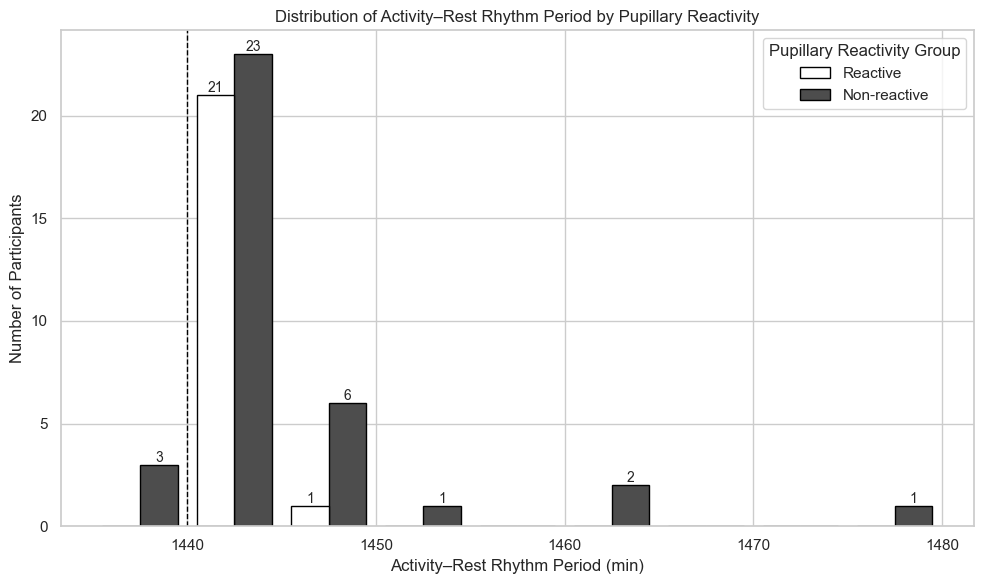


=== Age Comparison ===
Test used: t-test
Statistic = 0.633, p = 0.529

=== Sex Comparison (Chi² Test) ===
Chi² = 1.215, p = 0.270

=== Pupillary Reactivity Distribution ===
Reactive: 22 (37.93%)
Non-reactive: 36 (62.07%)
Chi² = 3.379, p = 0.066

=== VIF Table ===
                        Feature          VIF
                            Sex 3.761000e+01
                            Age 5.837000e+01
                            PLR 8.060000e+00
                Diabetes status 4.660000e+00
                            SRI 9.963000e+01
                  SleepMidpoint 2.184390e+03
                             RA 1.217360e+03
                             IV 8.129000e+01
                            IVm 1.758400e+02
                             IS 1.133500e+02
                            ISm 2.695000e+02
                            M10 1.007600e+02
                           M10o 1.630900e+02
                             L5 1.293400e+02
                            L5o 1.887450e+03
               

In [4]:
def run_pipeline(file_path, output_dir, id_column="Participant",
                 corr_threshold=0.85, vif_threshold=5.0):

    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        return None, None, None

    os.makedirs(output_dir, exist_ok=True)

    # =========================
    # 1) Load data
    # =========================
    dataframe_source = pd.read_csv(file_path)
    if id_column in dataframe_source.columns:
        numeric_cols = dataframe_source.select_dtypes(include=["int64", "float64"]).columns.tolist()
        dataframe_source = dataframe_source[[id_column] + [c for c in numeric_cols if c != id_column]]
    else:
        dataframe_source = dataframe_source.select_dtypes(include=["int64", "float64"])

    # =========================
    # 2) Multicollinearity
    # =========================
    df_num = dataframe_source.drop(columns=[id_column], errors="ignore").copy()

    corr_matrix = df_num.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [col for col in upper.columns if any(upper[col] > corr_threshold)]

    vif_table = pd.DataFrame({
        "Feature": df_num.columns,
        "VIF": [variance_inflation_factor(df_num.values, i) for i in range(df_num.shape[1])]
    })
    to_drop_vif = vif_table.loc[vif_table["VIF"] > vif_threshold, "Feature"].tolist()

    removed_vars = sorted(set(to_drop_corr) & set(to_drop_vif))
    df_clean = dataframe_source.drop(columns=removed_vars, errors="ignore")

    df_clean.to_csv(os.path.join(output_dir, "All_data_cleaned_no_collinearity.csv"), index=False)
    vif_table.to_csv(os.path.join(output_dir, "VIF_table.csv"), index=False)
    pd.DataFrame({"Removed_Variables": removed_vars}).to_csv(
        os.path.join(output_dir, "removed_variables.csv"), index=False
    )

    # =========================
    # 3) Histogram
    # =========================
    if {"PLR", "PeriodActivity"}.issubset(dataframe_source.columns):
        df_plot = dataframe_source.dropna(subset=["PLR", "PeriodActivity"]).copy()
        df_plot["PLR_label"] = df_plot["PLR"].map({1: "Reactive", 0: "Non-reactive"})

        freq_table = df_plot.groupby(["PeriodActivity", "PLR_label"]).size().unstack(fill_value=0)
        print("\n📊 Participants per Period (min) by Pupillary Reactivity:")
        print(freq_table.to_string())

        plt.figure(figsize=(10, 6))
        ax = sns.histplot(
            data=df_plot,
            x="PeriodActivity",
            hue="PLR_label",
            bins=np.arange(1435, 1485, 5),
            multiple="dodge",
            shrink=0.8,
            edgecolor="black"
        )

        for i, container in enumerate(ax.containers):
            for patch in container:
                patch.set_facecolor("#4d4d4d" if i == 0 else "#ffffff")

        for container in ax.containers:
            labels = [f"{int(bar.get_height())}" if bar.get_height() > 0 else "" for bar in container]
            ax.bar_label(container, labels=labels, label_type="edge", fontsize=10)

        plt.axvline(1440, color="black", linestyle="--", linewidth=1)
        plt.xlabel("Activity–Rest Rhythm Period (min)")
        plt.ylabel("Number of Participants")
        plt.title("Distribution of Activity–Rest Rhythm Period by Pupillary Reactivity")

        plt.legend(
            handles=[
                Patch(facecolor="#ffffff", edgecolor="black", label="Reactive"),
                Patch(facecolor="#4d4d4d", edgecolor="black", label="Non-reactive")
            ],
            title="Pupillary Reactivity Group"
        )

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "activity_rest_period_by_reactivity.png"), dpi=600)
        plt.show()

    # =========================
    # 4) Group comparisons
    # =========================
    if {"PLR", "Age", "Sex"}.issubset(dataframe_source.columns):
        age_r = dataframe_source.loc[dataframe_source["PLR"] == 1, "Age"].dropna()
        age_n = dataframe_source.loc[dataframe_source["PLR"] == 0, "Age"].dropna()

        p_shapiro_r = shapiro(age_r).pvalue if len(age_r) >= 3 else np.nan
        p_shapiro_n = shapiro(age_n).pvalue if len(age_n) >= 3 else np.nan
        p_levene = levene(age_r, age_n).pvalue if len(age_r) > 1 and len(age_n) > 1 else np.nan

        if p_shapiro_r > 0.05 and p_shapiro_n > 0.05 and p_levene > 0.05:
            test_name = "t-test"
            stat_age, p_age = ttest_ind(age_r, age_n)
        else:
            test_name = "Mann–Whitney U test"
            stat_age, p_age = mannwhitneyu(age_r, age_n)

        sex_table = pd.crosstab(dataframe_source["PLR"], dataframe_source["Sex"])
        chi2_sex, p_sex, _, _ = chi2_contingency(sex_table)

        count_r = (dataframe_source["PLR"] == 1).sum()
        count_n = (dataframe_source["PLR"] == 0).sum()
        chi2_total, p_total = chisquare([count_r, count_n])

        print("\n=== Age Comparison ===")
        print(f"Test used: {test_name}")
        print(f"Statistic = {stat_age:.3f}, p = {p_age:.3f}")

        print("\n=== Sex Comparison (Chi² Test) ===")
        print(f"Chi² = {chi2_sex:.3f}, p = {p_sex:.3f}")

        print("\n=== Pupillary Reactivity Distribution ===")
        print(f"Reactive: {count_r} ({count_r / len(dataframe_source) * 100:.2f}%)")
        print(f"Non-reactive: {count_n} ({count_n / len(dataframe_source) * 100:.2f}%)")
        print(f"Chi² = {chi2_total:.3f}, p = {p_total:.3f}")

    print("\n=== VIF Table ===")
    print(vif_table.round(2).to_string(index=False))

    print("\n=== Removed Variables ===")
    print("\n".join(f" - {v}" for v in removed_vars) if removed_vars else "No variables removed.")

    return df_clean, removed_vars, vif_table


# =========================
# RUN
# =========================

df_cleaned, removed_vars, vif_results = run_pipeline(TABLE_PATH, DATA_OUTPUT_PATH)

# Pipeline for Clustering and Cluster Characterization – Summary

This pipeline performs clustering using PCA and KMeans, characterizes the clusters,
and generates visualizations and outputs for further analysis.


(58, 25)
['Participant', 'SRI', 'SleepMidpoint', 'RA', 'IV', 'IS', 'M10', 'M10o', 'L5', 'L5o', 'ADAT', 'CoG', 'FSoD', 'kRA', 'kAR', 'LRI', 'M10olight', 'L5olight', 'PeriodActivity', 'QPActivity', 'PeriodLight', 'QPLight', 'PeriodTemperature', 'QPTemperature', 'PLR']
✅ PCA retained 9 components (80.02% explained variance)
k = 2: silhouette = 0.2452
k = 3: silhouette = 0.1316
k = 4: silhouette = 0.1426
k = 5: silhouette = 0.1490
k = 6: silhouette = 0.1446
k = 7: silhouette = 0.1370
k = 8: silhouette = 0.1439
k = 9: silhouette = 0.1308
k = 10: silhouette = 0.1592
📌 Best k = 2


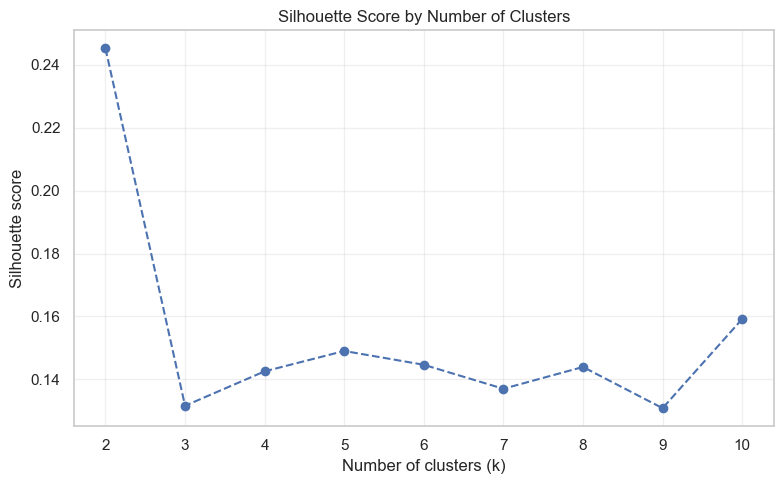

📸 PCA cluster plot saved to: ./data_output/pca_cluster_plot.png


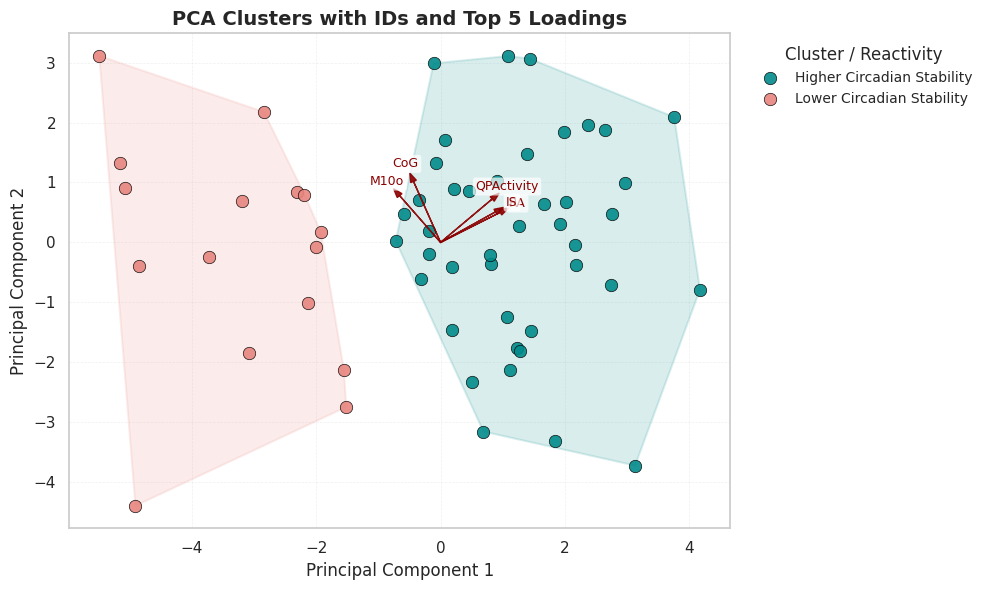


🔍 Top 5 PCA loading vectors:
              PC1    PC2
QPActivity  0.314  0.274
RA          0.364  0.191
M10o       -0.252  0.299
CoG        -0.165  0.385
IS          0.338  0.195

📋 PCA loadings (PC1 and PC2):
                     PC1    PC2
SRI                0.174  0.256
SleepMidpoint     -0.159  0.269
RA                 0.364  0.191
IV                -0.094 -0.168
IS                 0.338  0.195
M10                0.128  0.348
M10o              -0.252  0.299
L5                -0.307  0.059
L5o               -0.219  0.299
ADAT              -0.144  0.172
CoG               -0.165  0.385
FSoD              -0.202 -0.135
kRA               -0.019 -0.055
kAR                0.055 -0.299
LRI                0.303  0.040
M10olight         -0.227  0.166
L5olight          -0.192  0.131
PeriodActivity    -0.181 -0.005
QPActivity         0.314  0.274
PeriodLight        0.103  0.179
QPLight            0.153 -0.023
PeriodTemperature -0.052 -0.058
QPTemperature      0.165 -0.101

📊 Number of particip

In [5]:
# =============================================================================
# DATA LOADING
# =============================================================================
def load_dataset(file_path, selected_vars, id_col="Participant"):
    df = pd.read_csv(file_path)

    cols = selected_vars.copy()
    if id_col in df.columns:
        cols = [id_col] + cols

    if "PLR" in df.columns and "PLR" not in cols:
        cols.append("PLR")

    df = df[cols].copy()

    for col in selected_vars:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


# =============================================================================
# PCA + KMEANS
# =============================================================================
def run_pca_kmeans(df, features, id_col="Participant", var_threshold=0.80, max_clusters=10, random_state=42):
    df_model = df[[id_col] + features].copy() if id_col in df.columns else df[features].copy()
    ids = df_model[id_col].copy() if id_col in df_model.columns else None
    X = df_model[features].copy()

    # Standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca_full = PCA(n_components=min(len(features), X.shape[1]))
    X_pca_full = pca_full.fit_transform(X_scaled)

    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = np.searchsorted(cumvar, var_threshold) + 1
    X_pca = X_pca_full[:, :n_components]

    print(f"✅ PCA retained {n_components} components ({cumvar[n_components - 1]:.2%} explained variance)")

    # Silhouette for k selection
    k_values = list(range(2, max_clusters + 1))
    silhouette_scores = []

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = km.fit_predict(X_pca)
        score = silhouette_score(X_pca, labels)
        silhouette_scores.append(score)
        print(f"k = {k}: silhouette = {score:.4f}")

    best_k = k_values[np.argmax(silhouette_scores)]
    print(f"📌 Best k = {best_k}")

    # Final KMeans
    kmeans = KMeans(n_clusters=best_k, random_state=random_state, n_init=20)
    cluster_labels = kmeans.fit_predict(X_pca)

    # Output dataframe
    df_clusters = X.copy()
    if ids is not None:
        df_clusters[id_col] = ids.values

    df_clusters["PCA1"] = X_pca_full[:, 0]
    df_clusters["PCA2"] = X_pca_full[:, 1]
    df_clusters["Cluster"] = cluster_labels

    # Cluster naming based on PCA1
    mean_pca1 = df_clusters.groupby("Cluster")["PCA1"].mean()
    higher_cluster = mean_pca1.idxmax()
    lower_cluster = mean_pca1.idxmin()

    cluster_name_map = {
        higher_cluster: "Higher Circadian Stability",
        lower_cluster: "Lower Circadian Stability"
    }

    df_clusters["Cluster_name"] = df_clusters["Cluster"].map(cluster_name_map)

    # Loadings
    loadings = pd.DataFrame(
        pca_full.components_[:2].T,
        index=features,
        columns=["PC1", "PC2"]
    )
    loadings["abs_sum"] = loadings["PC1"].abs() + loadings["PC2"].abs()

    return {
        "df_clusters": df_clusters,
        "pca": pca_full,
        "kmeans": kmeans,
        "best_k": best_k,
        "n_components": n_components,
        "cumvar": cumvar,
        "silhouette_scores": silhouette_scores,
        "k_values": k_values,
        "loadings": loadings,
        "cluster_name_map": cluster_name_map
    }


# =============================================================================
# PLOTS
# =============================================================================
def plot_silhouette_curve(k_values, silhouette_scores):
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, silhouette_scores, marker="o", linestyle="--")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.title("Silhouette Score by Number of Clusters")
    plt.xticks(k_values)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_pca_biplot(df_clusters, loadings, output_path=None, top_n=5):
    mpl.rcParams.update({
        "font.size": 10,
        "font.family": "DejaVu Sans",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "legend.fontsize": 10
    })

    top_vars = loadings.sort_values("abs_sum", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Convex hulls
    for cluster_name in df_clusters["Cluster_name"].dropna().unique():
        subset = df_clusters[df_clusters["Cluster_name"] == cluster_name]
        color = CLUSTER_COLORS[cluster_name]

        if len(subset) >= 3:
            points = subset[["PCA1", "PCA2"]].values
            hull = ConvexHull(points)
            hull_points = points[hull.vertices]
            ax.fill(
                hull_points[:, 0], hull_points[:, 1],
                color=color, alpha=0.15, edgecolor=color, linewidth=1.5
            )

    # Scatter points
    has_plr = "PLR" in df_clusters.columns

    if has_plr:
        legend_map = {
            ("Higher Circadian Stability", 1): "HCS – Reactive",
            ("Higher Circadian Stability", 0): "HCS – Non-reactive",
            ("Lower Circadian Stability", 1): "LCS – Reactive",
            ("Lower Circadian Stability", 0): "LCS – Non-reactive"
        }

        for cluster_name in df_clusters["Cluster_name"].dropna().unique():
            for plr_value in sorted(df_clusters["PLR"].dropna().unique()):
                subset = df_clusters[
                    (df_clusters["Cluster_name"] == cluster_name) &
                    (df_clusters["PLR"] == plr_value)
                ]

                if subset.empty:
                    continue

                ax.scatter(
                    subset["PCA1"], subset["PCA2"],
                    c=CLUSTER_COLORS[cluster_name],
                    marker=GROUP_MARKERS.get(plr_value, "o"),
                    edgecolor="black",
                    linewidths=0.5,
                    alpha=0.9,
                    s=80,
                    label=legend_map.get((cluster_name, plr_value), f"{cluster_name} – PLR {plr_value}")
                )

                if PARTICIPANT_COLUMN_HEADER in subset.columns:
                    for _, row in subset.iterrows():
                        x, y = row["PCA1"], row["PCA2"]
                        dx, dy = 0.12, 0.12
                        ax.plot([x, x + dx], [y, y + dy], color=CLUSTER_COLORS[cluster_name], linewidth=0.5, alpha=0.5)
                        ax.text(x + dx + 0.02, y + dy, str(row[PARTICIPANT_COLUMN_HEADER]), fontsize=7, color=CLUSTER_COLORS[cluster_name])
    else:
        for cluster_name in df_clusters["Cluster_name"].dropna().unique():
            subset = df_clusters[df_clusters["Cluster_name"] == cluster_name]
            ax.scatter(
                subset["PCA1"], subset["PCA2"],
                c=CLUSTER_COLORS[cluster_name],
                edgecolor="black",
                linewidths=0.5,
                alpha=0.9,
                s=80,
                label=cluster_name
            )

    # Loadings
    for var, row in top_vars.iterrows():
        pc1, pc2 = row["PC1"], row["PC2"]
        ax.arrow(0, 0, pc1 * 3, pc2 * 3, color="#8B0000", alpha=0.9,
                 head_width=0.1, length_includes_head=True)
        ax.text(
            pc1 * 3.4, pc2 * 3.4, var,
            fontsize=9, color="#8B0000", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
        )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(f"PCA Clusters with IDs and Top {top_n} Loadings")
    ax.legend(title="Cluster / Reactivity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=600, bbox_inches="tight")
        print(f"📸 PCA cluster plot saved to: {output_path}")

    plt.show()

    print(f"\n🔍 Top {top_n} PCA loading vectors:")
    print(top_vars[["PC1", "PC2"]].round(3))


# =============================================================================
# SAVE MERGED OUTPUT
# =============================================================================
def save_clustered_dataset(original_file_path, df_clusters, output_path, id_col="Participant"):
    df_original = pd.read_csv(original_file_path)

    cols_to_merge = [id_col, "Cluster", "Cluster_name"]
    df_merge = df_clusters[cols_to_merge].copy()

    df_final = df_original.merge(df_merge, on=id_col, how="left")
    df_final.to_csv(output_path, index=False)
    print(f"✅ Updated dataset with cluster labels saved to: {output_path}")


# =============================================================================
# EXECUTION
# =============================================================================
df_full = load_dataset(TABLE_PATH, CLUSTERING_COLUMN_HEADER_LIST, id_col=PARTICIPANT_COLUMN_HEADER)
print(df_full.shape)
print(df_full.columns.tolist())

results = run_pca_kmeans(
    df=df_full,
    features=CLUSTERING_COLUMN_HEADER_LIST,
    id_col=PARTICIPANT_COLUMN_HEADER,
    var_threshold=0.80,
    max_clusters=10,
    random_state=42
)

dataframe_cluster = results["df_clusters"]

plot_silhouette_curve(results["k_values"], results["silhouette_scores"])

plot_pca_biplot(
    df_clusters=dataframe_cluster,
    loadings=results["loadings"],
    output_path=os.path.join(DATA_OUTPUT_PATH, "pca_cluster_plot.png"),
    top_n=5
)

print("\n📋 PCA loadings (PC1 and PC2):")
print(results["loadings"][["PC1", "PC2"]].round(3))

print("\n📊 Number of participants per cluster:")
print(dataframe_cluster["Cluster_name"].value_counts())

save_clustered_dataset(
    original_file_path=TABLE_PATH,
    df_clusters=dataframe_cluster,
    output_path=os.path.join(DATA_OUTPUT_PATH, "All_data_cleaned_with_clusters.csv"),
    id_col=PARTICIPANT_COLUMN_HEADER
)


# SHAP Analysis Pipeline – Summary

This pipeline performs SHAP-based model explainability using Random Forest and visualizes the results.



✅ SHAP analysis using 28 features: ['SRI', 'SleepMidpoint', 'RA', 'IV', 'IS', 'M10', 'M10o', 'L5', 'L5o', 'ADAT', 'CoG', 'FSoD', 'kRA', 'kAR', 'LRI', 'M10olight', 'L5olight', 'PeriodActivity', 'QPActivity', 'PeriodLight', 'QPLight', 'PeriodTemperature', 'QPTemperature', 'Sex', 'Age', 'PLR', 'Diabetes status', 'Light Perception']

📊 Metrics (Stratified K-Fold):


Accuracy                0.966
Precision               0.955
Recall (Sensitivity)    1.000
F1 Score                0.977
Specificity             0.875
AUC                     0.997
dtype: float64

<Figure size 700x600 with 0 Axes>

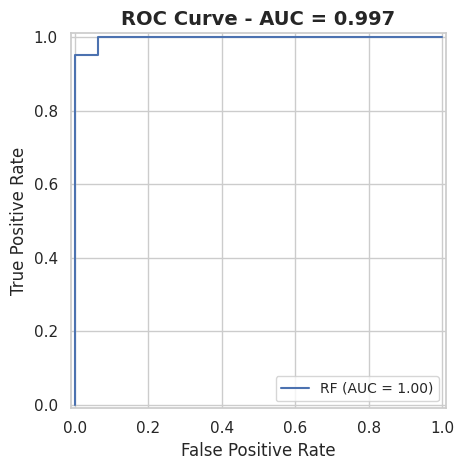

<Figure size 640x480 with 0 Axes>

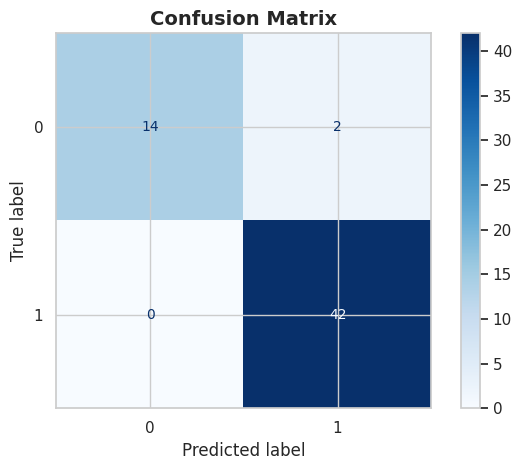

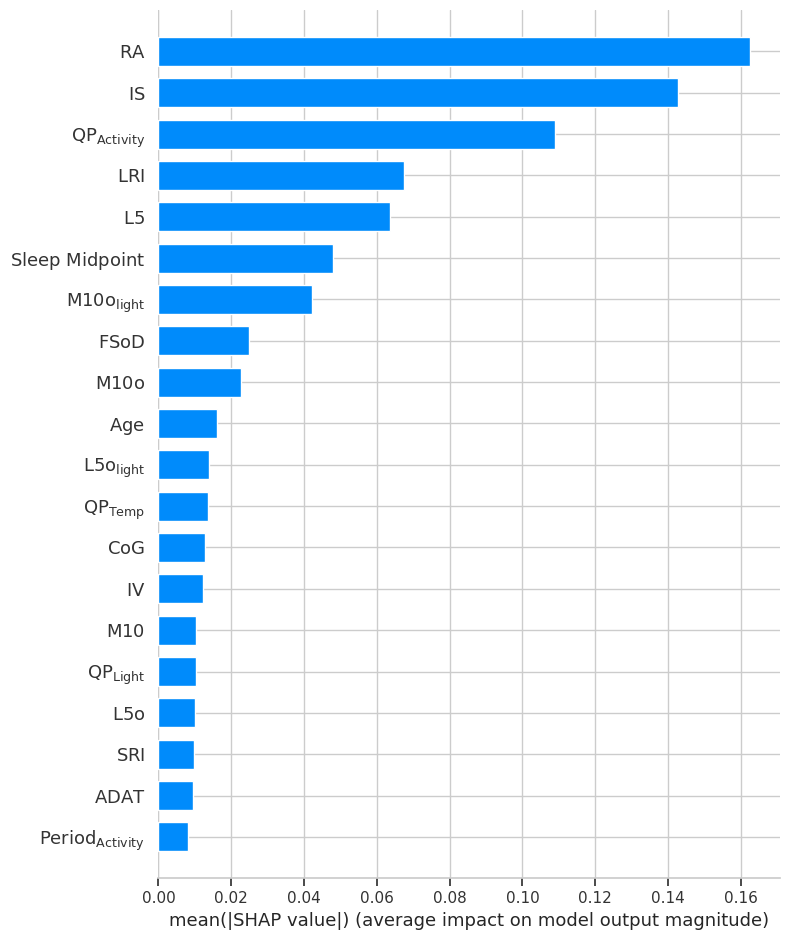

<Figure size 640x480 with 0 Axes>

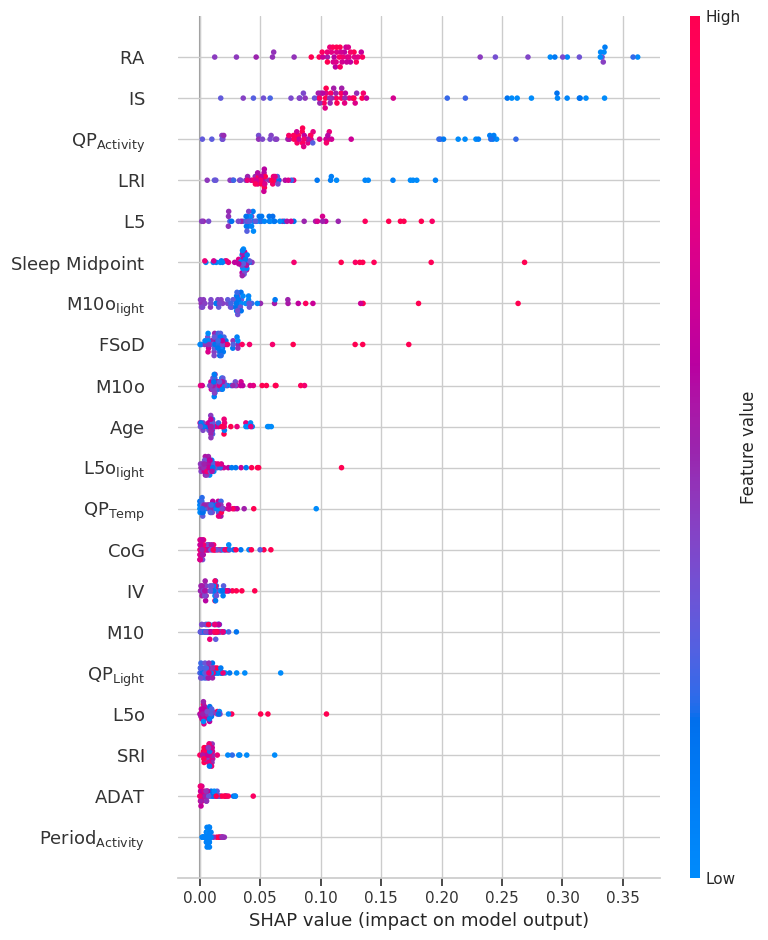

<Figure size 640x480 with 0 Axes>


📈 SHAP Mean Absolute Importance (Top 10 features):


,Feature,Mean_Abs_SHAP
2,RA,0.163
4,IS,0.143
18,QPActivity,0.109
14,LRI,0.067
7,L5,0.064
1,SleepMidpoint,0.048
15,M10olight,0.042
11,FSoD,0.025
6,M10o,0.023
24,Age,0.016


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

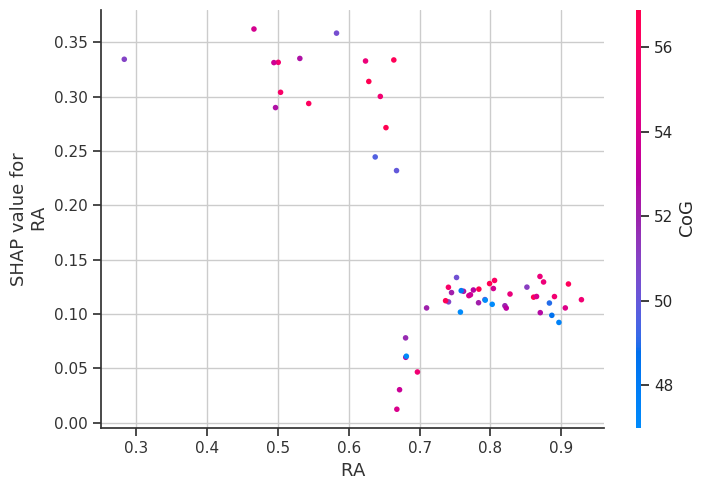

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

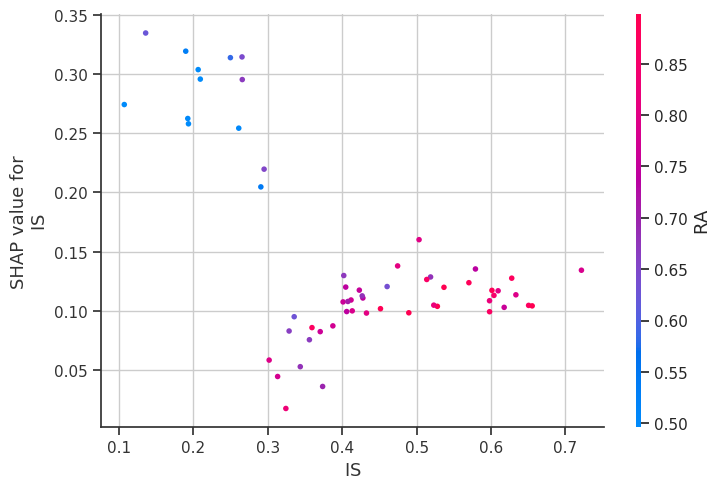

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

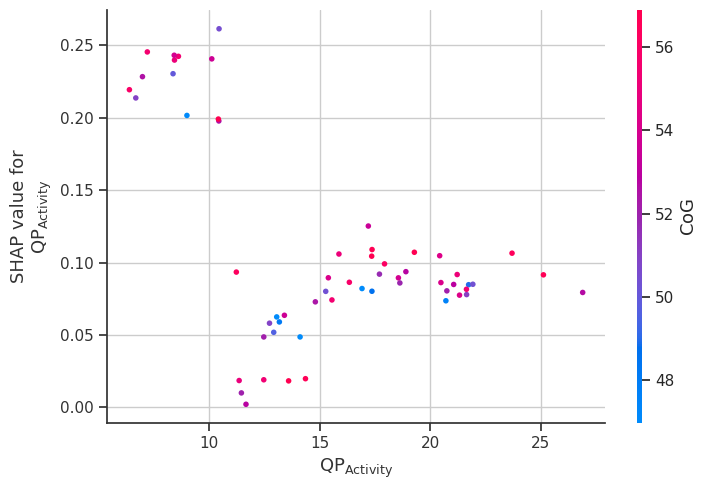

<Figure size 640x480 with 0 Axes>

In [6]:
def shap_analysis(df_clusters, DATA_OUTPUT_PATH="shap", PARTICIPANT_COLUMN_HEADER='Participant', CLUSTER_COLUMN_HEADER='Cluster'):
    os.makedirs(DATA_OUTPUT_PATH, exist_ok=True)
    y = df_clusters[CLUSTER_COLUMN_HEADER]

   
    X = df_clusters[SHAP_COLUMN_HEADER_LIST].copy()
    X = X.select_dtypes(include=[np.number])
    if X.empty:
        raise ValueError("❌ No valid numerical features for SHAP analysis.")

    print(f"✅ SHAP analysis using {len(X.columns)} features: {list(X.columns)}")

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    rf_model = RandomForestClassifier(random_state=42)

    y_pred = cross_val_predict(rf_model, X, y, cv=cv)
    y_proba = cross_val_predict(rf_model, X, y, cv=cv, method="predict_proba")[:, 1]

    cm = confusion_matrix(y, y_pred)
    metrics = {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall (Sensitivity)': recall_score(y, y_pred, zero_division=0),
        'F1 Score': f1_score(y, y_pred, zero_division=0)
    }
    if cm.shape == (2, 2):
        TN, FP = cm[0, 0], cm[0, 1]
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        metrics['Specificity'] = specificity

    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    metrics['AUC'] = roc_auc

    pd.Series(metrics).to_csv(f"{DATA_OUTPUT_PATH}/classification_metrics.csv")

    print("\n📊 Metrics (Stratified K-Fold):")
    display(pd.Series(metrics).round(3))  

    plt.figure(figsize=(7, 6))
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='RF').plot()
    plt.title(f"ROC Curve - AUC = {roc_auc:.3f}")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{DATA_OUTPUT_PATH}/roc_curve_rf.png", bbox_inches='tight')

    rf = RandomForestClassifier(random_state=42)
    rf.fit(X, y)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{DATA_OUTPUT_PATH}/confusion_matrix_rf.png", bbox_inches='tight')

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X)
    shap_vals = (
        np.abs(shap_values[0]) + np.abs(shap_values[1])
        if isinstance(shap_values, list)
        else np.abs(shap_values).sum(axis=2)
    )

    # 🎯 Map LaTeX labels
    feature_names_latex = [COLUMN_HEADER_STYLIZED.get(col, col) for col in X.columns]

    # 📊 SHAP Summary Plots
    shap.summary_plot(shap_vals, X, plot_type="bar", feature_names=feature_names_latex, show=True)
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{DATA_OUTPUT_PATH}/shap_summary_bar.png", bbox_inches='tight')

    shap.summary_plot(shap_vals, X, feature_names=feature_names_latex, show=True)
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{DATA_OUTPUT_PATH}/shap_summary_beeswarm.png", bbox_inches='tight')

    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    shap_df = pd.DataFrame({
        'Feature': X.columns,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values(by='Mean_Abs_SHAP', ascending=False)
    shap_df.to_csv(f"{DATA_OUTPUT_PATH}/shap_importance.csv", index=False)

    print("\n📈 SHAP Mean Absolute Importance (Top 10 features):")
    display(shap_df.head(10).round(3))  

    # 🎯 Dependence plots (Top 3)
    top3 = shap_df['Feature'].head(3).tolist()
    for feature in top3:
        plt.figure()
        idx = list(X.columns).index(feature)
        shap.dependence_plot(
            ind=idx,
            shap_values=shap_vals,
            features=X,
            feature_names=feature_names_latex,
            show=False
        )
        plt.tight_layout()
        plt.show()
        plt.savefig(f"{DATA_OUTPUT_PATH}/dependence_{feature}.png", bbox_inches='tight')

    return shap_df, shap_vals, X, metrics, cm

dataframe_clusters = pd.read_csv(DATA_OUTPUT_PATH + "All_data_cleaned_with_clusters.csv")

shap_df, shap_vals, X, metrics, cm = shap_analysis(
    df_clusters=dataframe_clusters, # Changed df_clusters to df_with_clusters
    DATA_OUTPUT_PATH = DATA_OUTPUT_PATH + "shap_results",
    CLUSTER_COLUMN_HEADER="Cluster"
)

✅ df_clusters loaded:
(58, 45)
['Participant', 'Sex', 'Age', 'PLR', 'Diabetes status', 'SRI', 'SleepMidpoint', 'RA', 'IV', 'IVm', 'IS', 'ISm', 'M10', 'M10o', 'L5', 'L5o', 'ADAT', 'CoG', 'Cog_timeashours', 'AUC', 'FSoD', 'kRA', 'kAR', 'LRI', 'M10olight', 'L5olight', 'PeriodActivity', 'QPActivity', 'PeriodLight', 'QPLight', 'PeriodTemperature', 'QPTemperature', 'SB_period_EXT TEMPERATURE (min)', 'SB_var_EXT TEMPERATURE (%)', 'SB_period_AMB LIGHT (min)', 'SB_var_AMB LIGHT (%)', 'SB_period_RED LIGHT (min)', 'SB_var_RED LIGHT (%)', 'SB_period_BLUE LIGHT (min)', 'SB_var_BLUE LIGHT (%)', 'SB_period_IR LIGHT (min)', 'SB_var_IR LIGHT (%)', 'Light Perception', 'Cluster', 'Cluster_name']
✅ SHAP analysis using 28 features and 58 participants.
Features used: ['SRI', 'SleepMidpoint', 'RA', 'IV', 'IS', 'M10', 'M10o', 'L5', 'L5o', 'ADAT', 'CoG', 'FSoD', 'kRA', 'kAR', 'LRI', 'M10olight', 'L5olight', 'PeriodActivity', 'QPActivity', 'PeriodLight', 'QPLight', 'PeriodTemperature', 'QPTemperature', 'Sex', '

,Metric,Value
0,Accuracy,0.966
1,Precision,0.955
2,Recall (Sensitivity),1.000
3,F1 Score,0.977
4,Specificity,0.875
5,AUC,0.990


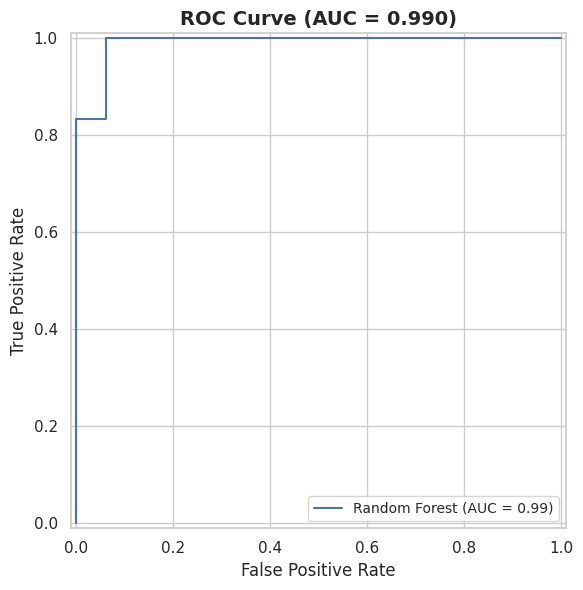

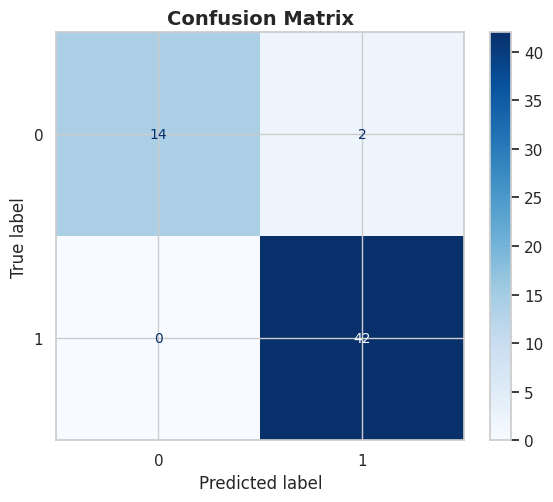


📌 Permutation importance (top 10):


,Feature,Permutation_Mean,Permutation_SD
2,RA,0.011,0.008
0,SRI,0.000,0.000
15,M10olight,0.000,0.000
26,Diabetes status,0.000,0.000
25,PLR,0.000,0.000
24,Age,0.000,0.000
23,Sex,0.000,0.000
22,QPTemperature,0.000,0.000
21,PeriodTemperature,0.000,0.000
20,QPLight,0.000,0.000


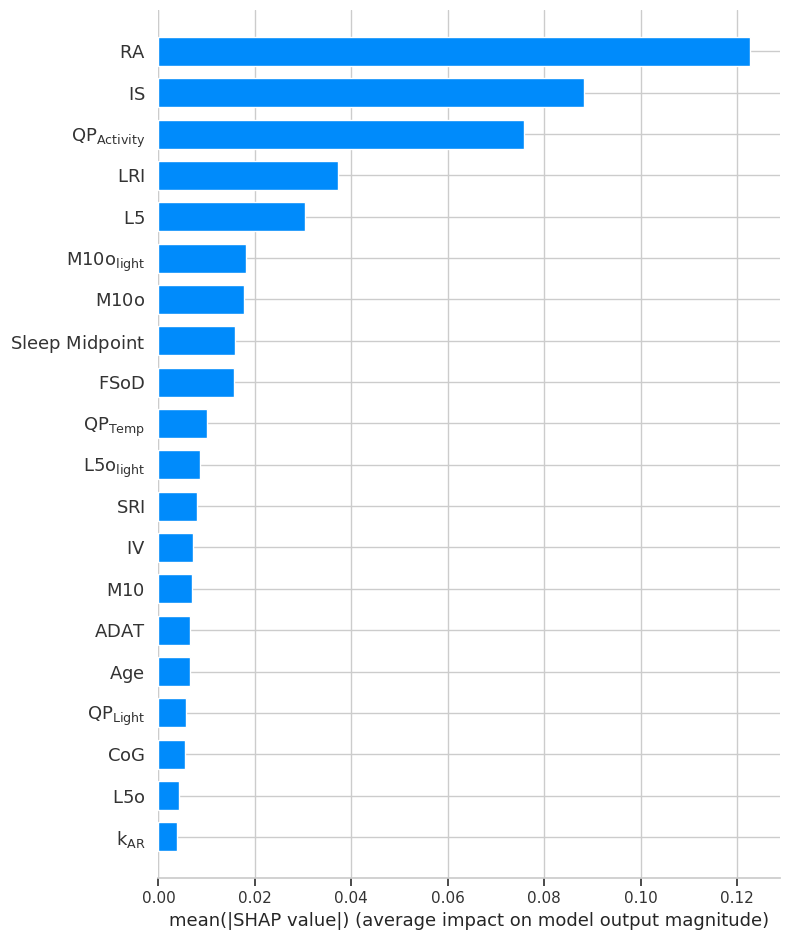

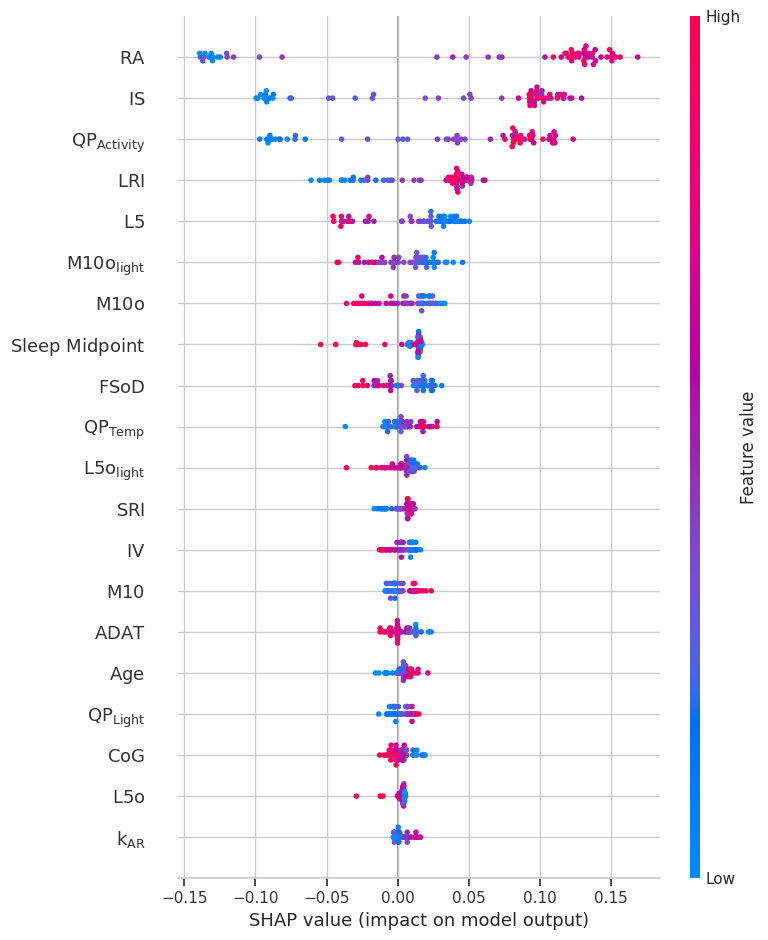


📈 SHAP mean absolute importance (top 10):


,Feature,Feature_label,Mean_Abs_SHAP
2,RA,$\mathrm{RA}$,0.123
4,IS,$\mathrm{IS}$,0.088
18,QPActivity,$\mathrm{QP}_{\mathrm{Activity}}$,0.076
14,LRI,$\mathrm{LRI}$,0.037
7,L5,$\mathrm{L5}$,0.030
15,M10olight,$\mathrm{M10o}_{\mathrm{light}}$,0.018
6,M10o,$\mathrm{M10o}$,0.018
1,SleepMidpoint,$\mathrm{Sleep\ Midpoint}$,0.016
11,FSoD,$\mathrm{FSoD}$,0.016
22,QPTemperature,$\mathrm{QP}_{\mathrm{Temp}}$,0.010



📎 Combined SHAP + permutation importance (top 10):


,Feature,Feature_label,Mean_Abs_SHAP,Permutation_Mean,Permutation_SD
0,RA,$\mathrm{RA}$,0.123,0.011,0.008
1,IS,$\mathrm{IS}$,0.088,0.000,0.000
2,QPActivity,$\mathrm{QP}_{\mathrm{Activity}}$,0.076,0.000,0.000
3,LRI,$\mathrm{LRI}$,0.037,0.000,0.000
4,L5,$\mathrm{L5}$,0.030,0.000,0.000
5,M10olight,$\mathrm{M10o}_{\mathrm{light}}$,0.018,0.000,0.000
6,M10o,$\mathrm{M10o}$,0.018,0.000,0.000
7,SleepMidpoint,$\mathrm{Sleep\ Midpoint}$,0.016,0.000,0.000
8,FSoD,$\mathrm{FSoD}$,0.016,0.000,0.000
9,QPTemperature,$\mathrm{QP}_{\mathrm{Temp}}$,0.010,0.000,0.000


<Figure size 640x480 with 0 Axes>

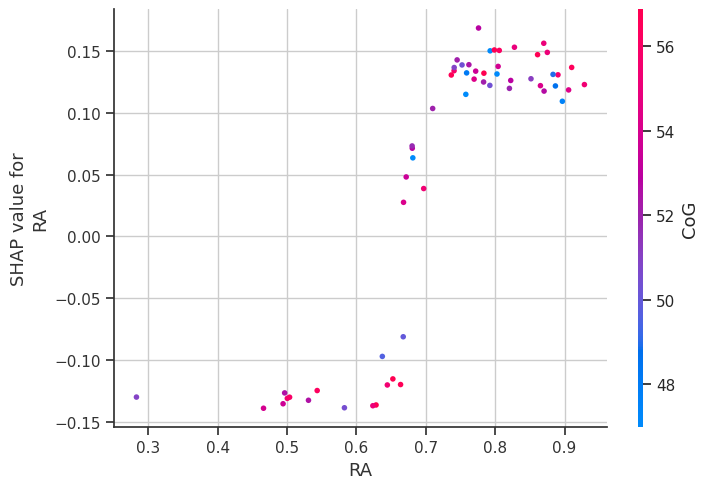

<Figure size 640x480 with 0 Axes>

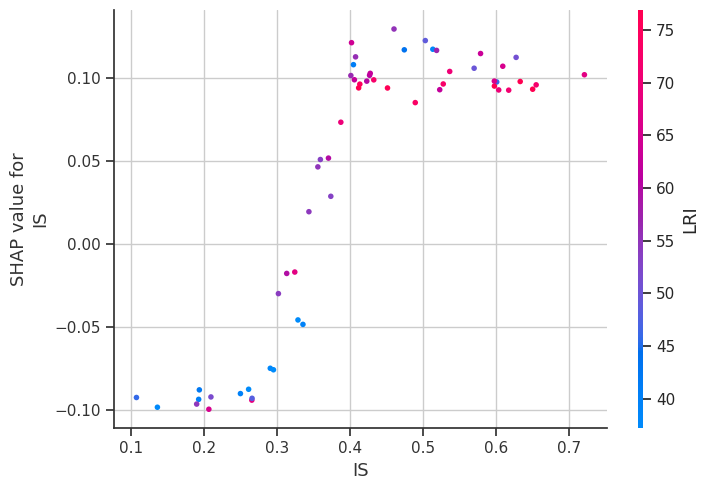

<Figure size 640x480 with 0 Axes>

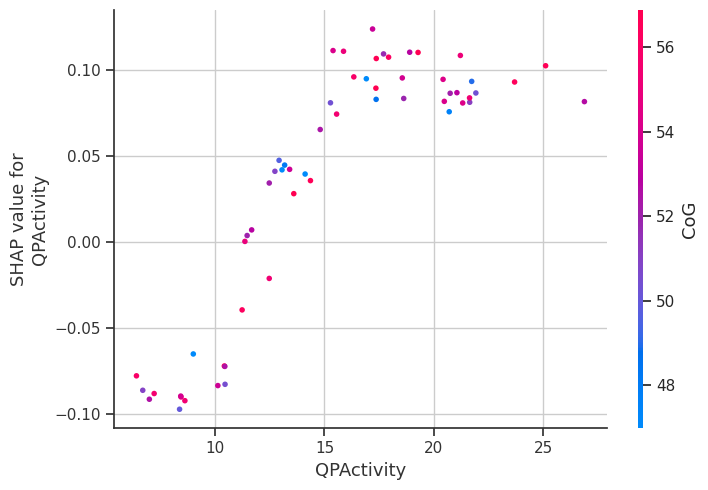


Top 10 SHAP features:


,Feature,Feature_label,Mean_Abs_SHAP
2,RA,$\mathrm{RA}$,0.123
4,IS,$\mathrm{IS}$,0.088
18,QPActivity,$\mathrm{QP}_{\mathrm{Activity}}$,0.076
14,LRI,$\mathrm{LRI}$,0.037
7,L5,$\mathrm{L5}$,0.030
15,M10olight,$\mathrm{M10o}_{\mathrm{light}}$,0.018
6,M10o,$\mathrm{M10o}$,0.018
1,SleepMidpoint,$\mathrm{Sleep\ Midpoint}$,0.016
11,FSoD,$\mathrm{FSoD}$,0.016
22,QPTemperature,$\mathrm{QP}_{\mathrm{Temp}}$,0.010



Top 10 permutation importance features:


,Feature,Permutation_Mean,Permutation_SD
2,RA,0.011,0.008
0,SRI,0.000,0.000
15,M10olight,0.000,0.000
26,Diabetes status,0.000,0.000
25,PLR,0.000,0.000
24,Age,0.000,0.000
23,Sex,0.000,0.000
22,QPTemperature,0.000,0.000
21,PeriodTemperature,0.000,0.000
20,QPLight,0.000,0.000



Classification metrics:


,Metric,Value
0,Accuracy,0.966
1,Precision,0.955
2,Recall (Sensitivity),1.000
3,F1 Score,0.977
4,Specificity,0.875
5,AUC,0.990


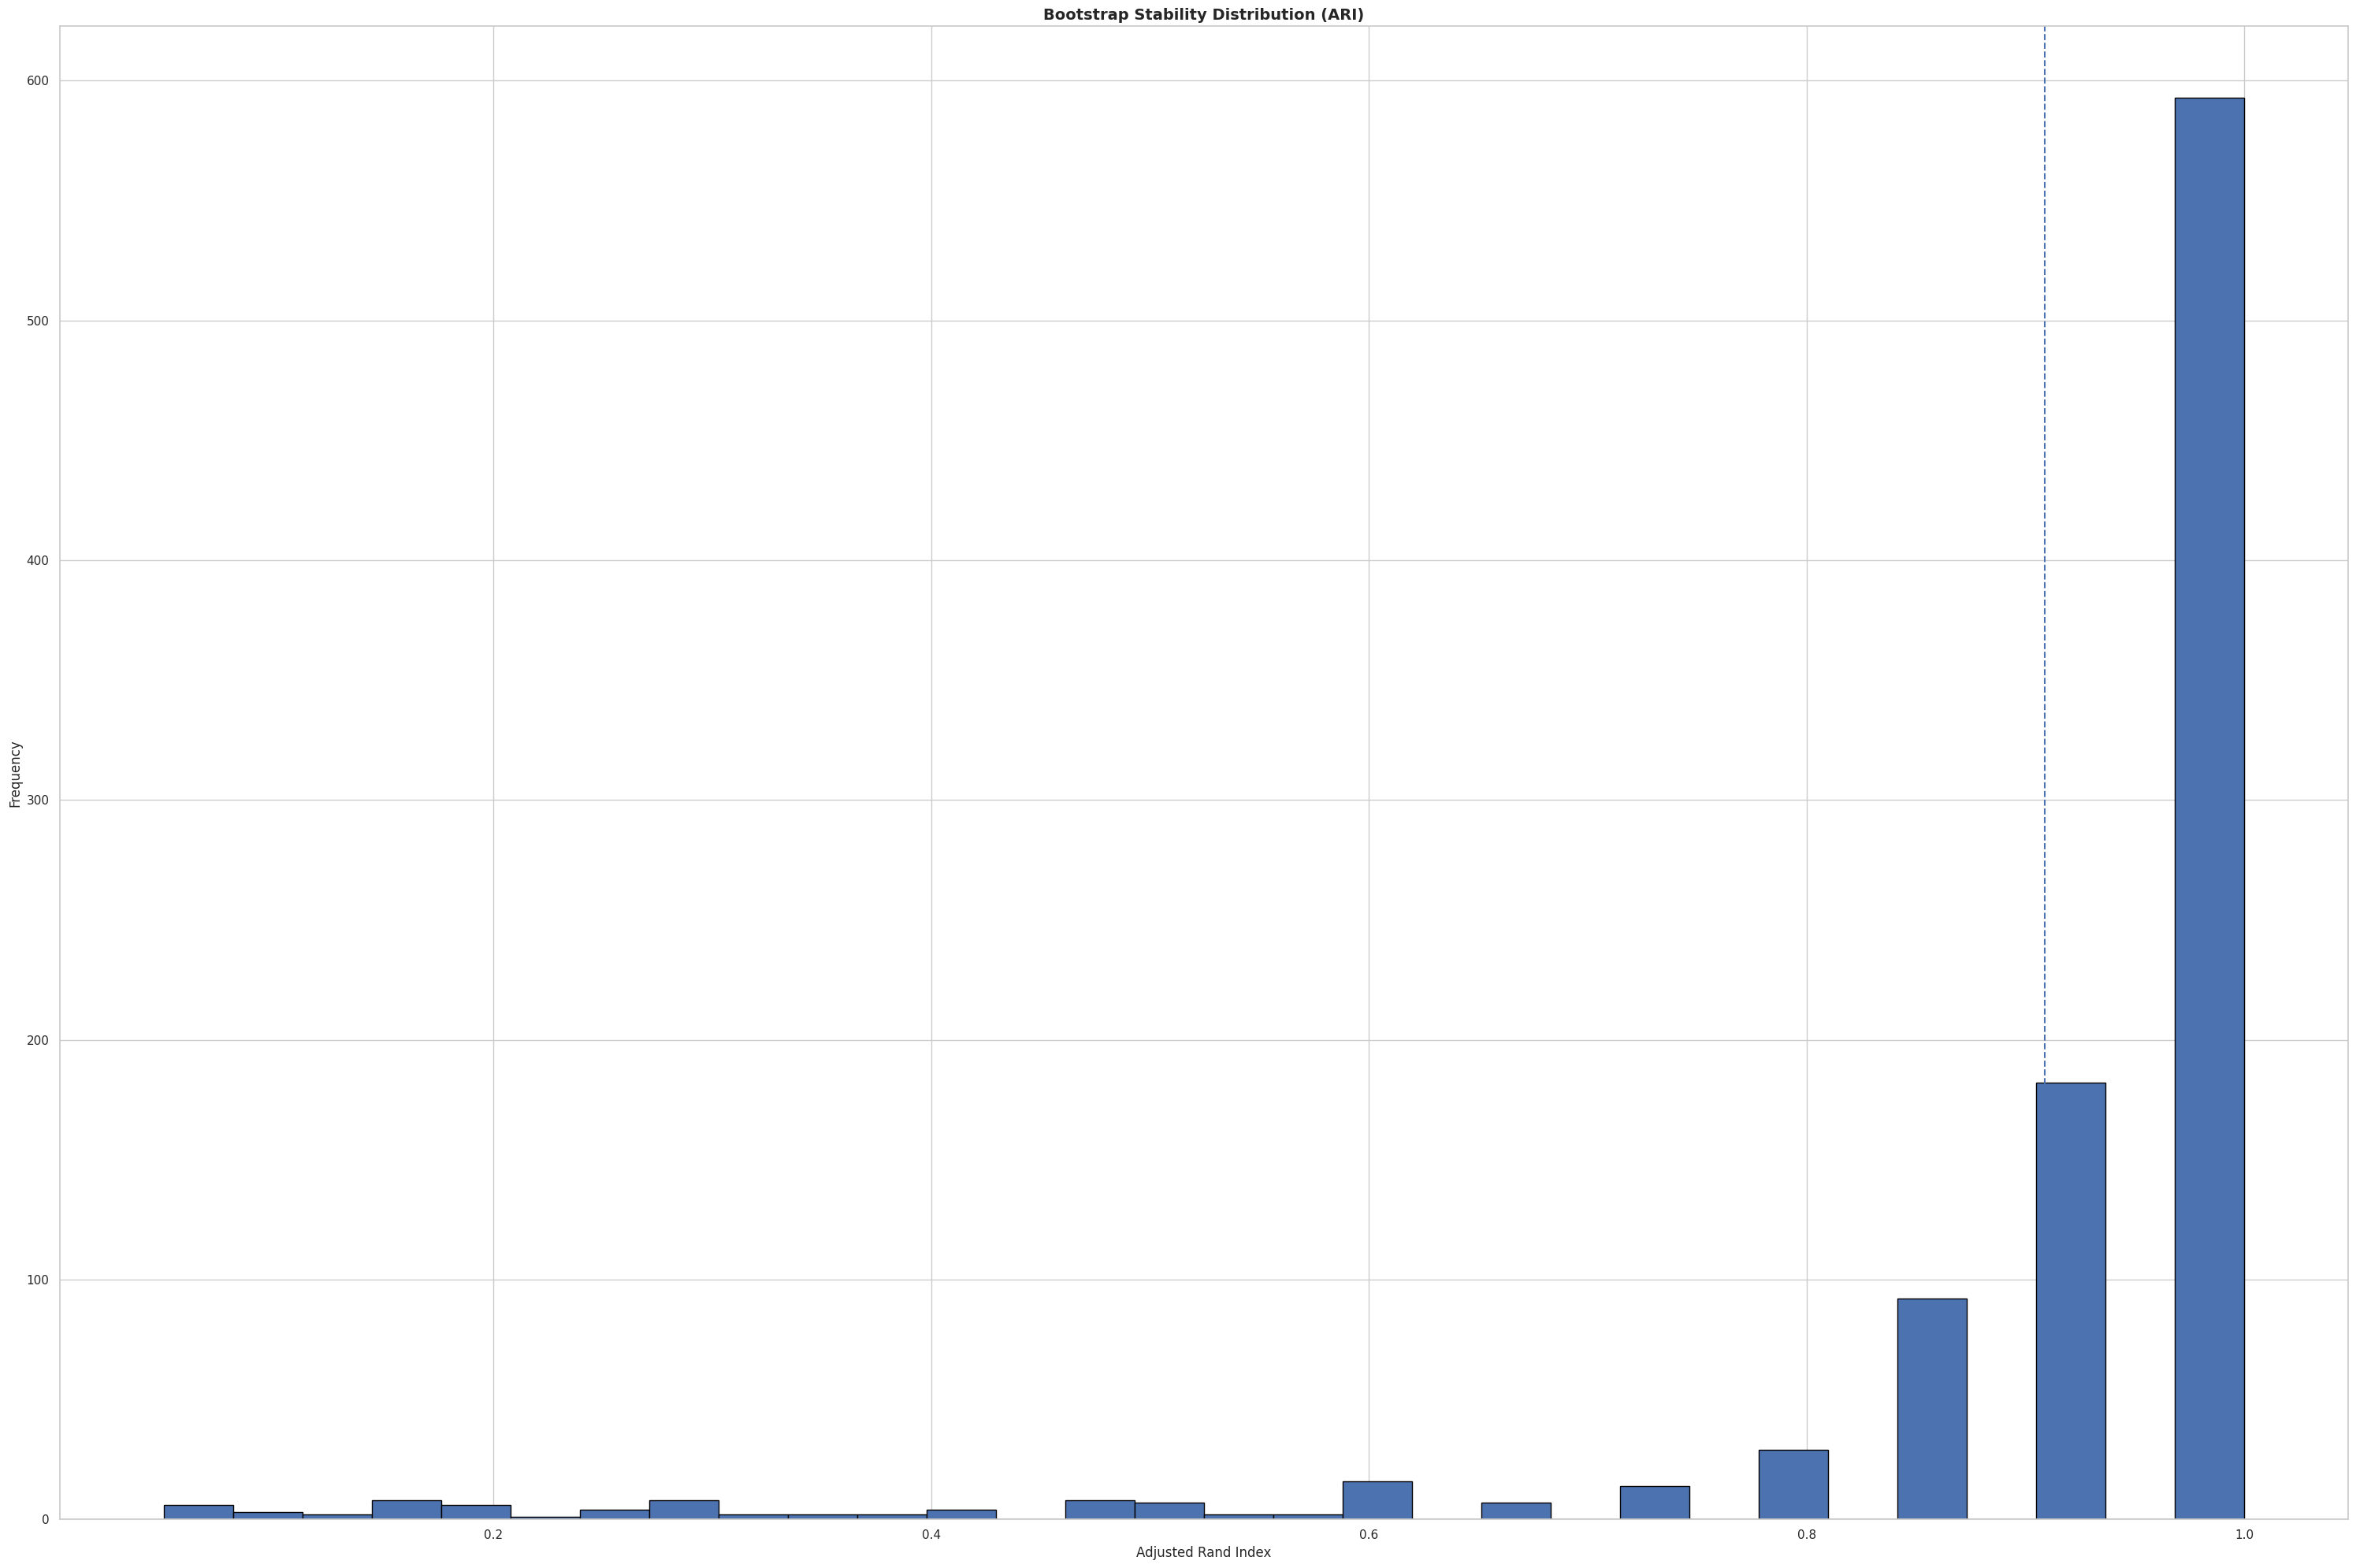

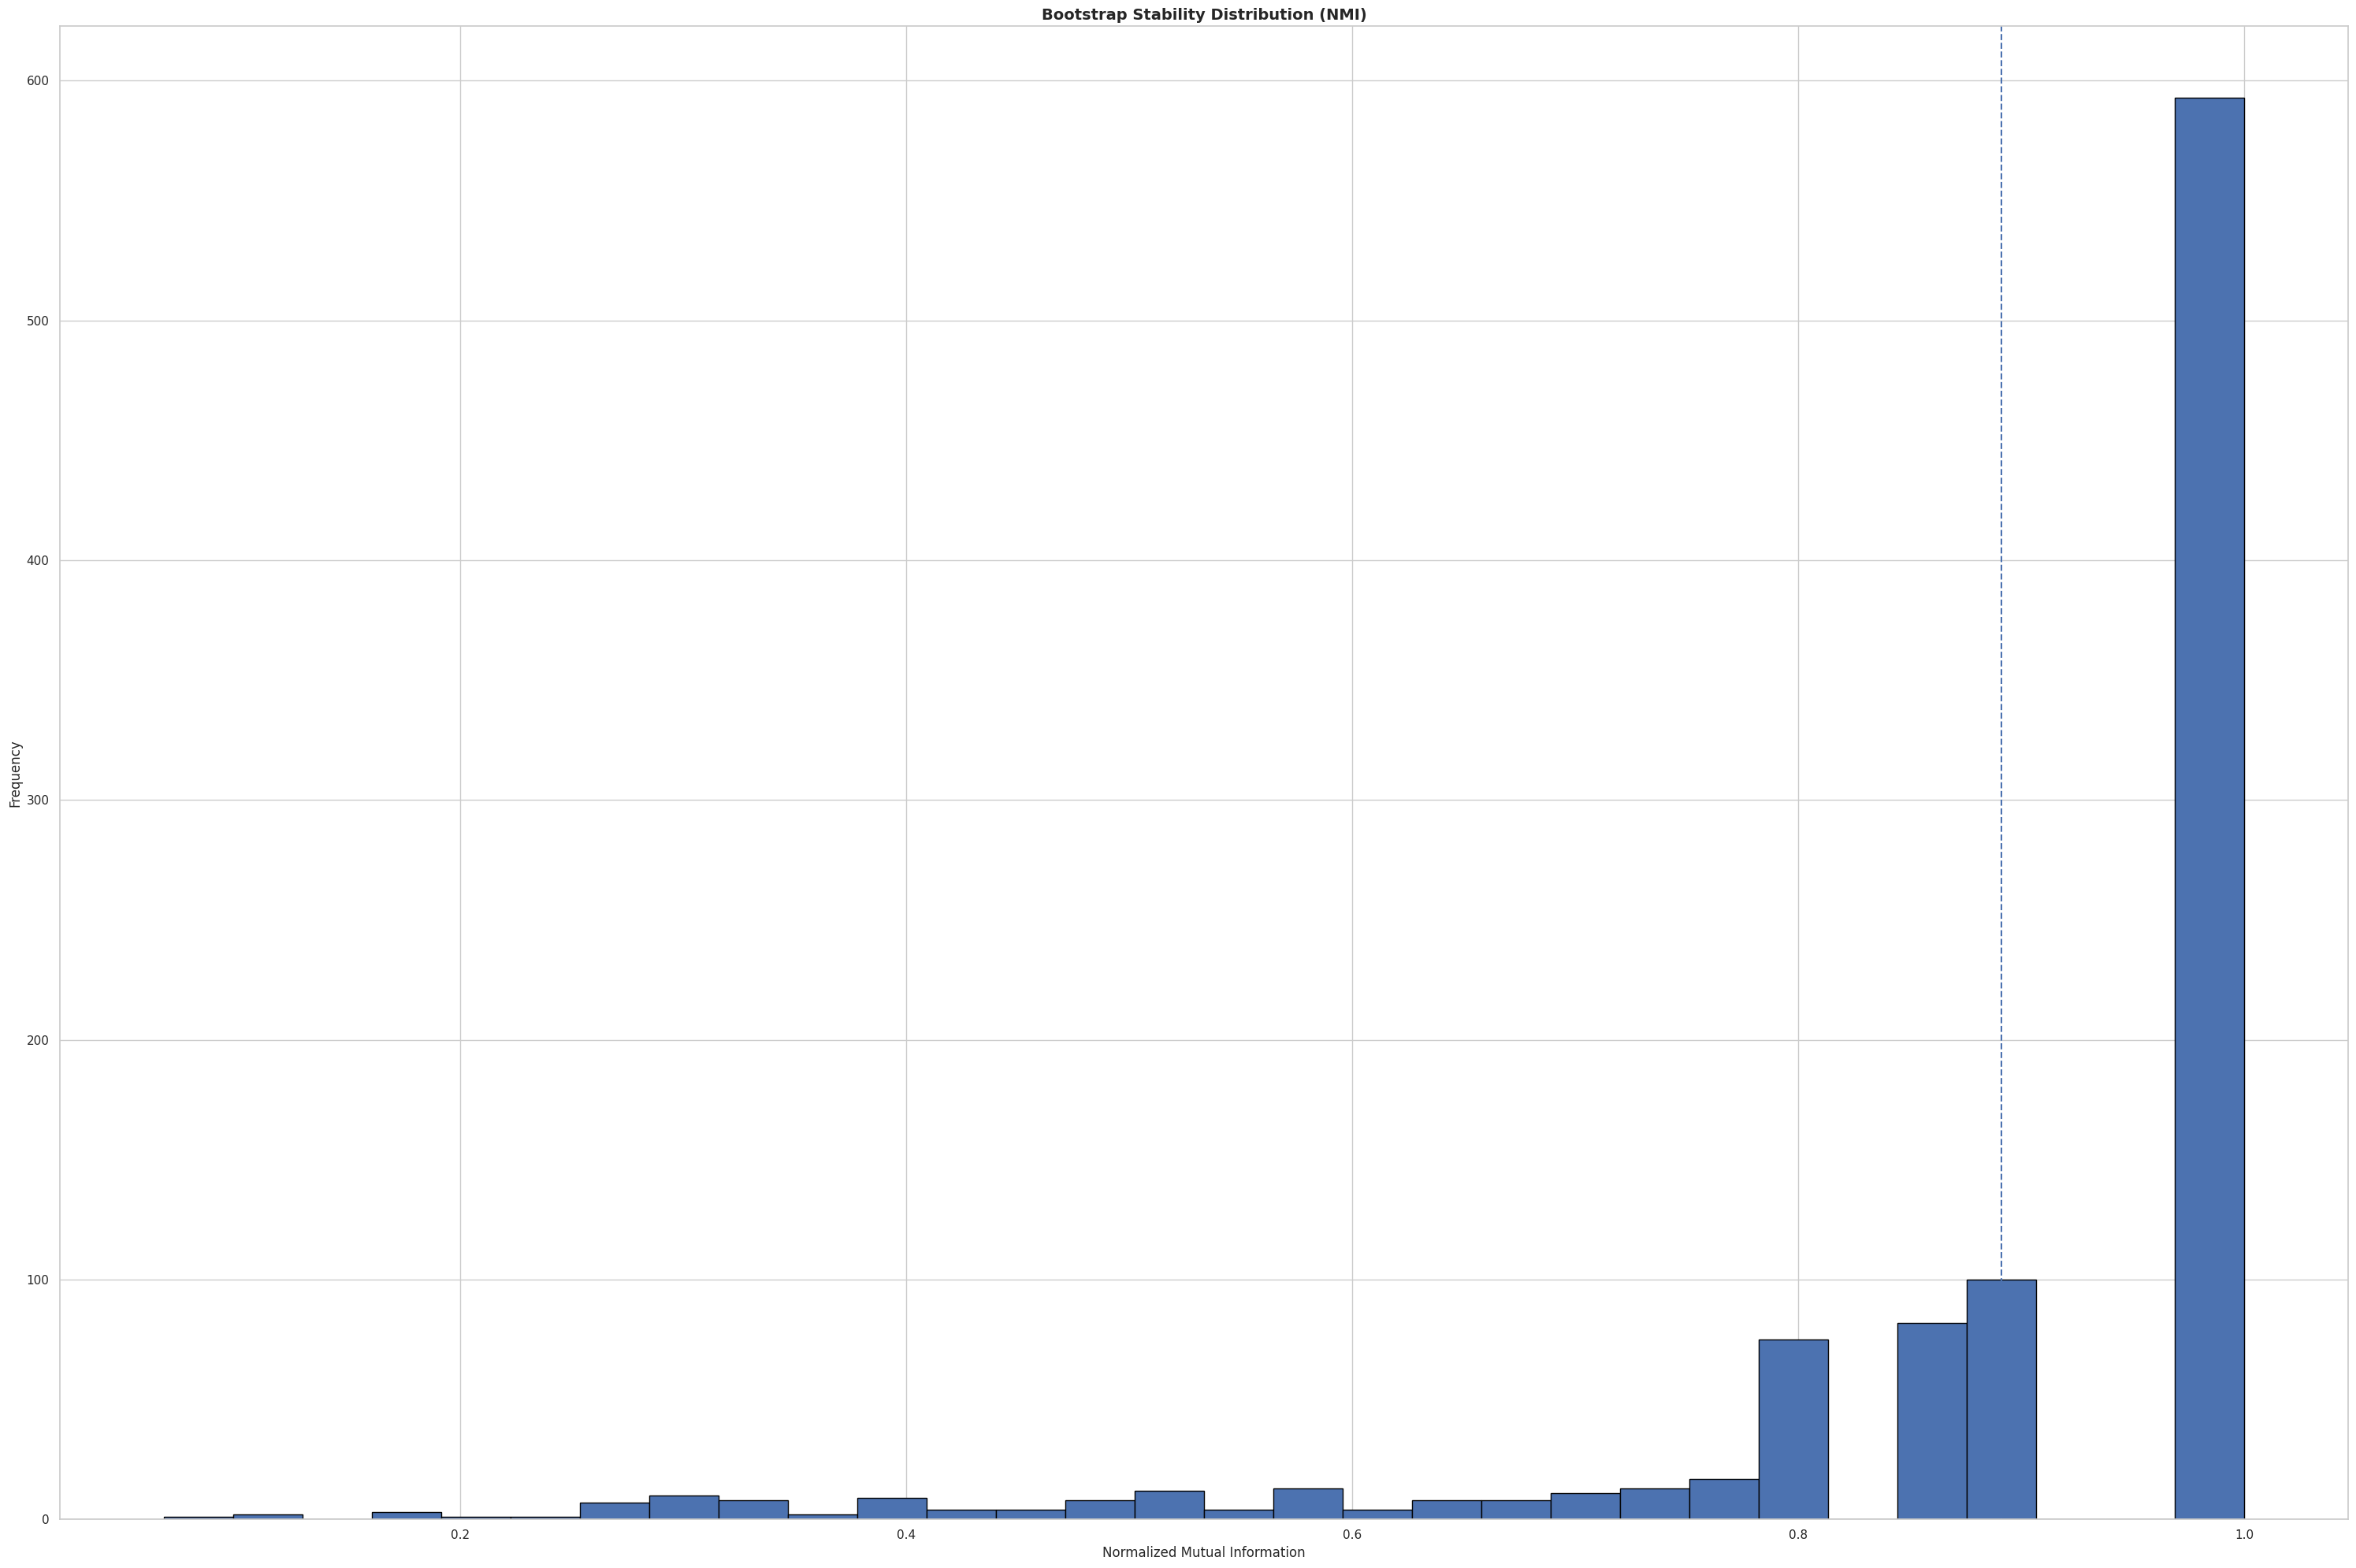

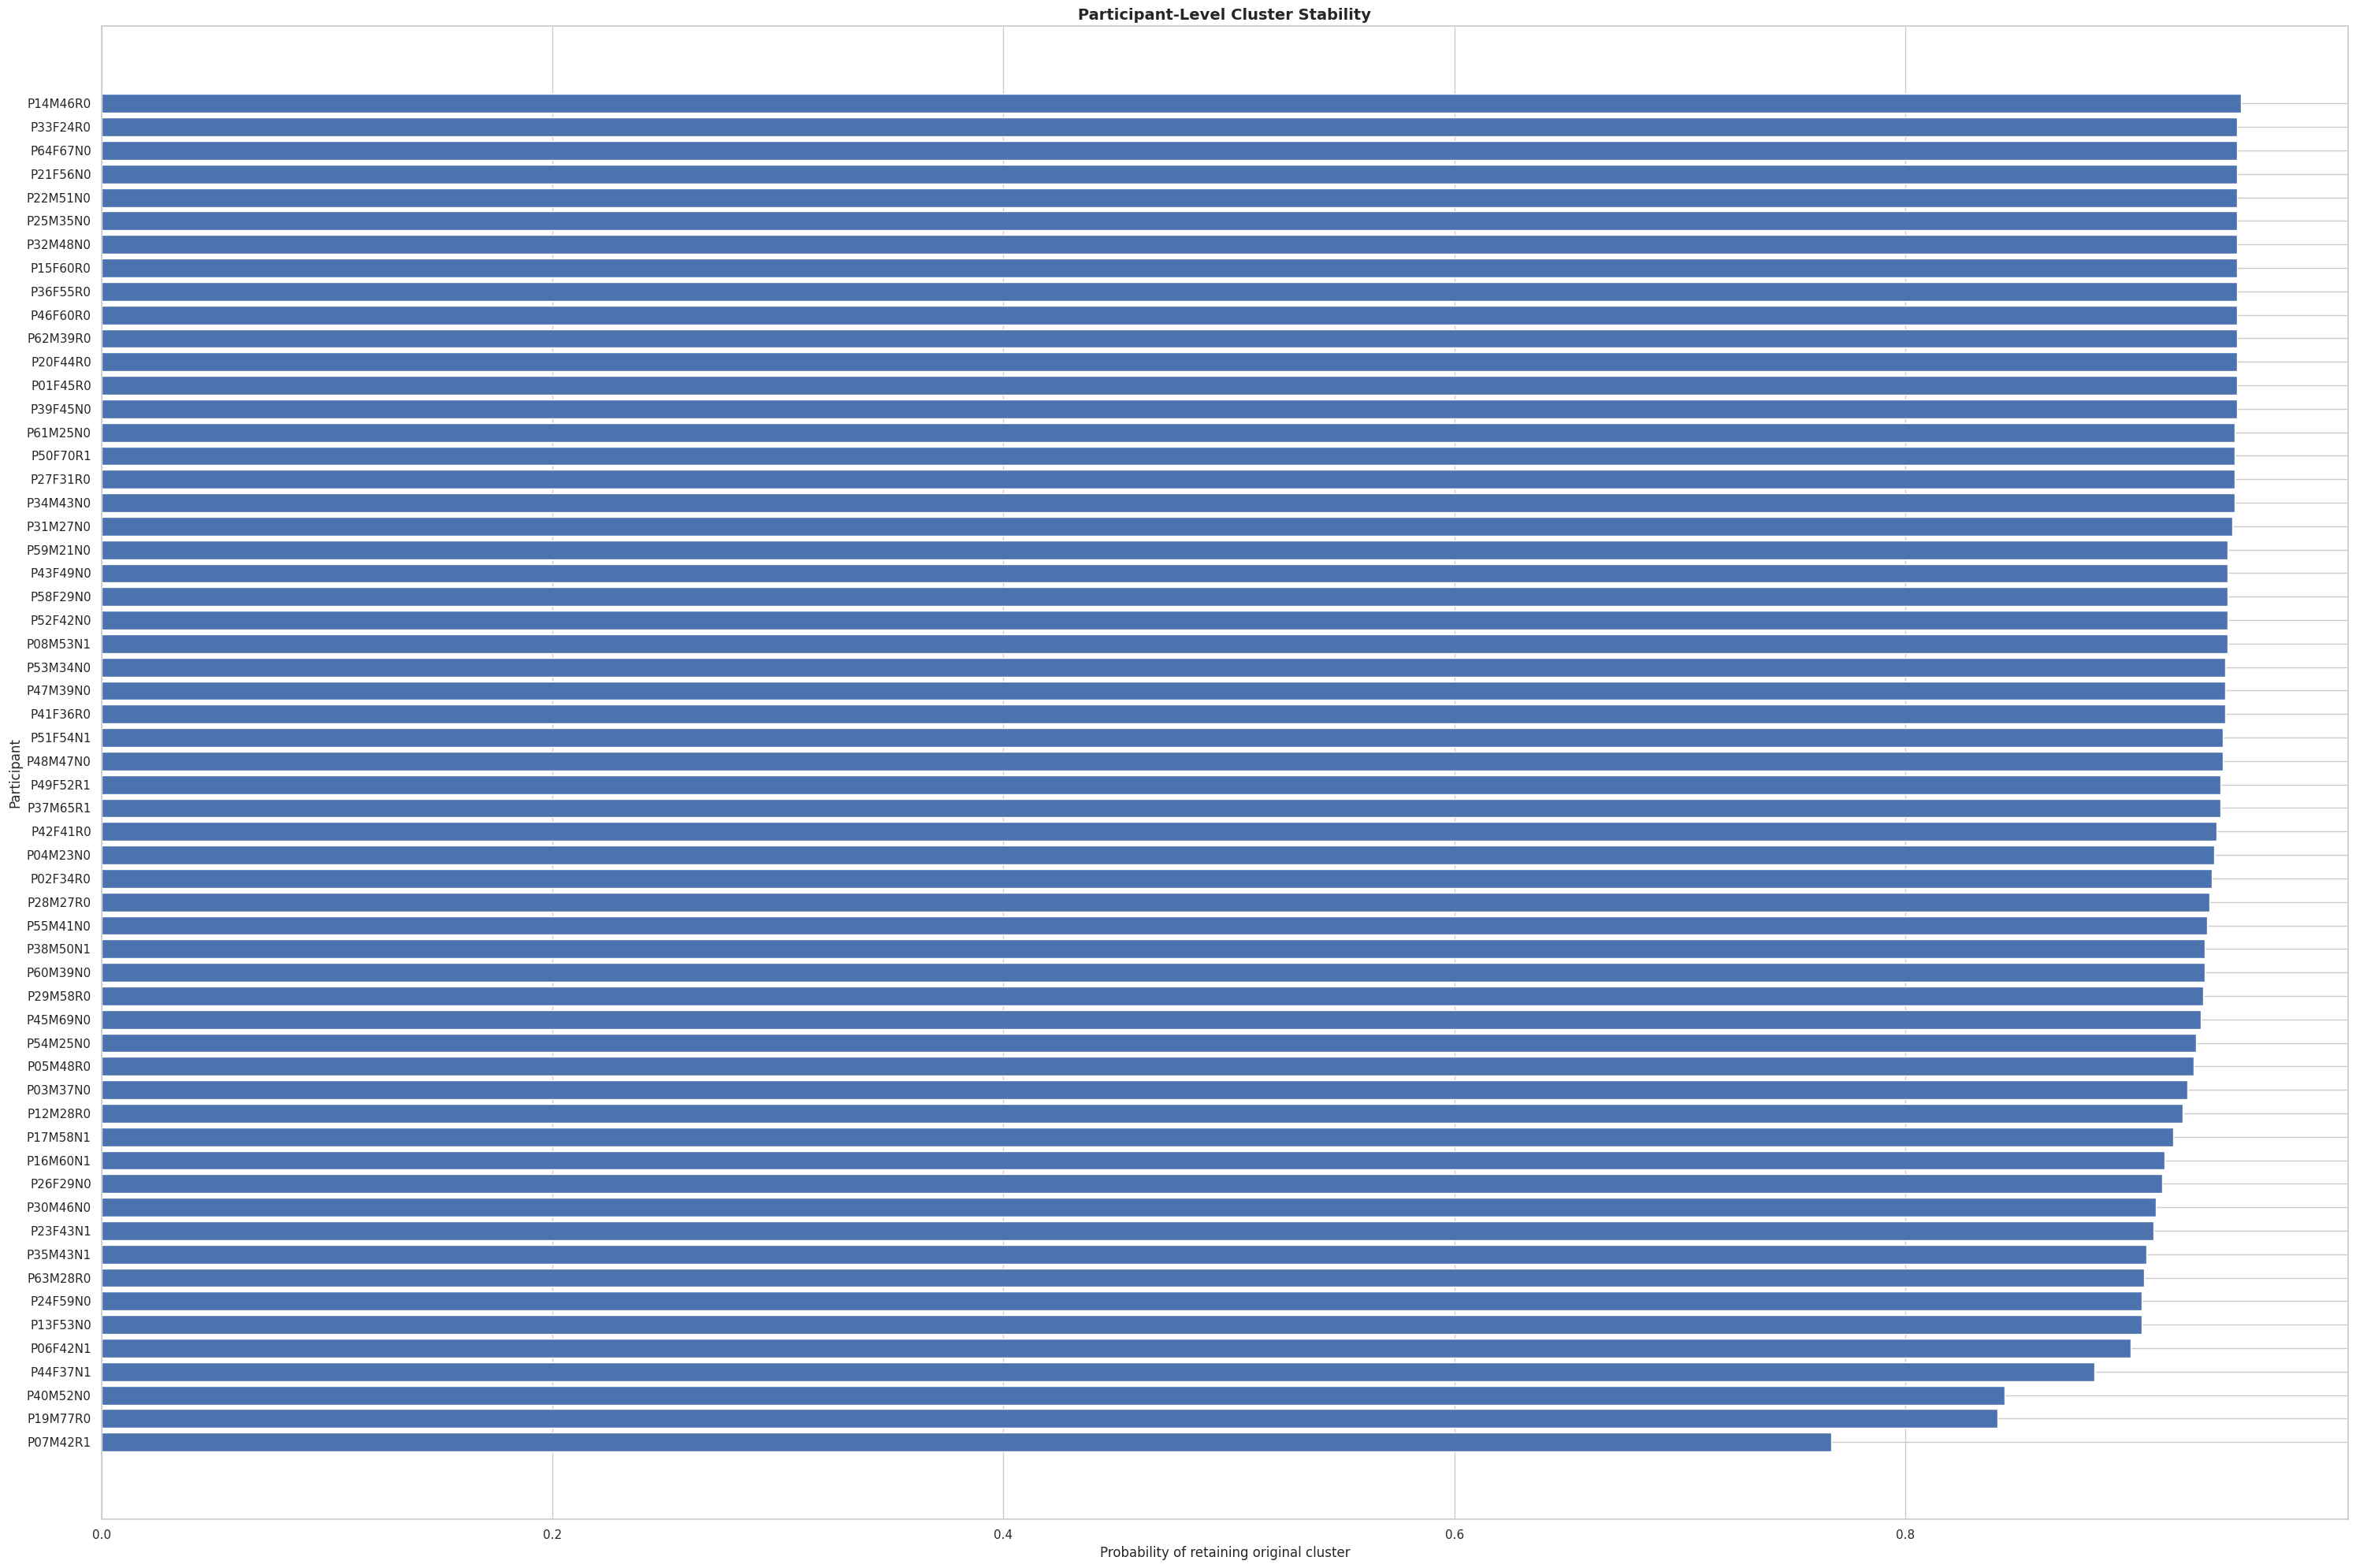


📊 Bootstrap stability summary:


,Metric,Value
0,ARI_mean,0.909
1,ARI_sd,0.185
2,ARI_median,1.000
3,NMI_mean,0.891
4,NMI_sd,0.179
5,NMI_median,1.000



📋 Least stable participants:


,Participant,Original_Cluster,Cluster_Stability_Prob
6,P07M42R1,1,0.767
14,P19M77R0,0,0.841
35,P40M52N0,1,0.844
39,P44F37N1,1,0.884
5,P06F42N1,0,0.900
9,P13F53N0,1,0.905
19,P24F59N0,1,0.905
56,P63M28R0,1,0.906
30,P35M43N1,1,0.907
18,P23F43N1,1,0.910



Bootstrap stability summary:


,Metric,Value
0,ARI_mean,0.909
1,ARI_sd,0.185
2,ARI_median,1.000
3,NMI_mean,0.891
4,NMI_sd,0.179
5,NMI_median,1.000



Participant-level stability:


,Participant,Original_Cluster,Cluster_Stability_Prob
10,P14M46R0,1,0.949
0,P01F45R0,1,0.947
15,P20F44R0,1,0.947
55,P62M39R0,1,0.947
41,P46F60R0,1,0.947
34,P39F45N0,1,0.947
31,P36F55R0,1,0.947
28,P33F24R0,1,0.947
27,P32M48N0,1,0.947
20,P25M35N0,1,0.947


In [7]:
# =============================================================================
# SHAP + PERMUTATION IMPORTANCE
# =============================================================================
def shap_analysis(
    df_clusters = TABLE_CLUSTER_PATH,
    DATA_OUTPUT_PATH = DATA_OUTPUT_PATH + "shap_results",
    PARTICIPANT_COLUMN_HEADER="Participant",
    CLUSTER_COLUMN_HEADER="Cluster",
    random_state=42,
    n_splits=10,
    n_estimators=500
):
    os.makedirs(DATA_OUTPUT_PATH, exist_ok=True)

    if CLUSTER_COLUMN_HEADER not in df_clusters.columns:
        raise ValueError(f"❌ Column '{CLUSTER_COLUMN_HEADER}' not found in df_clusters.")

    available_vars = [v for v in SHAP_COLUMN_HEADER_LIST if v in df_clusters.columns]
    missing_vars = [v for v in SHAP_COLUMN_HEADER_LIST if v not in df_clusters.columns]
    if missing_vars:
        print(f"⚠️ Missing variables ignored: {missing_vars}")

    X = df_clusters[available_vars].copy()
    y = df_clusters[CLUSTER_COLUMN_HEADER].copy()

    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.select_dtypes(include=[np.number])

    valid_y = y.notna()
    X = X.loc[valid_y].copy()
    y = y.loc[valid_y].copy()

    complete_rows = X.notna().all(axis=1)
    X = X.loc[complete_rows].copy()
    y = y.loc[complete_rows].copy()

    if X.empty:
        raise ValueError("❌ No valid numerical features available for SHAP analysis.")
    if y.nunique() != 2:
        raise ValueError("❌ Cluster outcome must be binary for this analysis.")

    print(f"✅ SHAP analysis using {X.shape[1]} features and {X.shape[0]} participants.")
    print("Features used:", list(X.columns))

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    from sklearn.ensemble import RandomForestClassifier
    rf_cv = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1
    )

    y_pred = cross_val_predict(rf_cv, X, y, cv=cv, method="predict")
    y_proba = cross_val_predict(rf_cv, X, y, cv=cv, method="predict_proba")[:, 1]

    cm = confusion_matrix(y, y_pred)

    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall (Sensitivity)": recall_score(y, y_pred, zero_division=0),
        "F1 Score": f1_score(y, y_pred, zero_division=0)
    }

    if cm.shape == (2, 2):
        tn, fp = cm[0, 0], cm[0, 1]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        metrics["Specificity"] = specificity

    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    metrics["AUC"] = roc_auc

    metrics_df = pd.DataFrame({"Metric": list(metrics.keys()), "Value": list(metrics.values())})
    metrics_df.to_csv(os.path.join(DATA_OUTPUT_PATH, "classification_metrics.csv"), index=False)

    print("\n📊 Classification metrics (cross-validated):")
    display(metrics_df.round(3))

    fig, ax = plt.subplots(figsize=(7, 6))
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="Random Forest").plot(ax=ax)
    ax.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.tight_layout()
    fig.savefig(os.path.join(DATA_OUTPUT_PATH, "roc_curve_rf.png"), dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.sort(y.unique())).plot(cmap="Blues", ax=ax)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    fig.savefig(os.path.join(DATA_OUTPUT_PATH, "confusion_matrix_rf.png"), dpi=300, bbox_inches="tight")
    plt.show()

    rf_final = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1
    )
    rf_final.fit(X, y)

    perm = permutation_importance(
        rf_final, X, y,
        n_repeats=50,
        random_state=random_state,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        "Feature": X.columns,
        "Permutation_Mean": perm.importances_mean,
        "Permutation_SD": perm.importances_std
    }).sort_values("Permutation_Mean", ascending=False)

    perm_df.to_csv(os.path.join(DATA_OUTPUT_PATH, "permutation_importance.csv"), index=False)

    print("\n📌 Permutation importance (top 10):")
    display(perm_df.head(10).round(3))

    explainer = shap.TreeExplainer(rf_final)
    shap_raw = explainer.shap_values(X)

    if isinstance(shap_raw, list):
        shap_vals = shap_raw[1] if len(shap_raw) == 2 else shap_raw[0]
    elif isinstance(shap_raw, np.ndarray):
        shap_vals = shap_raw[:, :, 1] if shap_raw.ndim == 3 else shap_raw
    else:
        raise ValueError("Unexpected SHAP output format.")

    feature_names_latex = [COLUMN_HEADER_STYLIZED.get(col, col) for col in X.columns]

    plt.figure()
    shap.summary_plot(
        shap_vals, X,
        plot_type="bar",
        feature_names=feature_names_latex,
        show=False
    )
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_OUTPUT_PATH, "shap_summary_bar.png"), dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure()
    shap.summary_plot(
        shap_vals, X,
        feature_names=feature_names_latex,
        show=False
    )
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_OUTPUT_PATH, "shap_summary_beeswarm.png"), dpi=300, bbox_inches="tight")
    plt.show()

    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    shap_df = pd.DataFrame({
        "Feature": X.columns,
        "Feature_label": feature_names_latex,
        "Mean_Abs_SHAP": mean_abs_shap
    }).sort_values("Mean_Abs_SHAP", ascending=False)

    shap_df.to_csv(os.path.join(DATA_OUTPUT_PATH, "shap_importance.csv"), index=False)

    print("\n📈 SHAP mean absolute importance (top 10):")
    display(shap_df.head(10).round(3))

    combined_df = shap_df.merge(perm_df, on="Feature", how="left")
    combined_df.to_csv(os.path.join(DATA_OUTPUT_PATH, "combined_importance_table.csv"), index=False)

    print("\n📎 Combined SHAP + permutation importance (top 10):")
    display(combined_df.head(10).round(3))

    top3 = shap_df["Feature"].head(3).tolist()
    for feature in top3:
        plt.figure()
        shap.dependence_plot(
            ind=feature,
            shap_values=shap_vals,
            features=X,
            feature_names=list(X.columns),
            show=False
        )
        plt.tight_layout()
        safe_name = feature.replace(" ", "_")
        plt.savefig(os.path.join(DATA_OUTPUT_PATH, f"dependence_{safe_name}.png"), dpi=300, bbox_inches="tight")
        plt.show()

    return {
        "shap_importance": shap_df,
        "permutation_importance": perm_df,
        "combined_importance": combined_df,
        "shap_values": shap_vals,
        "X": X,
        "y": y,
        "metrics": metrics_df,
        "confusion_matrix": cm,
        "model": rf_final
    }

# =============================================================================
# CLUSTER STABILITY VIA BOOTSTRAP
# =============================================================================
def _match_labels_by_centroids(ref_centers, boot_centers):
    """
    Match bootstrap cluster labels to reference cluster labels
    using minimal Euclidean distance between centroids.
    """
    cost = np.linalg.norm(ref_centers[:, None, :] - boot_centers[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {boot_label: ref_label for ref_label, boot_label in zip(row_ind, col_ind)}
    return mapping


def cluster_stability_bootstrap(
    df,
    features,
    cluster_col="Cluster",
    id_column="Participant",
    n_bootstrap=1000,
    var_threshold=0.80,
    n_clusters=2,
    max_components=None,
    random_state=42,
    output_dir="cluster_stability"
):
    """
    Bootstrap stability for PCA + KMeans clustering.

    Strategy:
    - Use original dataset as reference solution
    - For each bootstrap:
        1) resample rows with replacement
        2) fit scaler + PCA + KMeans in bootstrap sample
        3) project original data into bootstrap PCA space
        4) assign original participants to bootstrap centroids
        5) align cluster labels by centroid matching
        6) compare bootstrap-assigned labels vs original labels
    """
    os.makedirs(output_dir, exist_ok=True)

    rng = np.random.RandomState(random_state)

    # -------------------------------------------------------------------------
    # Prepare reference data
    # -------------------------------------------------------------------------
    cols_needed = [c for c in features if c in df.columns] + [cluster_col]
    if id_column in df.columns:
        cols_needed = [id_column] + cols_needed

    df_ref = df[cols_needed].copy()
    df_ref[features] = df_ref[features].apply(pd.to_numeric, errors="coerce")

    complete_mask = df_ref[features + [cluster_col]].notna().all(axis=1)
    df_ref = df_ref.loc[complete_mask].reset_index(drop=True)

    if df_ref.empty:
        raise ValueError("❌ No complete rows available for bootstrap stability analysis.")

    X_ref = df_ref[features].copy()
    y_ref = df_ref[cluster_col].astype(int).values
    participant_ids = df_ref[id_column].values if id_column in df_ref.columns else np.arange(len(df_ref))

    # -------------------------------------------------------------------------
    # Reference scaler + PCA space
    # -------------------------------------------------------------------------
    scaler_ref = StandardScaler()
    X_ref_scaled = scaler_ref.fit_transform(X_ref)

    if max_components is None:
        max_components = min(X_ref.shape[1], 10)

    pca_ref_full = PCA(n_components=min(max_components, X_ref.shape[1]), random_state=random_state)
    X_ref_pca_full = pca_ref_full.fit_transform(X_ref_scaled)
    cumvar_ref = np.cumsum(pca_ref_full.explained_variance_ratio_)

    n_components = np.searchsorted(cumvar_ref, var_threshold) + 1
    X_ref_pca = X_ref_pca_full[:, :n_components]

    # Reference centroids computed from original labels in the reference PCA space
    ref_centers = np.vstack([
        X_ref_pca[y_ref == lab].mean(axis=0) for lab in sorted(np.unique(y_ref))
    ])

    # -------------------------------------------------------------------------
    # Bootstrap loop
    # -------------------------------------------------------------------------
    ari_scores = []
    nmi_scores = []
    same_cluster_matrix = np.zeros((len(df_ref), n_bootstrap), dtype=float)

    for b in range(n_bootstrap):
        boot_idx = rng.choice(len(df_ref), size=len(df_ref), replace=True)
        X_boot = X_ref.iloc[boot_idx].copy()

        # Fit bootstrap scaler + PCA
        scaler_boot = StandardScaler()
        X_boot_scaled = scaler_boot.fit_transform(X_boot)

        pca_boot_full = PCA(n_components=min(max_components, X_boot.shape[1]), random_state=random_state)
        X_boot_pca_full = pca_boot_full.fit_transform(X_boot_scaled)
        cumvar_boot = np.cumsum(pca_boot_full.explained_variance_ratio_)
        n_comp_boot = np.searchsorted(cumvar_boot, var_threshold) + 1
        X_boot_pca = X_boot_pca_full[:, :n_comp_boot]

        # Keep same dimensionality as reference when possible
        if n_comp_boot != n_components:
            use_dim = min(n_components, n_comp_boot)
            X_boot_pca = X_boot_pca[:, :use_dim]

            # Project original data in bootstrap space with same usable dimensions
            X_ref_boot_scaled = scaler_boot.transform(X_ref)
            X_ref_boot_pca = pca_boot_full.transform(X_ref_boot_scaled)[:, :use_dim]

            ref_centers_use = ref_centers[:, :use_dim]
        else:
            X_ref_boot_scaled = scaler_boot.transform(X_ref)
            X_ref_boot_pca = pca_boot_full.transform(X_ref_boot_scaled)[:, :n_components]
            ref_centers_use = ref_centers

        # Fit KMeans in bootstrap sample
        km_boot = KMeans(
            n_clusters=n_clusters,
            random_state=random_state + b,
            n_init=20
        )
        boot_labels_sample = km_boot.fit_predict(X_boot_pca)
        boot_centers = km_boot.cluster_centers_

        # Align labels to reference
        mapping = _match_labels_by_centroids(ref_centers_use, boot_centers)

        # Predict labels for original participants in bootstrap solution
        pred_boot_orig = km_boot.predict(X_ref_boot_pca)
        pred_boot_orig_aligned = np.array([mapping[label] for label in pred_boot_orig])

        # Stability metrics
        ari = adjusted_rand_score(y_ref, pred_boot_orig_aligned)
        nmi = normalized_mutual_info_score(y_ref, pred_boot_orig_aligned)

        ari_scores.append(ari)
        nmi_scores.append(nmi)
        same_cluster_matrix[:, b] = (pred_boot_orig_aligned == y_ref).astype(float)

    # -------------------------------------------------------------------------
    # Summaries
    # -------------------------------------------------------------------------
    participant_stability = same_cluster_matrix.mean(axis=1)

    participant_stability_df = pd.DataFrame({
        id_column: participant_ids,
        "Original_Cluster": y_ref,
        "Cluster_Stability_Prob": participant_stability
    }).sort_values("Cluster_Stability_Prob", ascending=False)

    stability_summary = pd.DataFrame({
        "Metric": ["ARI_mean", "ARI_sd", "ARI_median", "NMI_mean", "NMI_sd", "NMI_median"],
        "Value": [
            np.mean(ari_scores), np.std(ari_scores, ddof=1), np.median(ari_scores),
            np.mean(nmi_scores), np.std(nmi_scores, ddof=1), np.median(nmi_scores)
        ]
    })

    participant_stability_df.to_csv(
        os.path.join(output_dir, "participant_cluster_stability.csv"),
        index=False
    )
    stability_summary.to_csv(
        os.path.join(output_dir, "bootstrap_stability_summary.csv"),
        index=False
    )

    # -------------------------------------------------------------------------
    # Plots
    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(30, 20))
    ax.hist(ari_scores, bins=30, edgecolor="black")
    ax.axvline(np.mean(ari_scores), linestyle="--", linewidth=1.5)
    ax.set_title("Bootstrap Stability Distribution (ARI)")
    ax.set_xlabel("Adjusted Rand Index")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, "bootstrap_ari_distribution.png"), dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(30, 20))
    ax.hist(nmi_scores, bins=30, edgecolor="black")
    ax.axvline(np.mean(nmi_scores), linestyle="--", linewidth=1.5)
    ax.set_title("Bootstrap Stability Distribution (NMI)")
    ax.set_xlabel("Normalized Mutual Information")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, "bootstrap_nmi_distribution.png"), dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(30, 20))
    participant_stability_df_sorted = participant_stability_df.sort_values("Cluster_Stability_Prob")
    ax.barh(
        participant_stability_df_sorted[id_column].astype(str),
        participant_stability_df_sorted["Cluster_Stability_Prob"]
    )
    ax.set_xlabel("Probability of retaining original cluster")
    ax.set_ylabel(id_column)
    ax.set_title("Participant-Level Cluster Stability")
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, "participant_cluster_stability.png"), dpi=300, bbox_inches="tight")
    plt.show()

    print("\n📊 Bootstrap stability summary:")
    display(stability_summary.round(3))

    print("\n📋 Least stable participants:")
    display(participant_stability_df.sort_values("Cluster_Stability_Prob").head(10).round(3))

    return {
        "ari_scores": np.array(ari_scores),
        "nmi_scores": np.array(nmi_scores),
        "participant_stability": participant_stability_df,
        "summary": stability_summary
    }


# =============================================================================
# COMPLETE EXECUTION
# =============================================================================

shap_output_dir = DATA_SOURCE_PATH + "shap_results"
stability_output_dir = DATA_SOURCE_PATH + "cluster_stability_results"

# 2. Load clustered dataset
dataframe_cluster = pd.read_csv(TABLE_CLUSTER_PATH)

print("✅ df_clusters loaded:")
print(dataframe_cluster.shape)
print(dataframe_cluster.columns.tolist())

# 4. SHAP + permutation importance
shap_results = shap_analysis(
    df_clusters=dataframe_cluster,
    DATA_OUTPUT_PATH=shap_output_dir,
    PARTICIPANT_COLUMN_HEADER="Participant",
    CLUSTER_COLUMN_HEADER="Cluster",
    random_state=42,
    n_splits=10,
    n_estimators=500
)

print("\nTop 10 SHAP features:")
display(shap_results["shap_importance"].head(10).round(3))

print("\nTop 10 permutation importance features:")
display(shap_results["permutation_importance"].head(10).round(3))

print("\nClassification metrics:")
display(shap_results["metrics"].round(3))

stability_results = cluster_stability_bootstrap(
    df=dataframe_cluster,
    features=CLUSTERING_COLUMN_HEADER_LIST,
    cluster_col=CLUSTER_COLUMN_HEADER,
    id_column=PARTICIPANT_COLUMN_HEADER,
    n_bootstrap=1000,
    var_threshold=0.80,
    n_clusters=2,
    max_components=10,
    random_state=42,
    output_dir=stability_output_dir
)

print("\nBootstrap stability summary:")
display(stability_results["summary"].round(3))

print("\nParticipant-level stability:")
display(stability_results["participant_stability"].head(10).round(3))

# Cluster Comparison Pipeline – Summary

This pipeline compares clusters based on numerical and binary features, applies statistical tests,
and generates annotated visualizations and summary outputs.



,Variable,Test,Statistic,Effect size,p-value,Mean Cluster 0,Mean Cluster 1,Median Cluster 0,Median Cluster 1,SD Cluster 0,SD Cluster 1,Min Cluster 0,Min Cluster 1,Max Cluster 0,Max Cluster 1,p-value (FDR),Significant (FDR)
6,RA,t-test,-9.38,2.54,0.00,0.56,0.79,0.56,0.79,0.11,0.08,0.28,0.64,0.70,0.93,0.00,✅
9,IS,Mann-Whitney,13.00,5.62,0.00,0.24,0.49,0.26,0.47,0.07,0.11,0.11,0.30,0.37,0.72,0.00,✅
26,QPActivity,Mann-Whitney,30.00,5.32,0.00,9.64,17.49,9.37,17.37,2.43,4.08,6.40,9.00,14.36,26.89,0.00,✅
10,ISm,t-test,-5.85,1.75,0.00,0.34,0.55,0.33,0.54,0.12,0.12,0.10,0.28,0.56,0.80,0.00,✅
22,LRI,t-test,-5.38,1.58,0.00,45.27,62.46,41.47,62.46,10.91,10.86,30.66,38.97,68.22,84.26,0.00,✅
13,L5,Mann-Whitney,594.00,4.49,0.00,679.87,335.87,593.12,290.19,279.58,150.10,289.53,101.03,1396.54,691.95,0.00,✅
12,M10o,t-test,4.23,1.12,0.00,603.75,447.38,610.00,445.00,164.23,108.58,270.00,200.00,970.00,740.00,0.00,✅
23,M10olight,Mann-Whitney,540.50,3.56,0.00,472.50,410.90,439.50,417.00,86.60,34.12,389.00,330.00,720.00,520.00,0.00,✅
25,PeriodActivity,Mann-Whitney,467.00,2.28,0.00,1445.62,1440.48,1440.00,1440.00,10.63,3.63,1440.00,1435.00,1480.00,1460.00,0.01,✅
30,QPTemperature,t-test,-2.88,0.90,0.01,15.98,23.01,15.88,22.02,6.66,8.85,0.32,7.77,26.55,47.39,0.02,✅


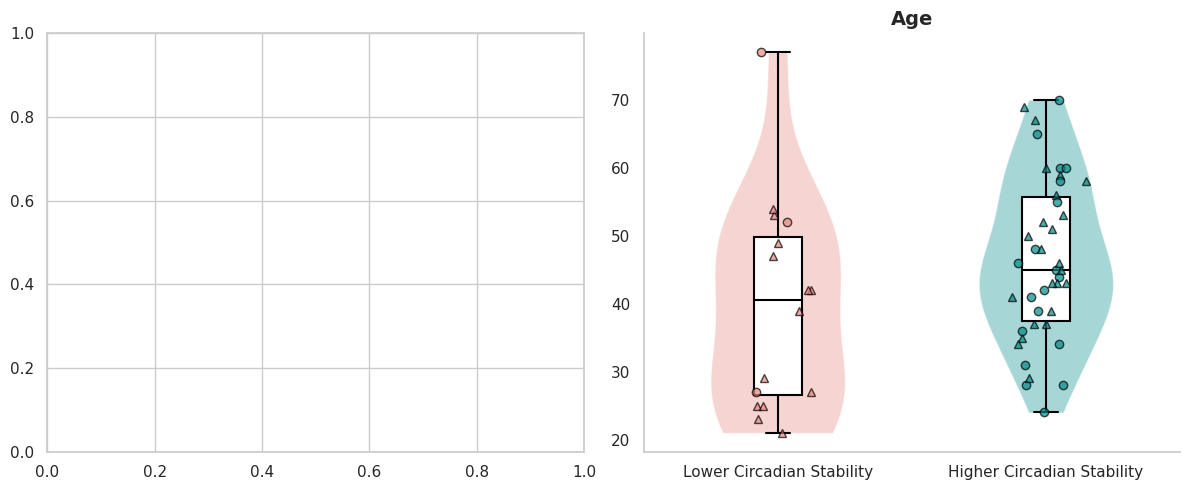

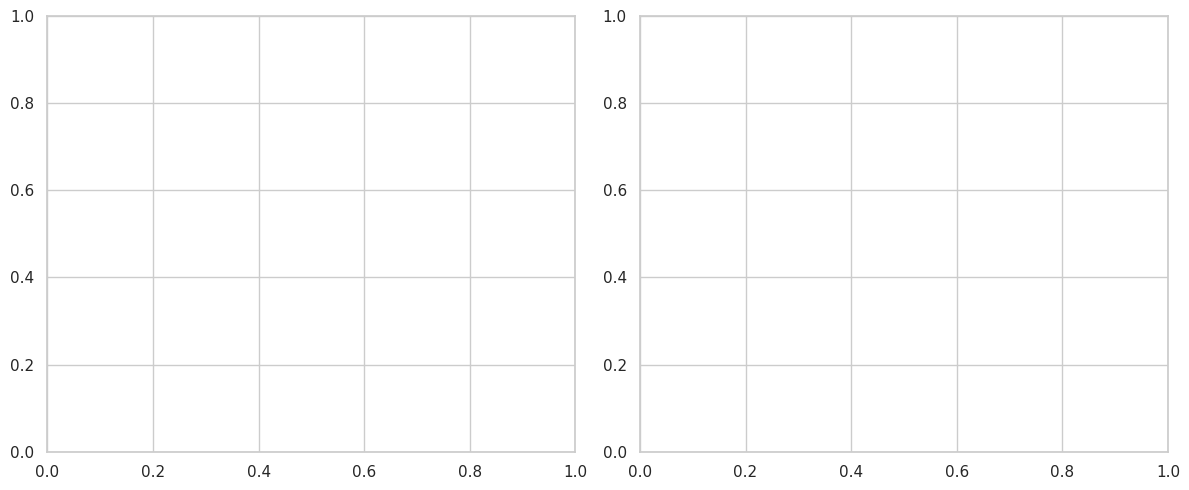

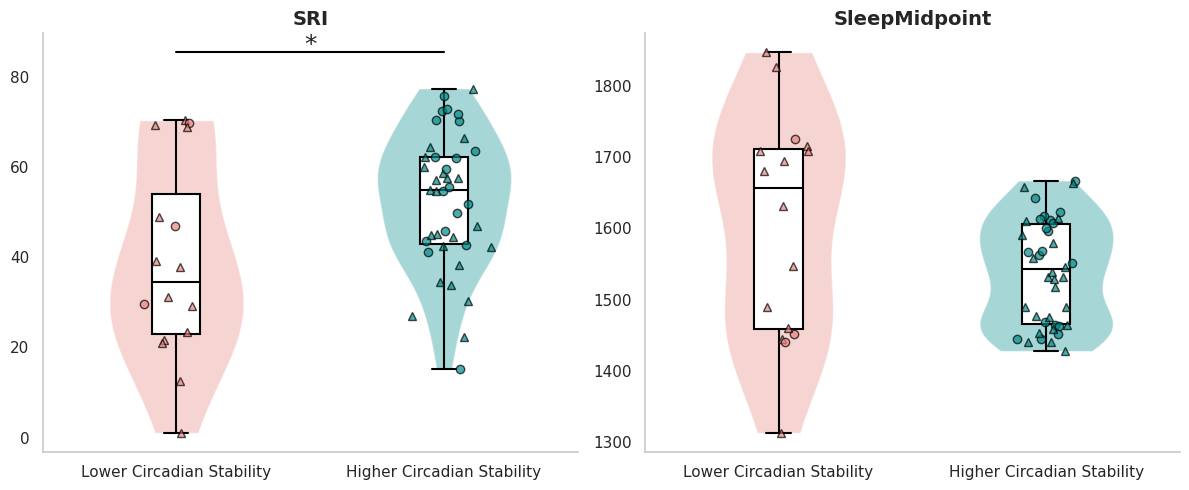

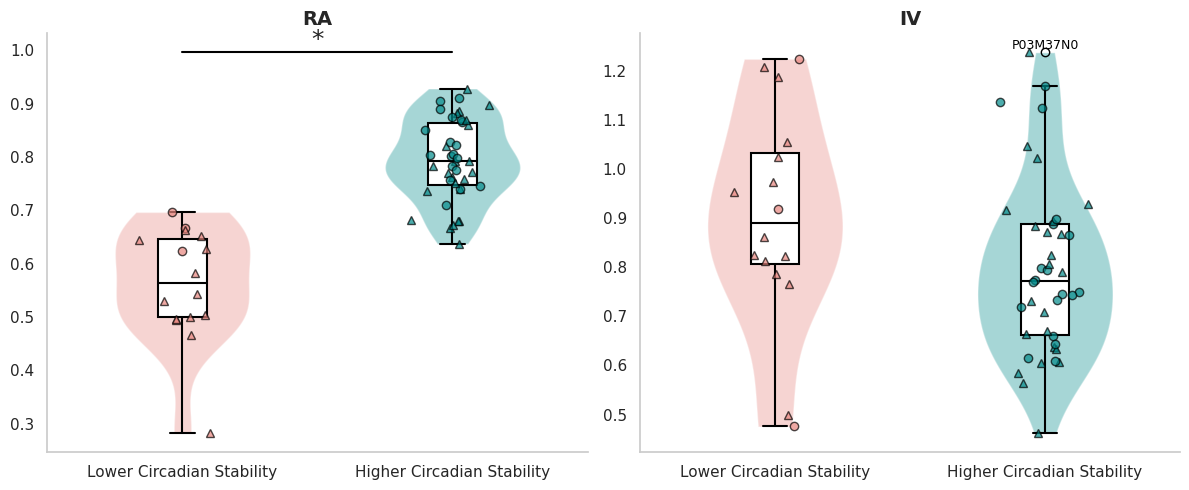

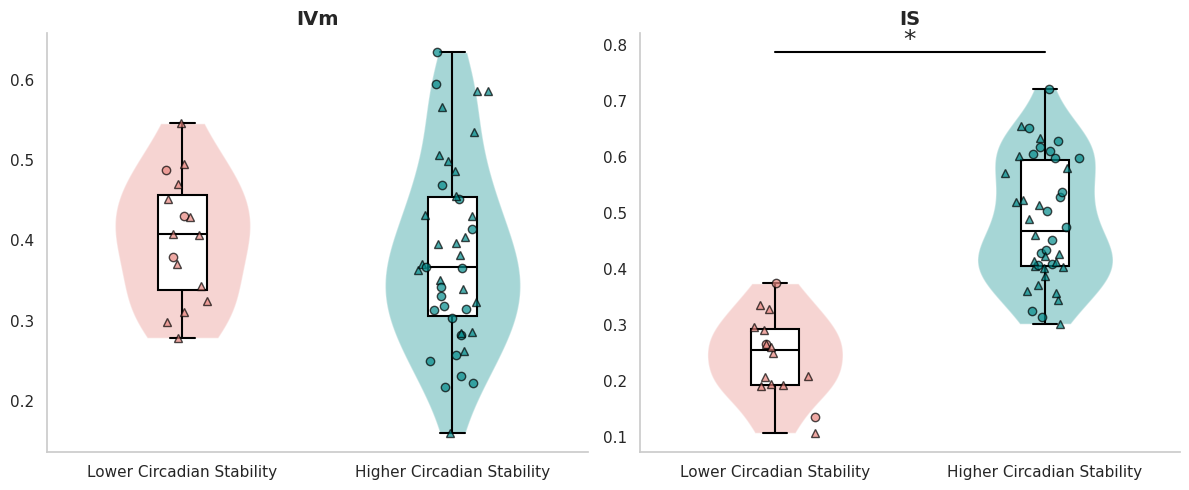

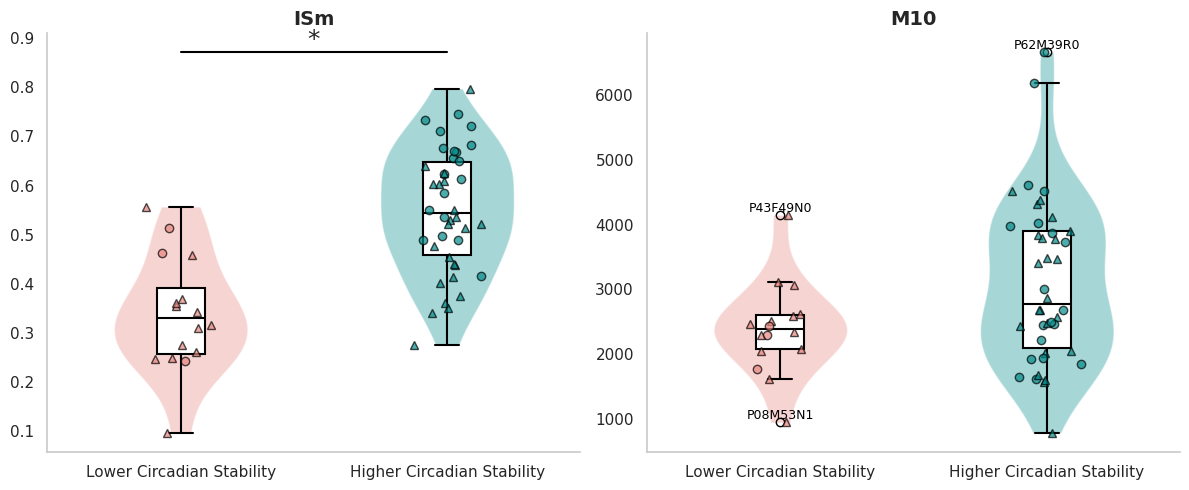

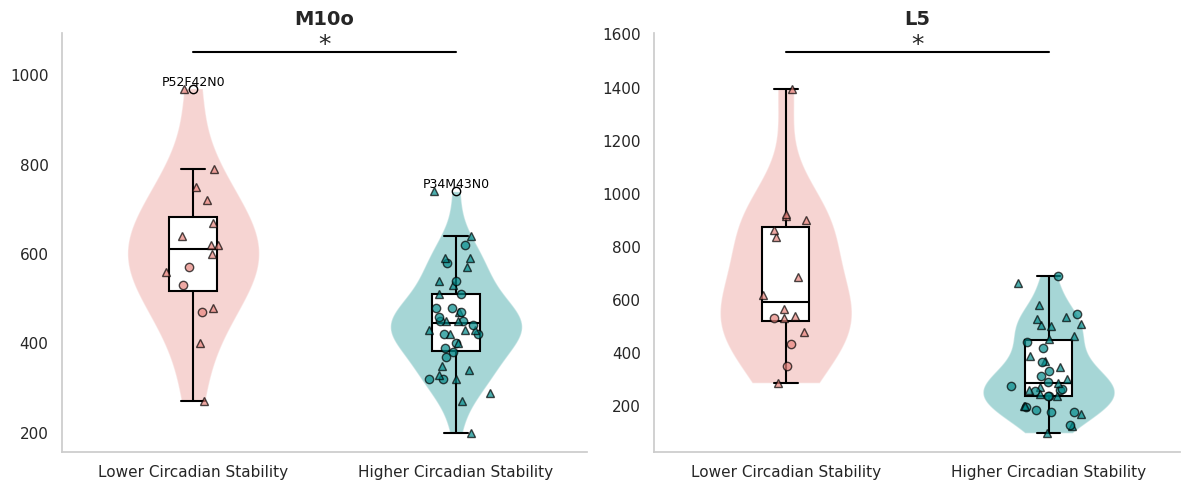

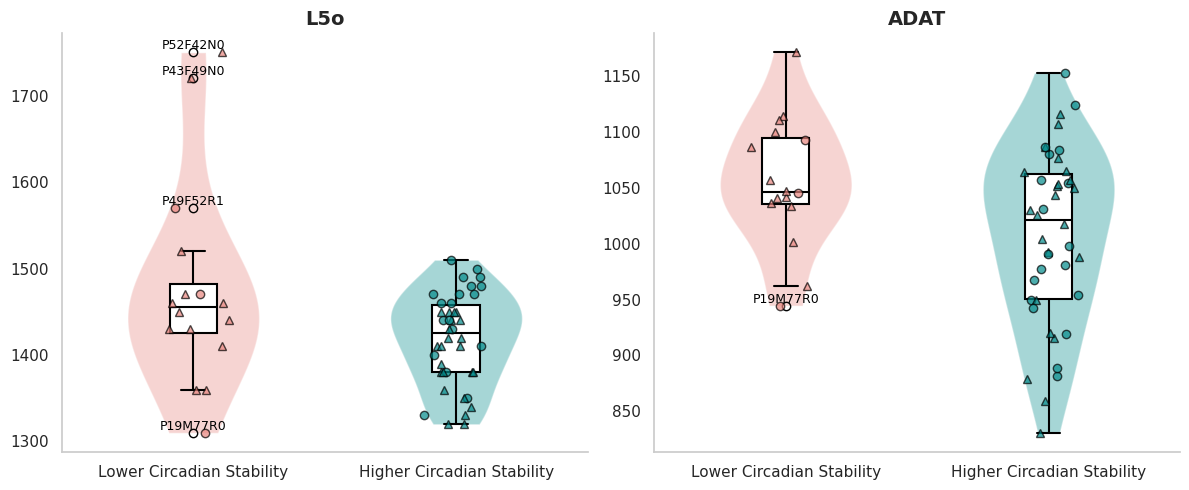

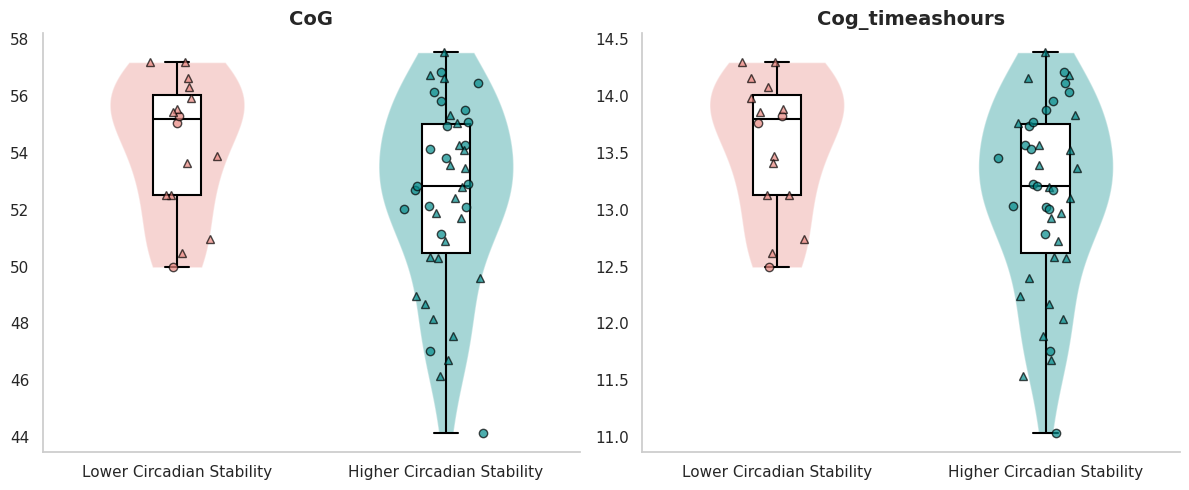

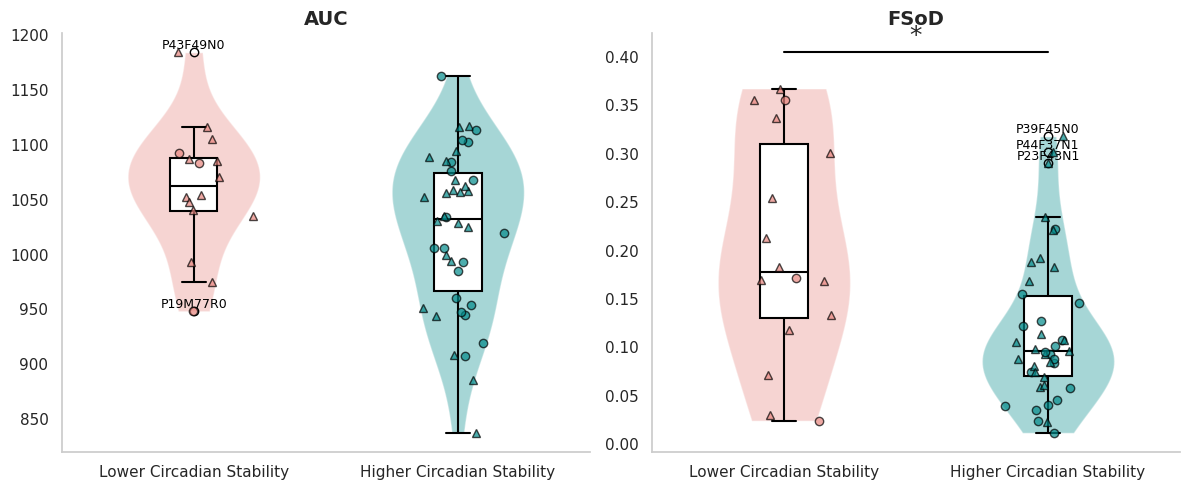

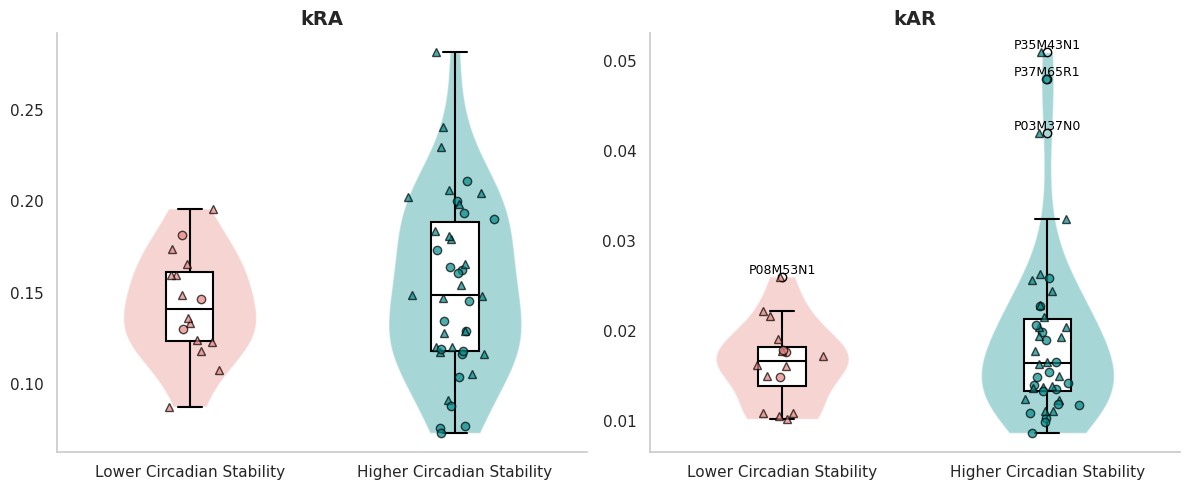

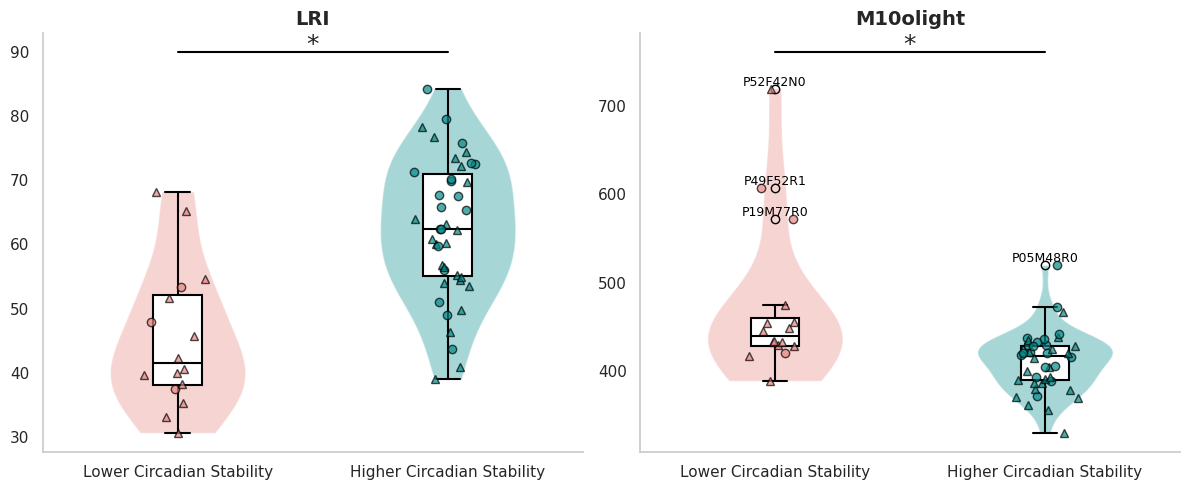

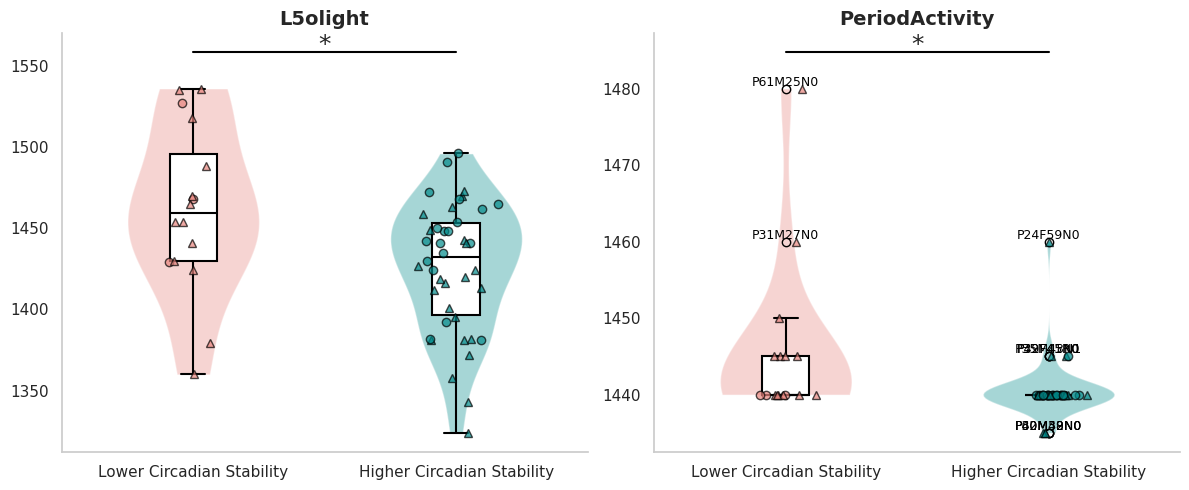

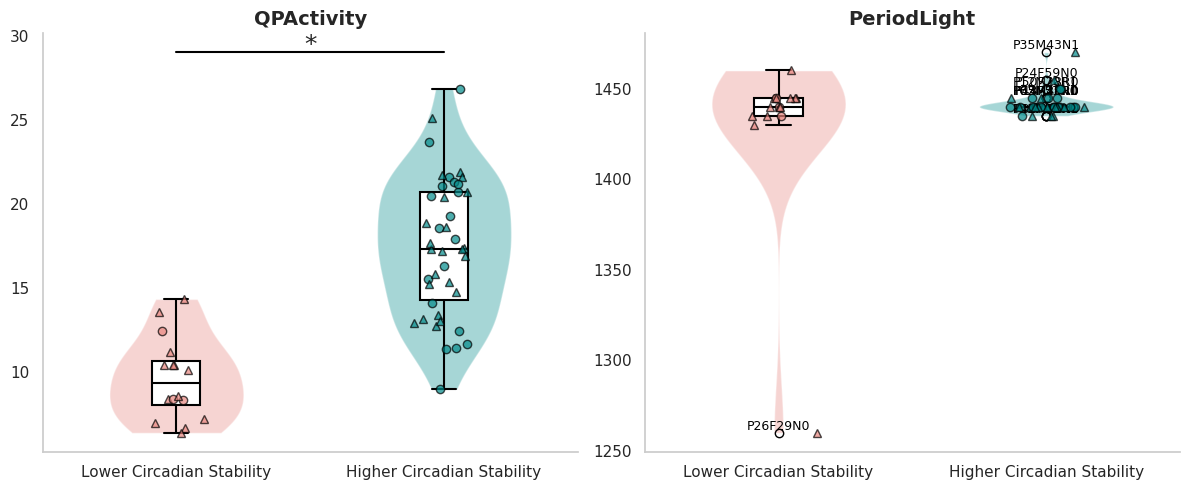

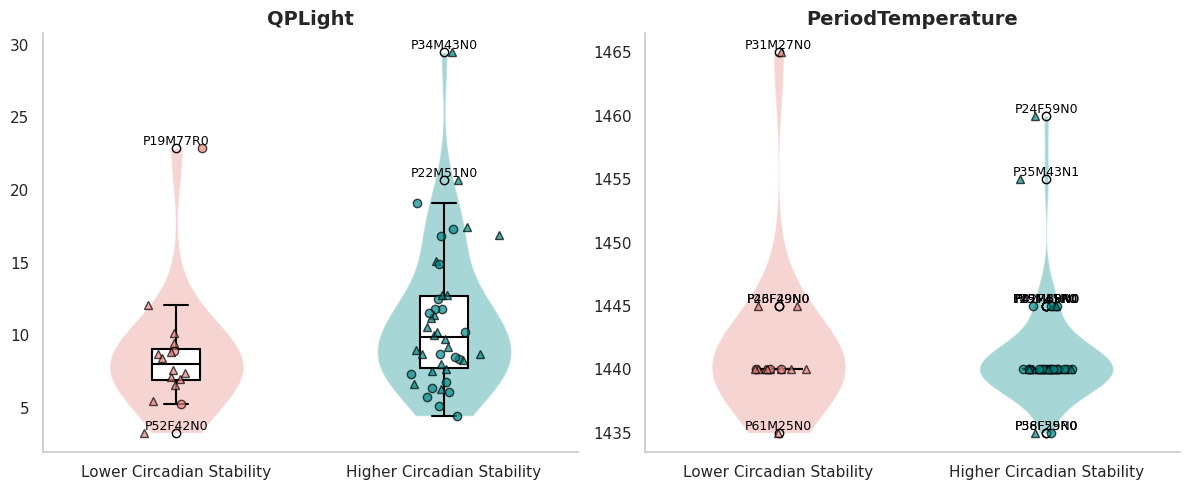

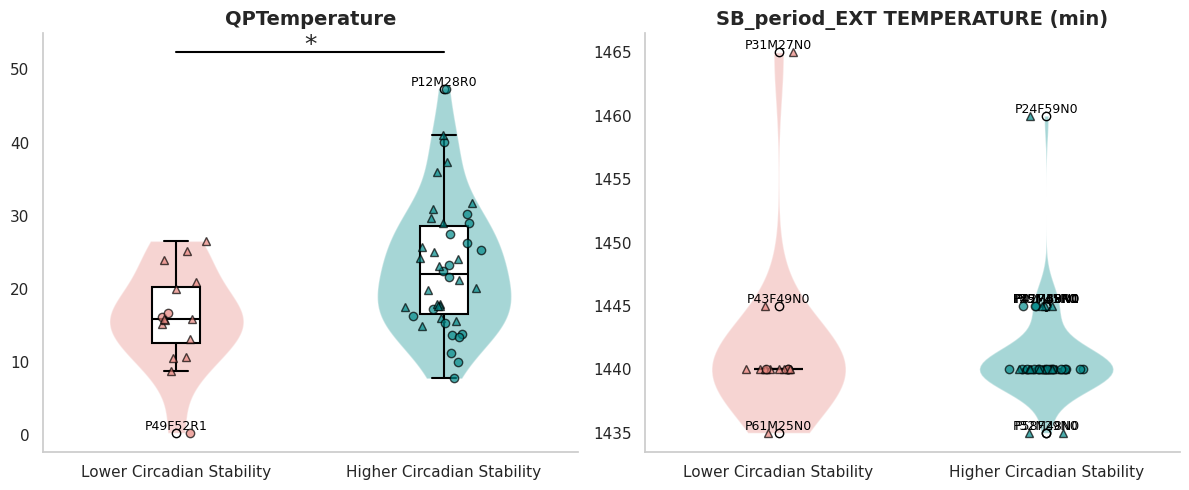

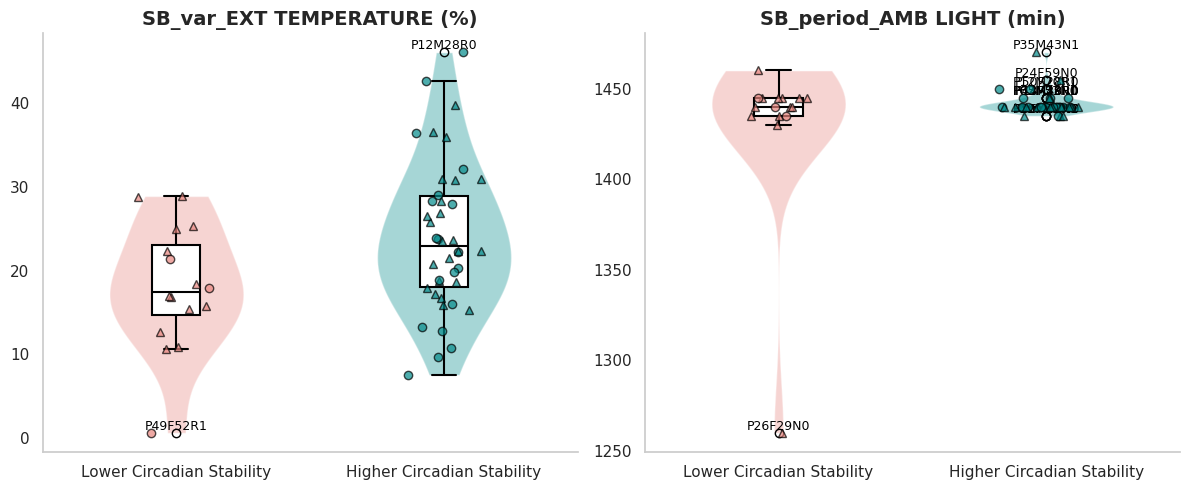

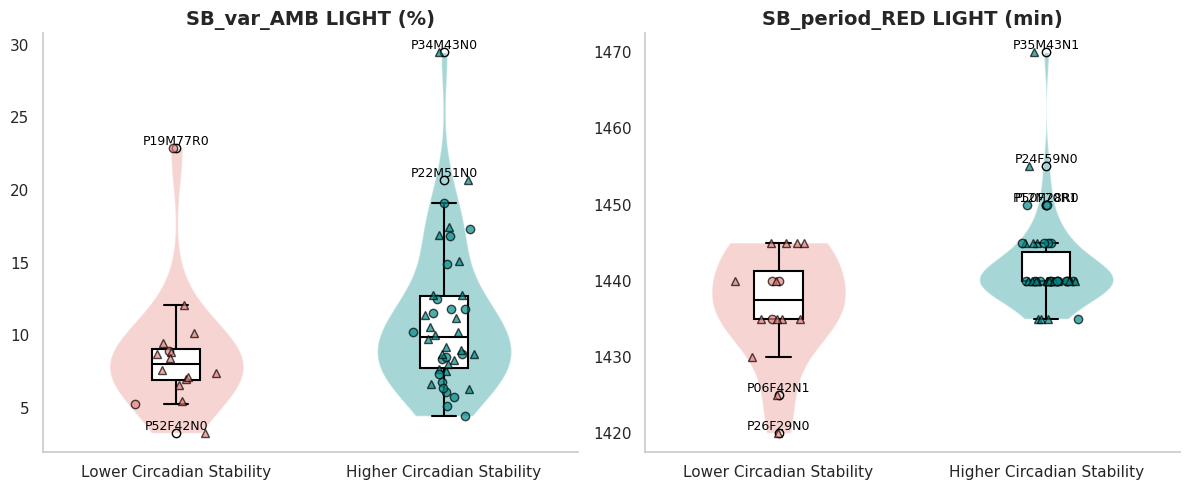

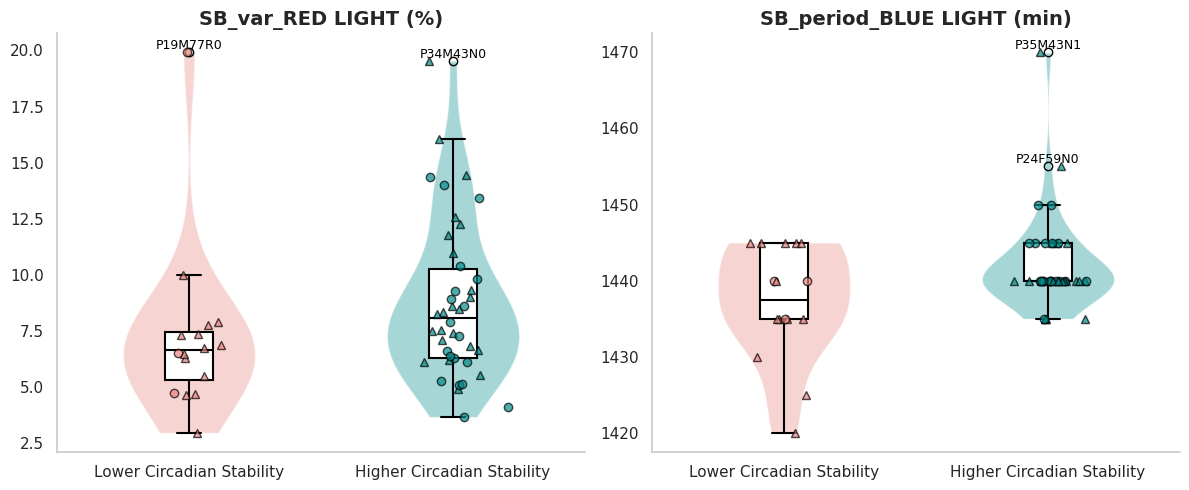

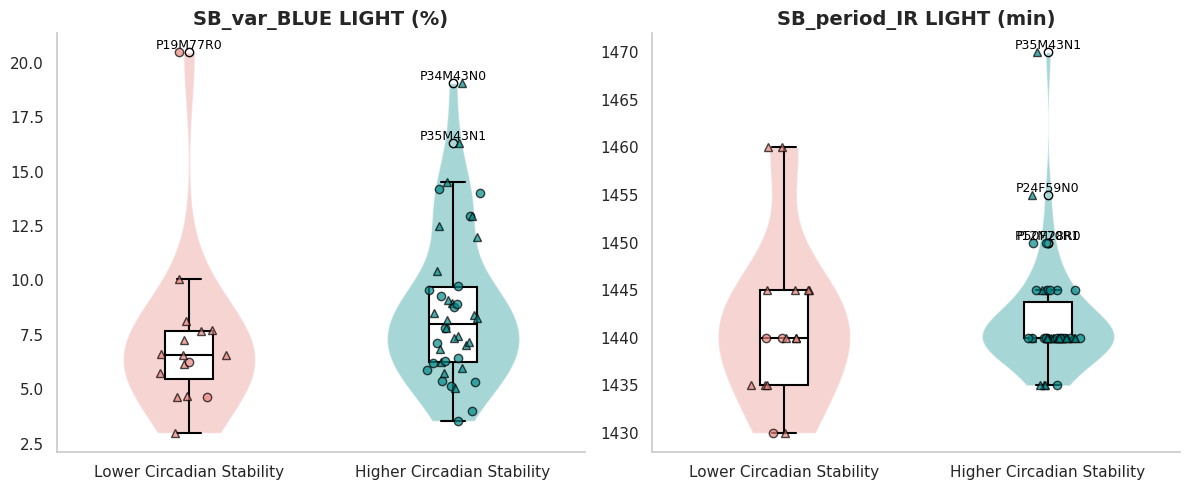

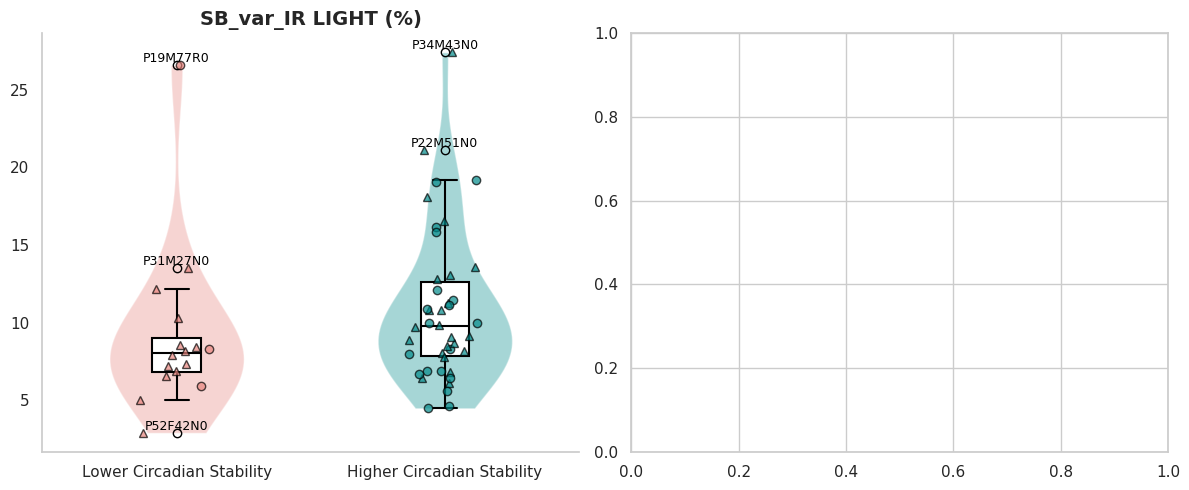

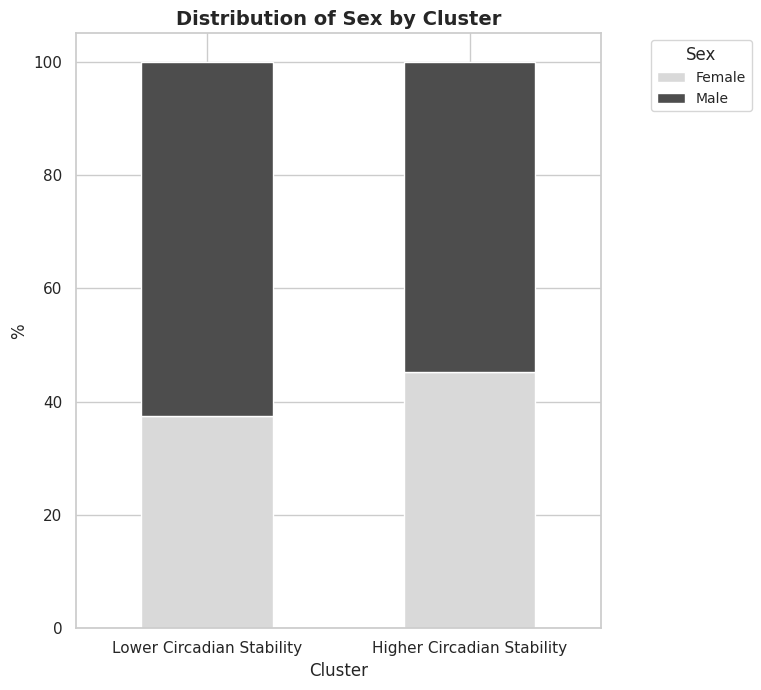

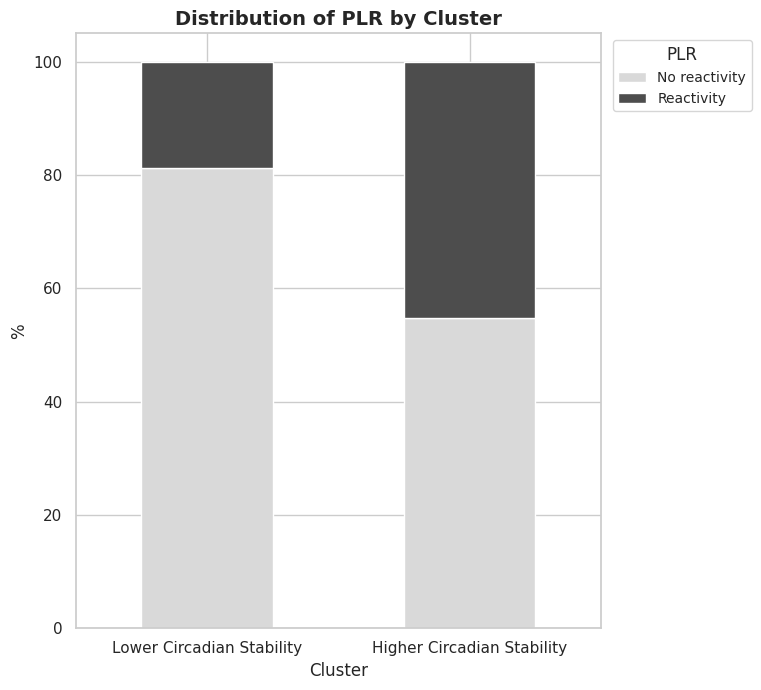

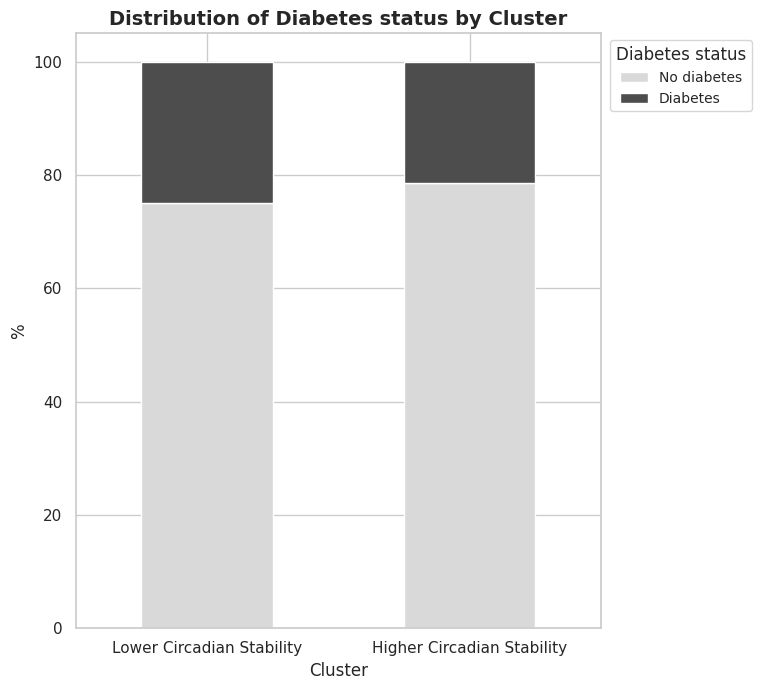

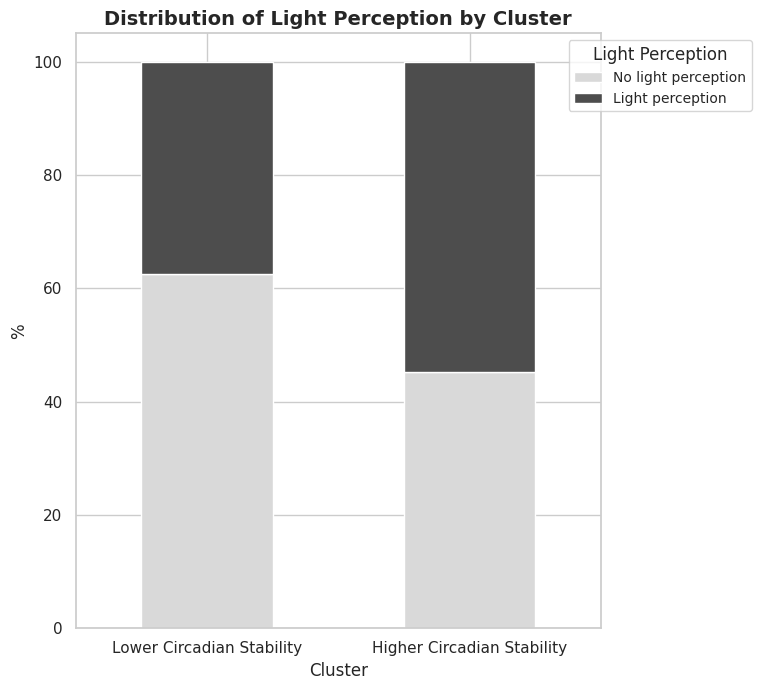


📌 Outlier summary:
Participant  N_outliers                                                                                                                                                                                                               Variables
   P01F45R0           2                                                                                                                                                                      PeriodTemperature, SB_period_EXT TEMPERATURE (min)
   P03M37N0           2                                                                                                                                                                                                                 IV, kAR
   P05M48R0           3                                                                                                                                                                       M10olight, PeriodLight, SB_period_AMB LIGHT (min)
   P06F42N1         

In [9]:
# =============================================================================
# COMPARE CLUSTERS
# =============================================================================
def compare_clusters(
    df,
    shap_df=None,
    cluster_column=CLUSTER_COLUMN_HEADER,
    participant_column=PARTICIPANT_COLUMN_HEADER,
    output_path=None,
    save_plot_dir=None
):
    """
    Compare clusters across numerical and binary variables.
    """

    CLUSTER_COLORS_LOCAL = {0: '#e8857e', 1: '#028a8a'}
    GROUP_MARKERS = {1: 'o', 0: '^'}
    CLUSTER_LABELS_LOCAL = {0: 'Lower Circadian Stability', 1: 'Higher Circadian Stability'}

    binary_vars = {'PLR', 'Diabetes status', 'Sex', 'Light Perception'}
    binary_legends = {
        'Diabetes status': {0: 'No diabetes', 1: 'Diabetes'},
        'Sex': {1: 'Female', 2: 'Male'},
        'PLR': {0: 'No reactivity', 1: 'Reactivity'},
        'Light Perception': {0: 'No light perception', 1: 'Light perception'}
    }

    df = df.copy()
    df[cluster_column] = df[cluster_column].astype(int)

    if save_plot_dir is not None:
        os.makedirs(save_plot_dir, exist_ok=True)

    results = []
    plots = []
    outlier_tracker = []

    # -------------------------------------------------------------------------
    # Variables to test
    # -------------------------------------------------------------------------
    if shap_df is not None:
        vars_to_test = [v for v in shap_df['Feature'].tolist() if v in df.columns]
    else:
        vars_to_test = df.select_dtypes(include=[np.number]).columns.drop(cluster_column).tolist()

    # -------------------------------------------------------------------------
    # Statistical tests
    # -------------------------------------------------------------------------
    for var in vars_to_test:
        if var not in df.columns:
            continue

        if var in binary_vars:
            cont_table = pd.crosstab(df[var], df[cluster_column])
            stat, p, _, _ = chi2_contingency(cont_table)
            effect_size = np.nan
            test = "Chi-squared"

        else:
            groups = [g[var].dropna().values for _, g in df.groupby(cluster_column)]

            import scipy.stats as stats

            normal = all(stats.shapiro(g)[1] > 0.05 for g in groups if len(g) >= 3)
            homoced = stats.levene(*groups)[1] > 0.05

            if len(groups) == 2:
                if normal and homoced:
                    stat, p = stats.ttest_ind(*groups)
                    pooled_sd = np.sqrt(
                        (
                            np.std(groups[0], ddof=1) ** 2 +
                            np.std(groups[1], ddof=1) ** 2
                        ) / 2
                    )
                    effect_size = (
                        np.abs(np.mean(groups[0]) - np.mean(groups[1])) / pooled_sd
                        if pooled_sd > 0 else np.nan
                    )
                    test = "t-test"
                else:
                    stat, p = stats.mannwhitneyu(*groups)
                    n1, n2 = len(groups[0]), len(groups[1])
                    effect_size = abs(stat - (n1 * n2 / 2)) / np.sqrt(
                        n1 * n2 * (n1 + n2 + 1) / 12
                    )
                    test = "Mann-Whitney"
            else:
                stat, p = stats.f_oneway(*groups) if (normal and homoced) else stats.kruskal(*groups)
                effect_size = np.nan
                test = "ANOVA" if (normal and homoced) else "Kruskal-Wallis"

        cluster_stats = (
            df.groupby(cluster_column)[var]
            .agg(['mean', 'median', 'std', 'min', 'max'])
            .reset_index()
        )
        cluster_stats.columns = [cluster_column, 'Mean', 'Median', 'SD', 'Min', 'Max']

        result_entry = {
            'Variable': var,
            'Test': test,
            'Statistic': stat,
            'Effect size': effect_size,
            'p-value': p,
            'Mean Cluster 0': cluster_stats.loc[cluster_stats[cluster_column] == 0, 'Mean'].values[0]
                if 0 in cluster_stats[cluster_column].values else np.nan,
            'Mean Cluster 1': cluster_stats.loc[cluster_stats[cluster_column] == 1, 'Mean'].values[0]
                if 1 in cluster_stats[cluster_column].values else np.nan,
            'Median Cluster 0': cluster_stats.loc[cluster_stats[cluster_column] == 0, 'Median'].values[0]
                if 0 in cluster_stats[cluster_column].values else np.nan,
            'Median Cluster 1': cluster_stats.loc[cluster_stats[cluster_column] == 1, 'Median'].values[0]
                if 1 in cluster_stats[cluster_column].values else np.nan,
            'SD Cluster 0': cluster_stats.loc[cluster_stats[cluster_column] == 0, 'SD'].values[0]
                if 0 in cluster_stats[cluster_column].values else np.nan,
            'SD Cluster 1': cluster_stats.loc[cluster_stats[cluster_column] == 1, 'SD'].values[0]
                if 1 in cluster_stats[cluster_column].values else np.nan,
            'Min Cluster 0': cluster_stats.loc[cluster_stats[cluster_column] == 0, 'Min'].values[0]
                if 0 in cluster_stats[cluster_column].values else np.nan,
            'Min Cluster 1': cluster_stats.loc[cluster_stats[cluster_column] == 1, 'Min'].values[0]
                if 1 in cluster_stats[cluster_column].values else np.nan,
            'Max Cluster 0': cluster_stats.loc[cluster_stats[cluster_column] == 0, 'Max'].values[0]
                if 0 in cluster_stats[cluster_column].values else np.nan,
            'Max Cluster 1': cluster_stats.loc[cluster_stats[cluster_column] == 1, 'Max'].values[0]
                if 1 in cluster_stats[cluster_column].values else np.nan,
        }

        results.append(result_entry)
        plots.append(var)

    results_df = pd.DataFrame(results).sort_values('p-value')
    _, pvals_fdr = fdrcorrection(results_df['p-value'], alpha=0.05)
    results_df['p-value (FDR)'] = pvals_fdr
    results_df['Significant (FDR)'] = ['✅' if p < 0.05 else '❌' for p in pvals_fdr]

    # -------------------------------------------------------------------------
    # Formatted display version
    # -------------------------------------------------------------------------
    results_df_display = results_df.copy()

    numeric_cols = results_df_display.select_dtypes(include=[np.number]).columns
    results_df_display[numeric_cols] = results_df_display[numeric_cols].round(2)

    if 'p-value' in results_df_display.columns:
        results_df_display['p-value'] = results_df_display['p-value'].round(3)

    if 'p-value (FDR)' in results_df_display.columns:
        results_df_display['p-value (FDR)'] = results_df_display['p-value (FDR)'].round(3)

    if output_path is not None:
        results_df_display.to_csv(output_path, index=False)

    display(results_df_display)

    # -------------------------------------------------------------------------
    # Plots: continuous variables
    # -------------------------------------------------------------------------
    n_per_figure = 2

    for i in range(0, len(plots), n_per_figure):
        subset = plots[i:i + n_per_figure]
        fig, axes = plt.subplots(1, len(subset), figsize=(6 * len(subset), 5))
        axes = [axes] if len(subset) == 1 else axes

        for ax, var in zip(axes, subset):
            if var in binary_vars or var not in df.columns:
                continue

            required_cols = [var, cluster_column, 'PLR', participant_column]
            missing_required = [c for c in required_cols if c not in df.columns]
            if missing_required:
                print(f"⚠️ Skipping plot for '{var}' because columns are missing: {missing_required}")
                continue

            df_plot = df[required_cols].dropna().copy()
            df_plot[cluster_column] = df_plot[cluster_column].astype(int)
            pos = sorted(df_plot[cluster_column].unique())

            vals = [df_plot.loc[df_plot[cluster_column] == c, var].values for c in pos]

            v = ax.violinplot(
                vals,
                positions=pos,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )
            for j, body in enumerate(v['bodies']):
                cluster_value = pos[j]
                body.set_facecolor(CLUSTER_COLORS_LOCAL[cluster_value])
                body.set_alpha(0.35)

            b = ax.boxplot(vals, positions=pos, widths=0.18, patch_artist=True, zorder=3)
            for patch in b['boxes']:
                patch.set_facecolor("white")
                patch.set_edgecolor("black")
                patch.set_linewidth(1.5)

            for element in ['whiskers', 'caps', 'medians']:
                for line in b[element]:
                    line.set_color("black")
                    line.set_linewidth(1.5)

            jitter = 0.06
            for c in pos:
                sub = df_plot[df_plot[cluster_column] == c]
                for _, row in sub.iterrows():
                    x = c + np.random.normal(0, jitter)
                    marker_style = GROUP_MARKERS.get(row['PLR'], 'o')
                    ax.plot(
                        x,
                        row[var],
                        marker=marker_style,
                        color=CLUSTER_COLORS_LOCAL[c],
                        alpha=0.7,
                        markersize=6,
                        markeredgecolor="black",
                        zorder=5
                    )

            for c in pos:
                group = df_plot[df_plot[cluster_column] == c][[var, participant_column]]
                q1, q3 = group[var].quantile([0.25, 0.75])
                iqr = q3 - q1
                lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
                outliers = group[(group[var] < lower) | (group[var] > upper)]

                for _, row in outliers.iterrows():
                    ax.text(
                        c,
                        row[var],
                        str(row[participant_column]),
                        color='black',
                        fontsize=9,
                        ha='center',
                        va='bottom'
                    )
                    outlier_tracker.append({
                        participant_column: row[participant_column],
                        'Variable': var
                    })

            ax.set_title(var)
            ax.set_xticks(pos)
            ax.set_xticklabels([CLUSTER_LABELS_LOCAL[c] for c in pos])
            ax.grid(False)

            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)

            p_fdr = results_df.loc[results_df['Variable'] == var, 'p-value (FDR)'].values[0]
            if p_fdr < 0.05:
                ymin, ymax = ax.get_ylim()
                ysig = ymax + 0.05 * (ymax - ymin)
                ax.plot(pos, [ysig, ysig], color="black", linewidth=1.5)
                ax.text(np.mean(pos), ysig + 0.01, "*", ha="center", fontsize=18)

        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # Plots: binary variables
    # -------------------------------------------------------------------------
    for var in binary_vars:
        if var not in df.columns:
            continue

        ct = pd.crosstab(df[cluster_column], df[var], normalize='index') * 100
        legend = binary_legends.get(var, {})
        ct.rename(columns=legend, inplace=True)

        ct.plot(
            kind='bar',
            stacked=True,
            color=['#d9d9d9', '#4d4d4d'],
            figsize=(8, 7)
        )
        plt.title(f'Distribution of {var} by Cluster')
        plt.ylabel('%')
        plt.xticks(
            ticks=[0, 1],
            labels=[CLUSTER_LABELS_LOCAL[0], CLUSTER_LABELS_LOCAL[1]],
            rotation=0
        )
        plt.legend(title=var, loc='upper right', bbox_to_anchor=(1.3, 1))
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # Outlier summary
    # -------------------------------------------------------------------------
    outlier_df = pd.DataFrame(outlier_tracker)

    if not outlier_df.empty and save_plot_dir is not None:
        outlier_summary = (
            outlier_df.groupby(participant_column)['Variable']
            .agg(['count', lambda x: ', '.join(sorted(set(x)))])
            .reset_index()
        )
        outlier_summary.columns = [participant_column, 'N_outliers', 'Variables']
        outlier_summary.to_csv(os.path.join(save_plot_dir, "outliers_summary.csv"), index=False)

        print("\n📌 Outlier summary:")
        print(outlier_summary.to_string(index=False))

    return results_df


# =============================================================================
# RUN COMPARATIVE CLUSTER ANALYSIS
# =============================================================================
dataframe_clusters = pd.read_csv(TABLE_CLUSTER_PATH)

shap_df_path = os.path.join(DATA_OUTPUT_PATH, "shap_importance.csv")
output_stats_path = os.path.join(DATA_OUTPUT_PATH, "cluster_stats_results.csv")
plot_output_dir = os.path.join(DATA_OUTPUT_PATH, "cluster_Comparisons")

# Optional:
# shap_df = pd.read_csv(shap_df_path)
shap_df = None

results_df = compare_clusters(
    df=dataframe_clusters,
    shap_df=shap_df,
    cluster_column=CLUSTER_COLUMN_HEADER,
    participant_column=PARTICIPANT_COLUMN_HEADER,
    output_path=output_stats_path,
    save_plot_dir=plot_output_dir
)

#Cluster Comparison & Regression Pipeline

This pipeline evaluates differences between clusters using both group comparisons
and regression models for each numerical or binary variable in the dataset.




In [10]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def cohen_d(group1, group2):
    diff = np.mean(group1) - np.mean(group2)
    pooled_sd = np.sqrt(
        ((np.std(group1, ddof=1) ** 2) + (np.std(group2, ddof=1) ** 2)) / 2
    )
    return diff / pooled_sd if pooled_sd != 0 else np.nan


def eta_squared_from_t(t_stat, df):
    return (t_stat ** 2) / (t_stat ** 2 + df) if df != 0 else np.nan


def is_binary(series):
    return series.dropna().nunique() == 2


# =============================================================================
# PATHS
# =============================================================================
TABLE_CLUSTER_PATH = os.path.join(DATA_OUTPUT_PATH, "All_data_cleaned_with_clusters.csv")

output_dir = os.path.join(DATA_OUTPUT_PATH, "exploratory_cluster_analysis")
output_file = os.path.join(output_dir, "exploratory_cluster_analysis.csv")

os.makedirs(output_dir, exist_ok=True)


# =============================================================================
# LOAD DATA
# =============================================================================
dataframe_source = pd.read_csv(TABLE_CLUSTER_PATH)
numeric_vars = dataframe_source.select_dtypes(include=[np.number]).columns.drop(CLUSTER_COLUMN_HEADER)


# =============================================================================
# INITIALIZE LISTS
# =============================================================================
results = []
p_values_group = []
p_values_regression = []


# =============================================================================
# MAIN LOOP
# =============================================================================
for var in numeric_vars:
    y_raw = dataframe_source[var]
    x_raw = dataframe_source[[CLUSTER_COLUMN_HEADER]]

    # -------------------------------------------------------------------------
    # Recode binary outcomes if necessary
    # -------------------------------------------------------------------------
    if is_binary(y_raw):
        y_nonan = y_raw.dropna()
        unique_vals = y_nonan.unique()

        if set(unique_vals) == {0, 1}:
            y = y_raw
        else:
            sorted_vals = np.sort(unique_vals)
            mapping = {sorted_vals[0]: 0, sorted_vals[1]: 1}
            y = y_raw.replace(mapping)
    else:
        y = y_raw

    x = sm.add_constant(x_raw)
    binary_var = is_binary(y)

    # -------------------------------------------------------------------------
    # BINARY VARIABLES
    # -------------------------------------------------------------------------
    if binary_var:
        contingency = pd.crosstab(dataframe_source[CLUSTER_COLUMN_HEADER], y)

        try:
            stat_test, p_value = fisher_exact(contingency)
            test_name = "Fisher"
        except:
            stat_test, p_value, _, _ = chi2_contingency(contingency)
            test_name = "Chi²"

        p_values_group.append(p_value)
        effect_size = np.nan
        eta_sq_group = np.nan

        try:
            logit_model = sm.Logit(y, x, missing='drop')
            logit_results = logit_model.fit(disp=0, cov_type='HC3')

            coef = logit_results.params[CLUSTER_COLUMN_HEADER]
            std_beta = np.nan
            odds_ratio = np.exp(coef)
            p_reg = logit_results.pvalues[CLUSTER_COLUMN_HEADER]
            t_val = logit_results.tvalues[CLUSTER_COLUMN_HEADER]
            r2 = logit_results.prsquared
            eta_sq_reg = np.nan
            p_resid = np.nan
            reg_method = "Logistic (robust)"

            p_values_regression.append(p_reg)

        except:
            coef = np.nan
            std_beta = np.nan
            odds_ratio = np.nan
            p_reg = np.nan
            t_val = np.nan
            r2 = np.nan
            eta_sq_reg = np.nan
            p_resid = np.nan
            reg_method = "Logistic (failed)"
            p_values_regression.append(np.nan)

    # -------------------------------------------------------------------------
    # CONTINUOUS VARIABLES
    # -------------------------------------------------------------------------
    else:
        group0 = dataframe_source[dataframe_source[CLUSTER_COLUMN_HEADER] == 0][var].dropna()
        group1 = dataframe_source[dataframe_source[CLUSTER_COLUMN_HEADER] == 1][var].dropna()

        p_shapiro0 = shapiro(group0)[1] if len(group0) >= 3 else np.nan
        p_shapiro1 = shapiro(group1)[1] if len(group1) >= 3 else np.nan
        normal = (p_shapiro0 > 0.05) and (p_shapiro1 > 0.05)

        p_levene = levene(group0, group1)[1] if len(group0) > 1 and len(group1) > 1 else np.nan
        equal_var = p_levene > 0.05 if not np.isnan(p_levene) else False

        if normal and equal_var:
            stat_test, p_value = ttest_ind(group0, group1, equal_var=True)
            df_test = len(group0) + len(group1) - 2
            effect_size = cohen_d(group0, group1)
            eta_sq_group = eta_squared_from_t(stat_test, df_test)
            test_name = "t-test"
        else:
            stat_test, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
            z_stat, _ = ranksums(group0, group1)
            effect_size = z_stat / np.sqrt(len(group0) + len(group1))
            eta_sq_group = np.nan
            test_name = "Mann-Whitney"

        p_values_group.append(p_value)

        model = sm.OLS(y, x, missing='drop')
        results_ols = model.fit(cov_type='HC3')

        coef = results_ols.params[CLUSTER_COLUMN_HEADER]
        t_val = results_ols.tvalues[CLUSTER_COLUMN_HEADER]
        p_reg = results_ols.pvalues[CLUSTER_COLUMN_HEADER]
        r2 = results_ols.rsquared
        eta_sq_reg = eta_squared_from_t(t_val, results_ols.df_resid) if normal else np.nan

        residuals = results_ols.resid
        p_resid = shapiro(residuals)[1] if len(residuals) >= 3 else np.nan
        reg_method = "Linear" if normal else "Linear Robust (HC3)"

        p_values_regression.append(p_reg)

        df_std = dataframe_source[[CLUSTER_COLUMN_HEADER, var]].dropna()
        if df_std[CLUSTER_COLUMN_HEADER].nunique() > 1:
            scaler = StandardScaler()
            X_std = scaler.fit_transform(df_std[[CLUSTER_COLUMN_HEADER]])
            y_std = scaler.fit_transform(df_std[[var]])
            model_std = sm.OLS(y_std, sm.add_constant(X_std)).fit(cov_type='HC3')
            std_beta = model_std.params[1]
        else:
            std_beta = np.nan

        odds_ratio = np.nan

    # -------------------------------------------------------------------------
    # SAVE RESULTS
    # -------------------------------------------------------------------------
    results.append({
        'Variable': var,
        'Group Test': test_name,
        'Group Comparison p': p_value,
        'Effect size (group)': effect_size,
        'Eta² (group)': eta_sq_group,
        'Cluster Coef.': coef,
        'Standardized β': std_beta,
        'Odds Ratio': odds_ratio,
        't (regression)': t_val,
        'p (regression)': p_reg,
        'Eta² (regression)': eta_sq_reg,
        'R² / Pseudo-R²': r2,
        'Residuals Shapiro p': p_resid,
        'Regression Method': reg_method
    })


# =============================================================================
# FINAL RESULTS DATAFRAME
# =============================================================================
df_results = pd.DataFrame(results)

if len(p_values_group) > 0:
    valid_group = [p if not pd.isna(p) else 1.0 for p in p_values_group]
    _, fdr_group, _, _ = multipletests(valid_group, method='fdr_bh')
else:
    fdr_group = [np.nan] * len(results)

if len(p_values_regression) > 0:
    valid_reg = [p if not pd.isna(p) else 1.0 for p in p_values_regression]
    _, fdr_reg, _, _ = multipletests(valid_reg, method='fdr_bh')
else:
    fdr_reg = [np.nan] * len(results)

df_results['FDR (group)'] = fdr_group
df_results['FDR (regression)'] = fdr_reg
df_results['Significant (group)'] = df_results['FDR (group)'] < 0.05
df_results['Significant (regression)'] = df_results['FDR (regression)'] < 0.05


# =============================================================================
# SORT
# =============================================================================
sort_cols = ['FDR (regression)', 'FDR (group)']
df_results.sort_values(by=sort_cols, inplace=True, na_position='last')


# =============================================================================
# FORMATTED VERSION FOR DISPLAY / EXPORT
# =============================================================================
df_display = df_results.copy()

numeric_cols = df_display.select_dtypes(include=[np.number]).columns
df_display[numeric_cols] = df_display[numeric_cols].round(2)

for col in ['Group Comparison p', 'p (regression)', 'FDR (group)', 'FDR (regression)', 'Residuals Shapiro p']:
    if col in df_display.columns:
        df_display[col] = df_display[col].round(3)


# =============================================================================
# SAVE AND DISPLAY
# =============================================================================
df_display.to_csv(output_file, index=False)

pd.set_option('display.max_rows', None)
display(df_display)

,Variable,Group Test,Group Comparison p,Effect size (group),Eta² (group),Cluster Coef.,Standardized β,Odds Ratio,t (regression),p (regression),Eta² (regression),R² / Pseudo-R²,Residuals Shapiro p,Regression Method,FDR (group),FDR (regression),Significant (group),Significant (regression)
9,IS,Mann-Whitney,0.00,-0.74,NaN,0.24,0.74,NaN,9.52,0.00,0.62,0.54,0.26,Linear,0.00,0.00,True,True
26,QPActivity,Mann-Whitney,0.00,-0.70,NaN,7.84,0.69,NaN,8.77,0.00,0.58,0.48,0.94,Linear,0.00,0.00,True,True
6,RA,t-test,0.00,-2.54,0.61,0.23,0.78,NaN,7.85,0.00,0.52,0.61,0.05,Linear,0.00,0.00,True,True
10,ISm,t-test,0.00,-1.75,0.38,0.21,0.62,NaN,5.88,0.00,0.38,0.38,0.88,Linear,0.00,0.00,True,True
22,LRI,t-test,0.00,-1.58,0.34,17.19,0.58,NaN,5.23,0.00,0.33,0.34,0.90,Linear,0.00,0.00,True,True
13,L5,Mann-Whitney,0.00,0.59,NaN,-344.01,-0.63,NaN,-4.53,0.00,NaN,0.40,0.01,Linear Robust (HC3),0.00,0.00,True,True
12,M10o,t-test,0.00,1.12,0.24,-156.37,-0.49,NaN,-3.42,0.00,0.17,0.24,0.62,Linear,0.00,0.00,True,True
30,QPTemperature,t-test,0.01,-0.90,0.13,7.03,0.36,NaN,3.19,0.00,0.15,0.13,0.27,Linear,0.02,0.01,True,True
23,M10olight,Mann-Whitney,0.00,0.47,NaN,-61.60,-0.46,NaN,-2.68,0.01,NaN,0.22,0.00,Linear Robust (HC3),0.00,0.03,True,True
19,FSoD,Mann-Whitney,0.01,0.35,NaN,-0.09,-0.41,NaN,-2.69,0.01,NaN,0.16,0.01,Linear Robust (HC3),0.03,0.03,True,True


In [16]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence
from IPython.display import display


# =============================================================================
# GLOBAL CONFIG
# =============================================================================

# Regression result columns (English)
RESULT_COLUMNS = [
    'Variable',
    'Binary',
    'Coef',
    'Standardized β',
    'Odds Ratio',
    'Regression statistic',
    'p-value (raw)',
    'p-value (FDR)',
    'Eta²',
    'R² / Pseudo-R²',
    'Residuals Shapiro p',
    'Breusch-Pagan p',
    'Max Cook Distance',
    'Assumptions met',
    'Regression Method'
]


def get_selected_variables():
    return [
        'SRI', 'SleepMidpoint', 'RA', 'IV', 'IS', 'M10', 'M10o', 'L5', 'L5o',
        'ADAT', 'CoG', 'FSoD', 'kRA', 'kAR', 'LRI', 'M10olight', 'L5olight',
        'PeriodActivity', 'QPActivity', 'PeriodLight', 'QPLight',
        'PeriodTemperature', 'QPTemperature', 'Sex', 'Age', 'PLR',
        'Diabetes status'
    ]


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def eta_squared_from_t(t_stat, df_resid):
    """
    Compute eta-squared from t statistic and residual degrees of freedom.
    """
    return (t_stat ** 2) / (t_stat ** 2 + df_resid) if df_resid != 0 else np.nan


def is_binary(series):
    """
    Check whether a variable has exactly 2 unique non-missing values.
    """
    return series.dropna().nunique() == 2


def recode_binary_if_needed(series):
    """
    Recode binary variable to 0/1 if needed.
    If already 0/1, keep as is.
    """
    s = series.copy()
    nonan = s.dropna()

    if nonan.nunique() != 2:
        return s

    unique_vals = sorted(nonan.unique())
    if set(unique_vals) == {0, 1}:
        return s

    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    return s.replace(mapping)


def format_p_value(p):
    """
    Format p-values for display.
    """
    if pd.isnull(p):
        return np.nan
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def get_analysis_variables(df, predictor_col):
    """
    Return selected variables present in the dataframe, excluding the predictor.
    """
    selected_vars = get_selected_variables()
    return [var for var in selected_vars if var in df.columns and var != predictor_col]


def build_result_row(var, is_bin, method, **kwargs):
    """
    Create a standardized result row with default NaNs,
    then overwrite fields passed in kwargs.
    """
    row = {col: np.nan for col in RESULT_COLUMNS}
    row['Variable'] = var
    row['Binary'] = is_bin
    row['Regression Method'] = method
    row.update(kwargs)
    return row


def prepare_model_data(df, outcome_col, predictor_col):
    """
    Build a clean dataframe with outcome and predictor, removing missing values.
    """
    return pd.concat(
        [df[outcome_col].rename(outcome_col), df[[predictor_col]]],
        axis=1
    ).dropna()


def fit_standardized_model(data_model, outcome_col, predictor_col, use_robust):
    """
    Fit a standardized version of the regression to obtain standardized beta.
    """
    try:
        scaler = StandardScaler()
        X_std = scaler.fit_transform(data_model[[predictor_col]])
        y_std = scaler.fit_transform(data_model[[outcome_col]])
        X_std = sm.add_constant(X_std)

        if use_robust:
            std_results = sm.OLS(y_std, X_std).fit(cov_type='HC3')
        else:
            std_results = sm.OLS(y_std, X_std).fit()

        return std_results.params[1]
    except Exception:
        return np.nan


# =============================================================================
# MODEL-SPECIFIC FUNCTIONS
# =============================================================================
def run_logistic_regression(data_model, outcome_col, predictor_col):
    """
    Fit logistic regression for binary outcomes.
    """
    X = sm.add_constant(data_model[[predictor_col]])
    y = data_model[outcome_col]

    try:
        model = sm.Logit(y, X)
        results = model.fit(disp=0)

        coef = results.params[predictor_col]
        odds_ratio = np.exp(coef)
        p_raw = results.pvalues[predictor_col]

        if hasattr(results, 'tvalues'):
            stat_value = results.tvalues[predictor_col]
        else:
            stat_value = results.params[predictor_col] / results.bse[predictor_col]

        return build_result_row(
            var=outcome_col,
            is_bin=True,
            method='Logistic',
            **{
                'Coef': coef,
                'Odds Ratio': odds_ratio,
                'Regression statistic': stat_value,
                'p-value (raw)': p_raw,
                'R² / Pseudo-R²': results.prsquared
            }
        )

    except Exception:
        return build_result_row(
            var=outcome_col,
            is_bin=True,
            method='Logistic (failed)'
        )


def run_continuous_regression(data_model, outcome_col, predictor_col):
    """
    Fit baseline OLS, test residual assumptions, then choose:
    - Linear
    - Linear Robust (HC3)
    """
    X = sm.add_constant(data_model[[predictor_col]])
    y = data_model[outcome_col]

    # -------------------------------------------------------------------------
    # STEP 1: BASELINE OLS
    # -------------------------------------------------------------------------
    base_model = sm.OLS(y, X)
    ols_results = base_model.fit()
    residuals = ols_results.resid

    # -------------------------------------------------------------------------
    # STEP 2: ASSUMPTION TESTS
    # -------------------------------------------------------------------------
    p_resid = shapiro(residuals)[1] if len(residuals) >= 3 else np.nan

    try:
        p_bp = het_breuschpagan(residuals, X)[1]
    except Exception:
        p_bp = np.nan

    try:
        influence = OLSInfluence(ols_results)
        max_cook = np.max(influence.cooks_distance[0])
    except Exception:
        max_cook = np.nan

    normal_ok = (p_resid > 0.05) if not np.isnan(p_resid) else False
    homoced_ok = (p_bp > 0.05) if not np.isnan(p_bp) else False
    assumptions_ok = normal_ok and homoced_ok

    # -------------------------------------------------------------------------
    # STEP 3: FINAL MODEL CHOICE
    # -------------------------------------------------------------------------
    if assumptions_ok:
        final_results = ols_results
        reg_method = 'Linear'
        use_robust = False
    else:
        final_results = base_model.fit(cov_type='HC3')
        reg_method = 'Linear Robust (HC3)'
        use_robust = True

    # -------------------------------------------------------------------------
    # STEP 4: EXTRACT RESULTS
    # -------------------------------------------------------------------------
    coef = final_results.params[predictor_col]
    stat_value = final_results.tvalues[predictor_col]
    p_raw = final_results.pvalues[predictor_col]
    r2 = final_results.rsquared
    eta_sq = eta_squared_from_t(stat_value, final_results.df_resid)

    std_beta = fit_standardized_model(
        data_model=data_model,
        outcome_col=outcome_col,
        predictor_col=predictor_col,
        use_robust=use_robust
    )

    return build_result_row(
        var=outcome_col,
        is_bin=False,
        method=reg_method,
        **{
            'Coef': coef,
            'Standardized β': std_beta,
            'Regression statistic': stat_value,
            'p-value (raw)': p_raw,
            'Eta²': eta_sq,
            'R² / Pseudo-R²': r2,
            'Residuals Shapiro p': p_resid,
            'Breusch-Pagan p': p_bp,
            'Max Cook Distance': max_cook,
            'Assumptions met': assumptions_ok
        }
    )


# =============================================================================
# POST-PROCESSING FUNCTIONS
# =============================================================================
def apply_fdr_correction(results_df):
    """
    Apply Benjamini-Hochberg FDR correction to raw p-values.
    """
    results_df = results_df.copy()

    valid_mask = results_df['p-value (raw)'].notna()
    fdr_values = np.full(len(results_df), np.nan)

    if valid_mask.sum() > 0:
        _, corrected_pvals, _, _ = multipletests(
            results_df.loc[valid_mask, 'p-value (raw)'],
            method='fdr_bh'
        )
        fdr_values[valid_mask] = corrected_pvals

    results_df['p-value (FDR)'] = fdr_values
    results_df['Significant (FDR)'] = results_df['p-value (FDR)'].apply(
        lambda x: '✅' if pd.notnull(x) and x < 0.05 else '❌'
    )

    return results_df


def format_results_for_display(results_df):
    """
    Format output table for notebook display.
    """
    results_display = results_df.copy()

    results_display['p-value (raw)'] = results_display['p-value (raw)'].apply(format_p_value)
    results_display['p-value (FDR)'] = results_display['p-value (FDR)'].apply(format_p_value)

    numeric_cols = results_display.select_dtypes(include=[np.number]).columns
    cols_to_round = [
        col for col in numeric_cols
        if col not in ['p-value (raw)', 'p-value (FDR)']
    ]
    results_display[cols_to_round] = results_display[cols_to_round].round(2)

    preferred_order = RESULT_COLUMNS + ['Significant (FDR)']
    existing_cols = [col for col in preferred_order if col in results_display.columns]
    remaining_cols = [col for col in results_display.columns if col not in existing_cols]

    return results_display[existing_cols + remaining_cols]


# =============================================================================
# MAIN PIPELINE
# =============================================================================
def run_regression_pipeline(
    df,
    predictor_col,
    output_path=None
):
    """
    Generic regression pipeline for a given predictor.
    Works for Cluster, PLR, or any other binary predictor.
    """
    df = df.copy()
    df[predictor_col] = df[predictor_col].astype(int)

    variables = get_analysis_variables(df, predictor_col)

    print(f"Variables included in regression analysis ({len(variables)}):")
    print(variables)

    results = []

    for var in variables:
        y_raw = df[var].copy()

        if is_binary(y_raw):
            y_prepared = recode_binary_if_needed(y_raw)
        else:
            y_prepared = y_raw

        data_model = pd.concat(
            [y_prepared.rename(var), df[[predictor_col]]],
            axis=1
        ).dropna()

        if data_model.empty or data_model[predictor_col].nunique() < 2:
            method = 'Logistic (not computable)' if is_binary(y_raw) else 'Linear (not computable)'
            results.append(build_result_row(var=var, is_bin=is_binary(y_raw), method=method))
            continue

        if is_binary(y_raw):
            if data_model[var].nunique() < 2:
                results.append(build_result_row(var=var, is_bin=True, method='Logistic (not computable)'))
            else:
                results.append(
                    run_logistic_regression(
                        data_model=data_model,
                        outcome_col=var,
                        predictor_col=predictor_col
                    )
                )
        else:
            results.append(
                run_continuous_regression(
                    data_model=data_model,
                    outcome_col=var,
                    predictor_col=predictor_col
                )
            )

    results_df = pd.DataFrame(results)
    results_df = apply_fdr_correction(results_df)

    results_df = results_df.sort_values(
        by=['p-value (FDR)', 'p-value (raw)'],
        na_position='last'
    ).reset_index(drop=True)

    if output_path is not None:
        results_df.to_csv(output_path, index=False)

    display(format_results_for_display(results_df))
    return results_df


# =============================================================================
# PATHS
# =============================================================================
file_path = TABLE_CLUSTER_PATH
output_dir = DATA_OUTPUT_PATH
os.makedirs(output_dir, exist_ok=True)

cluster_output = os.path.join(output_dir, "selected_vars_regression_cluster_clean.csv")
plr_output = os.path.join(output_dir, "selected_vars_regression_plr_clean.csv")


# =============================================================================
# LOAD DATA
# =============================================================================
df = pd.read_csv(file_path)


# =============================================================================
# RUN: CLUSTER AS PREDICTOR
# =============================================================================
results_cluster = run_regression_pipeline(
    df=df,
    predictor_col='Cluster',
    output_path=cluster_output
)


# =============================================================================
# RUN: PLR AS PREDICTOR
# =============================================================================
results_plr = run_regression_pipeline(
    df=df,
    predictor_col='PLR',
    output_path=plr_output
)

Variables included in regression analysis (27):
['SRI', 'SleepMidpoint', 'RA', 'IV', 'IS', 'M10', 'M10o', 'L5', 'L5o', 'ADAT', 'CoG', 'FSoD', 'kRA', 'kAR', 'LRI', 'M10olight', 'L5olight', 'PeriodActivity', 'QPActivity', 'PeriodLight', 'QPLight', 'PeriodTemperature', 'QPTemperature', 'Sex', 'Age', 'PLR', 'Diabetes status']


,Variable,Binary,Coef,Standardized β,Odds Ratio,Regression statistic,p-value (raw),p-value (FDR),Eta²,R² / Pseudo-R²,Residuals Shapiro p,Breusch-Pagan p,Max Cook Distance,Assumptions met,Regression Method,Significant (FDR)
0,IS,False,0.24,0.74,NaN,9.52,<0.001,<0.001,0.62,0.54,0.26,0.03,0.07,False,Linear Robust (HC3),✅
1,QPActivity,False,7.84,0.69,NaN,8.77,<0.001,<0.001,0.58,0.48,0.94,0.04,0.08,False,Linear Robust (HC3),✅
2,RA,False,0.23,0.78,NaN,7.85,<0.001,<0.001,0.52,0.61,0.05,0.13,0.38,False,Linear Robust (HC3),✅
3,LRI,False,17.19,0.58,NaN,5.38,<0.001,<0.001,0.34,0.34,0.90,0.93,0.16,True,Linear,✅
4,L5,False,-344.01,-0.63,NaN,-4.53,<0.001,<0.001,0.27,0.40,0.01,0.01,0.49,False,Linear Robust (HC3),✅
5,M10o,False,-156.37,-0.49,NaN,-4.23,<0.001,<0.001,0.24,0.24,0.62,0.07,0.30,True,Linear,✅
6,QPTemperature,False,7.03,0.36,NaN,2.88,0.006,0.021,0.13,0.13,0.27,0.25,0.13,True,Linear,✅
7,FSoD,False,-0.09,-0.41,NaN,-2.69,0.007,0.021,0.11,0.16,0.01,0.02,0.15,False,Linear Robust (HC3),✅
8,M10olight,False,-61.60,-0.46,NaN,-2.68,0.007,0.021,0.11,0.22,0.00,0.02,0.76,False,Linear Robust (HC3),✅
9,L5olight,False,-35.22,-0.35,NaN,-2.77,0.008,0.021,0.12,0.12,0.29,0.16,0.19,True,Linear,✅


Variables included in regression analysis (26):
['SRI', 'SleepMidpoint', 'RA', 'IV', 'IS', 'M10', 'M10o', 'L5', 'L5o', 'ADAT', 'CoG', 'FSoD', 'kRA', 'kAR', 'LRI', 'M10olight', 'L5olight', 'PeriodActivity', 'QPActivity', 'PeriodLight', 'QPLight', 'PeriodTemperature', 'QPTemperature', 'Sex', 'Age', 'Diabetes status']


,Variable,Binary,Coef,Standardized β,Odds Ratio,Regression statistic,p-value (raw),p-value (FDR),Eta²,R² / Pseudo-R²,Residuals Shapiro p,Breusch-Pagan p,Max Cook Distance,Assumptions met,Regression Method,Significant (FDR)
0,RA,False,0.11,0.39,NaN,3.59,<0.001,0.009,0.19,0.15,0.16,0.03,0.16,False,Linear Robust (HC3),✅
1,L5,False,-169.94,-0.34,NaN,-3.05,0.002,0.030,0.14,0.11,0.00,0.07,0.22,False,Linear Robust (HC3),✅
2,FSoD,False,-0.06,-0.33,NaN,-2.71,0.007,0.059,0.12,0.11,0.00,0.26,0.19,False,Linear Robust (HC3),❌
3,IS,False,0.10,0.34,NaN,2.70,0.009,0.059,0.12,0.12,0.85,0.80,0.15,True,Linear,❌
4,LRI,False,8.48,0.31,NaN,2.46,0.017,0.076,0.10,0.10,0.26,0.52,0.10,True,Linear,❌
5,SRI,False,11.40,0.31,NaN,2.45,0.017,0.076,0.10,0.10,0.33,0.38,0.14,True,Linear,❌
6,PeriodActivity,False,-2.69,-0.20,NaN,-1.89,0.059,0.219,0.06,0.04,0.00,0.19,0.46,False,Linear Robust (HC3),❌
7,M10o,False,-52.83,-0.18,NaN,-1.58,0.114,0.352,0.04,0.03,0.58,0.01,0.15,False,Linear Robust (HC3),❌
8,L5olight,False,19.21,0.21,NaN,1.57,0.122,0.352,0.04,0.04,0.59,0.10,0.08,True,Linear,❌
9,QPActivity,False,1.98,0.19,NaN,1.45,0.154,0.365,0.04,0.04,0.12,0.54,0.10,True,Linear,❌


# Correlation between Circadian Variables – Summary

This pipeline computes and visualizes Spearman correlations between selected circadian metrics
within each cluster ("Higher" or "Lower Circadian Stability").





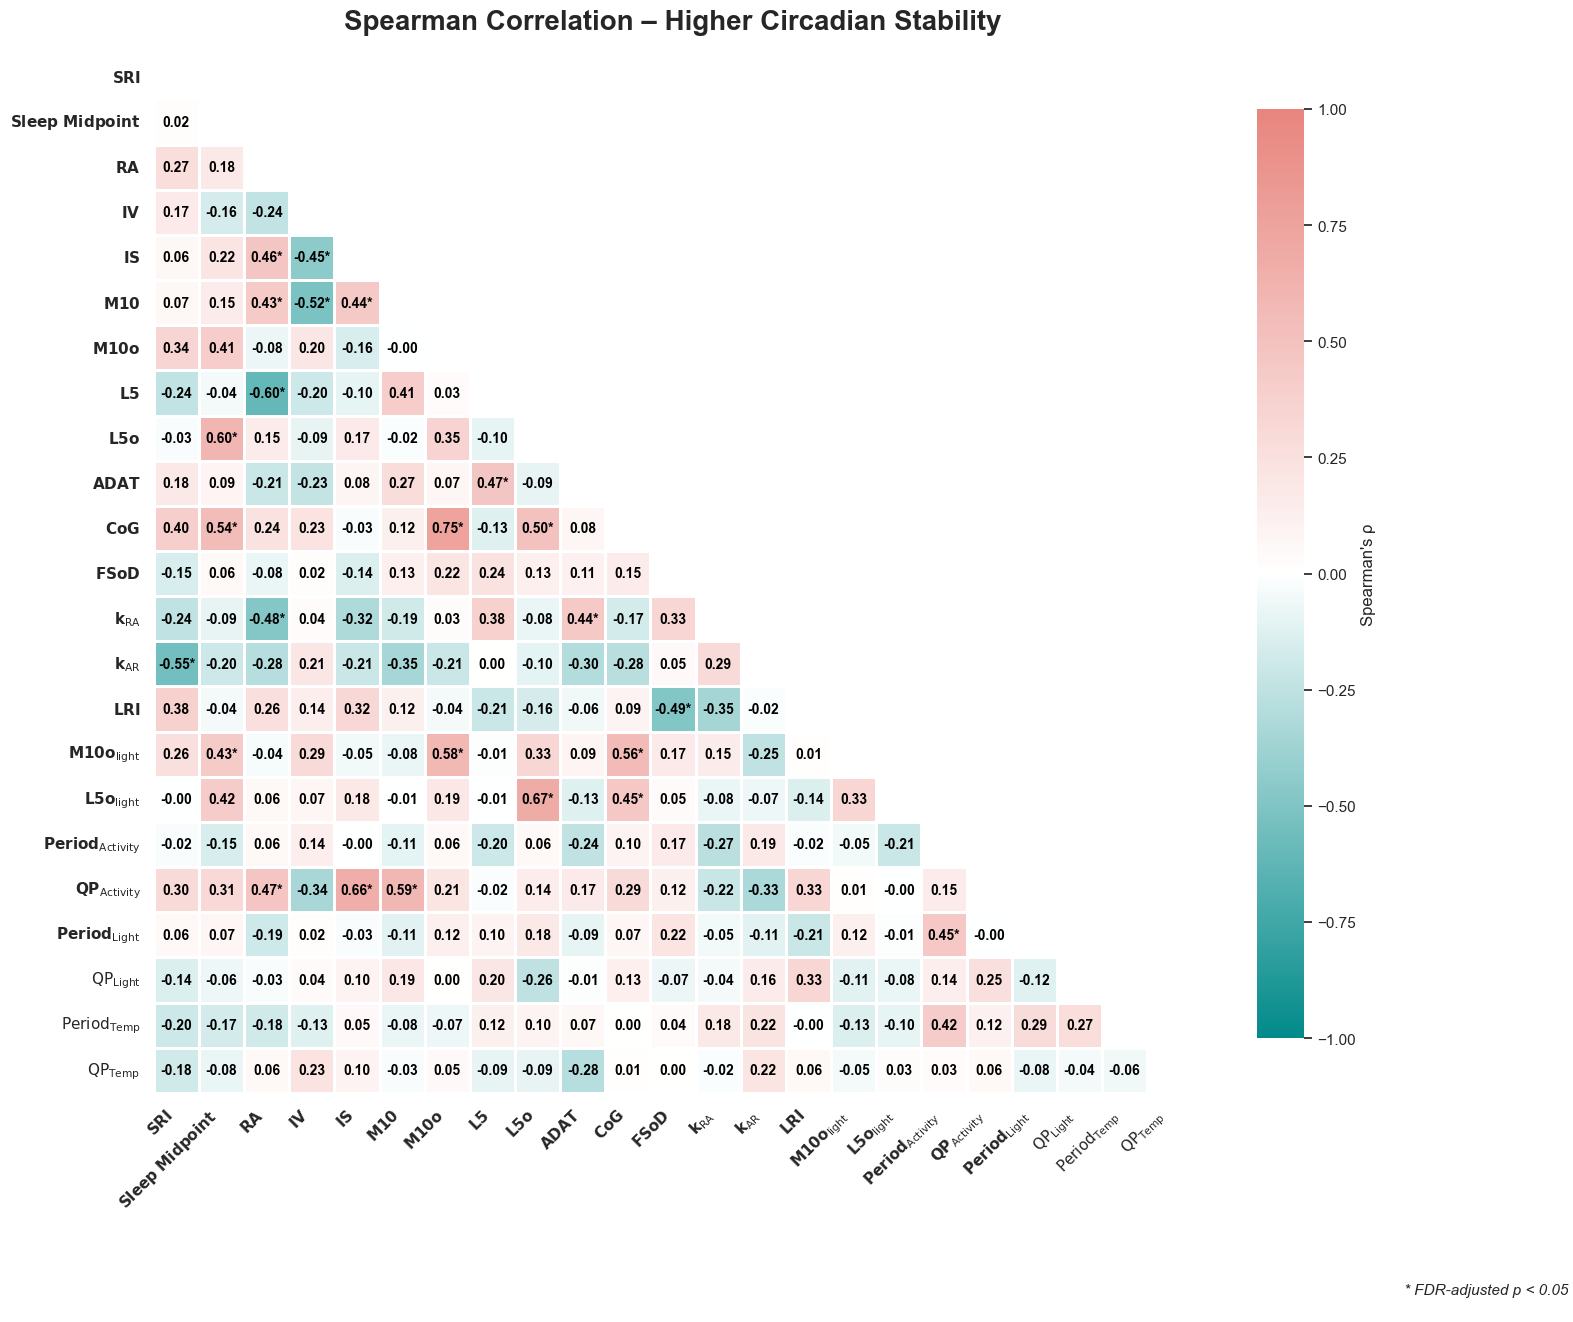

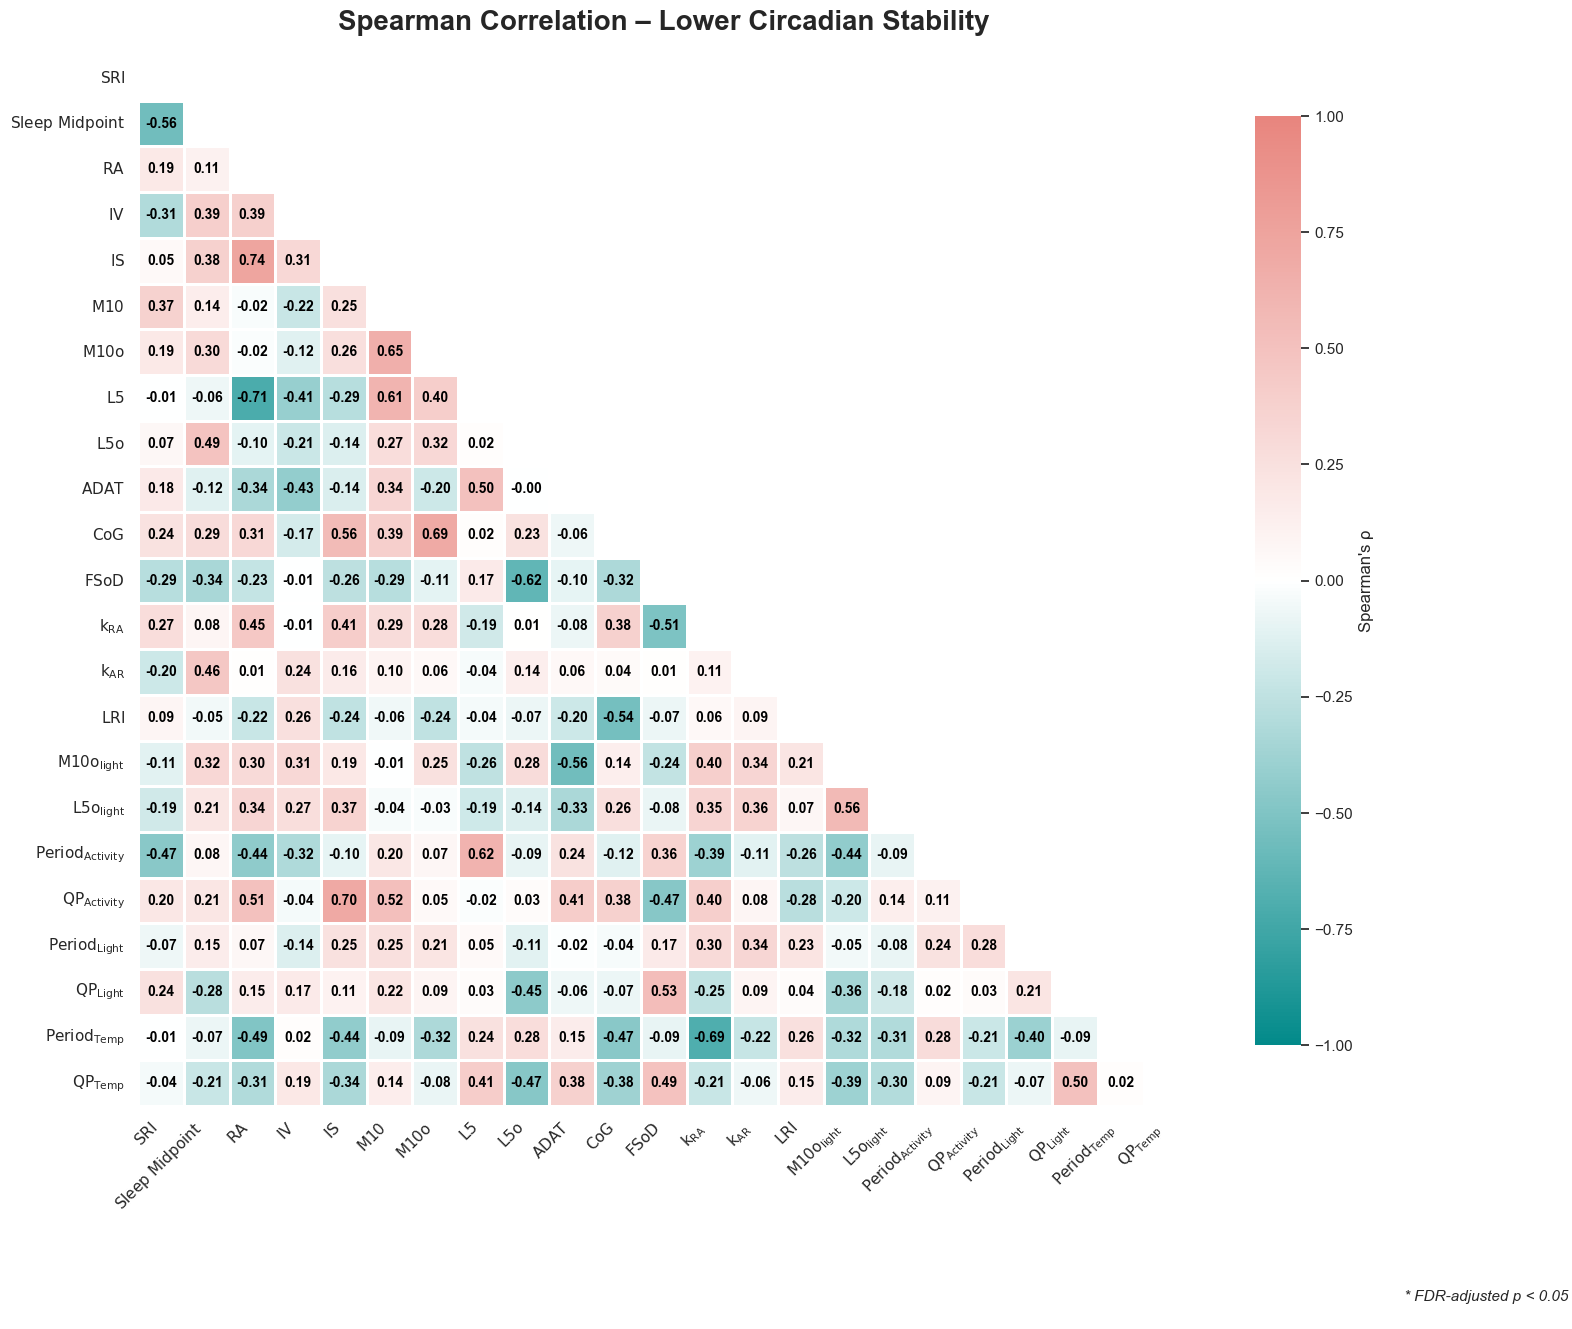

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================
# LOAD DATA
# =============================================================================
file_path = TABLE_CLUSTER_PATH
df = pd.read_csv(file_path)

# =============================================================================
# VARIABLES OF INTEREST
# =============================================================================
selected_vars = CLUSTERING_COLUMN_HEADER_LIST

# =============================================================================
# LABELS
# =============================================================================
latex_labels = COLUMN_HEADER_STYLIZED
# =============================================================================
# COLORMAP
# =============================================================================
turquoise_salmon = LinearSegmentedColormap.from_list(
    "TurquoiseSalmon",
    ["#028a8a", "#ffffff", "#e8857e"],
    N=256
)

# =============================================================================
# HELPER
# =============================================================================
def bold_math_label(label):
    if isinstance(label, str) and label.startswith(r"$\mathrm{") and label.endswith("}$"):
        inner = label[len(r"$\mathrm{"):-2]
        return rf"$\mathbf{{{inner}}}$"
    return label


# =============================================================================
# MAIN FUNCTION
# =============================================================================
def plot_spearman_corr_by_cluster(
    df,
    cluster_val,
    cluster_name,
    variables,
    latex_labels,
    cmap,
    figsize=(16, 14),
    save=True,
    save_prefix="corr_cluster"
):
    # -------------------------------------------------------------------------
    # 1. Filter data for one cluster
    # -------------------------------------------------------------------------
    df_cluster = df[df["Cluster"] == cluster_val].copy()

    # Keep only requested variables that actually exist
    variables = [v for v in variables if v in df_cluster.columns]

    # Keep only numeric columns with enough valid observations and some variability
    valid_vars = []
    for col in variables:
        x = pd.to_numeric(df_cluster[col], errors="coerce")
        if x.notna().sum() >= 3 and x.nunique(dropna=True) > 1:
            valid_vars.append(col)

    if len(valid_vars) < 2:
        print(f"Not enough valid variables for {cluster_name}.")
        return

    variables = valid_vars
    df_corr = df_cluster[variables].apply(pd.to_numeric, errors="coerce")

    n = len(variables)

    # -------------------------------------------------------------------------
    # 2. Correlation matrix
    # -------------------------------------------------------------------------
    corr_matrix = pd.DataFrame(np.nan, index=variables, columns=variables)
    pval_matrix = pd.DataFrame(np.nan, index=variables, columns=variables)

    tested_pairs = []

    for i in range(n):
        for j in range(i, n):
            v1, v2 = variables[i], variables[j]

            x = df_corr[v1]
            y = df_corr[v2]
            valid = x.notna() & y.notna()

            if valid.sum() >= 3:
                rho, pval = spearmanr(x[valid], y[valid])
            else:
                rho, pval = np.nan, np.nan

            corr_matrix.loc[v1, v2] = rho
            corr_matrix.loc[v2, v1] = rho
            pval_matrix.loc[v1, v2] = pval
            pval_matrix.loc[v2, v1] = pval

            if i < j and pd.notna(pval):
                tested_pairs.append((v1, v2, pval))

    np.fill_diagonal(corr_matrix.values, 1.0)
    np.fill_diagonal(pval_matrix.values, 0.0)

    # -------------------------------------------------------------------------
    # 3. FDR correction only for unique off-diagonal tests
    # -------------------------------------------------------------------------
    pval_fdr_matrix = pd.DataFrame(np.nan, index=variables, columns=variables)
    np.fill_diagonal(pval_fdr_matrix.values, 0.0)

    if tested_pairs:
        raw_pvals = [p for _, _, p in tested_pairs]
        _, pvals_fdr, _, _ = multipletests(raw_pvals, method="fdr_bh")

        for (v1, v2, _), p_fdr in zip(tested_pairs, pvals_fdr):
            pval_fdr_matrix.loc[v1, v2] = p_fdr
            pval_fdr_matrix.loc[v2, v1] = p_fdr

    # -------------------------------------------------------------------------
    # 4. Preserve the original order given by selected_vars
    # -------------------------------------------------------------------------
    corr_matrix = corr_matrix.loc[variables, variables]
    pval_fdr_matrix = pval_fdr_matrix.loc[variables, variables]

    # -------------------------------------------------------------------------
    # 5. Identify variables participating in at least one significant correlation
    # -------------------------------------------------------------------------
    significant_vars = set()

    for i in range(n):
        for j in range(n):
            if i != j:
                p = pval_fdr_matrix.iloc[i, j]
                if pd.notna(p) and p <= 0.05:
                    significant_vars.add(variables[i])
                    significant_vars.add(variables[j])

    # -------------------------------------------------------------------------
    # 6. Build axis labels
    # -------------------------------------------------------------------------
    display_labels = []
    for var in variables:
        label = latex_labels.get(var, var)
        if var in significant_vars:
            label = bold_math_label(label)
        display_labels.append(label)

    # -------------------------------------------------------------------------
    # 7. Mask upper triangle
    # -------------------------------------------------------------------------
    mask = np.triu(np.ones((n, n), dtype=bool))

    # -------------------------------------------------------------------------
    # 8. Build annotation matrix
    # Always show rho; add * when FDR-adjusted p < 0.05
    # -------------------------------------------------------------------------
    annot_matrix = np.empty((n, n), dtype=object)

    for i in range(n):
        for j in range(n):
            if mask[i, j]:
                annot_matrix[i, j] = ""
            else:
                rho = corr_matrix.iloc[i, j]
                p_fdr = pval_fdr_matrix.iloc[i, j]

                if pd.isna(rho):
                    annot_matrix[i, j] = ""
                elif pd.notna(p_fdr) and p_fdr <= 0.05:
                    annot_matrix[i, j] = f"{rho:.2f}*"
                else:
                    annot_matrix[i, j] = f"{rho:.2f}"

    # -------------------------------------------------------------------------
    # 9. Plot
    # -------------------------------------------------------------------------
    plt.figure(figsize=figsize)
    sns.set_style("white")

    ax = sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap=cmap,
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.8,
        annot=annot_matrix,
        fmt="",
        xticklabels=display_labels,
        yticklabels=display_labels,
        cbar_kws={"label": "Spearman's ρ", "shrink": 0.75},
        annot_kws={"size": 10, "color": "black", "weight": "bold"}
    )

    ax.set_xlim(0, n)
    ax.set_ylim(n, 0)

    plt.title(
        f"Spearman Correlation – {cluster_name}",
        fontsize=20,
        fontweight="bold",
        pad=18
    )
    plt.xticks(rotation=45, ha="right", fontsize=11)
    plt.yticks(rotation=0, fontsize=11)

    plt.annotate(
        "* FDR-adjusted p < 0.05",
        xy=(0.98, 0.02),
        xycoords="figure fraction",
        ha="right",
        fontsize=11,
        fontstyle="italic"
    )

    plt.tight_layout()

    if save:
        plt.savefig(
            f"{save_prefix}_{cluster_val}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # Optional audit output
    return corr_matrix, pval_matrix, pval_fdr_matrix


# =============================================================================
# RUN
# =============================================================================
cluster_map = {
    1: "Higher Circadian Stability",
    0: "Lower Circadian Stability"
}

results = {}

for cluster_val, cluster_name in cluster_map.items():
    corr_matrix, pval_matrix, pval_fdr_matrix = plot_spearman_corr_by_cluster(
        df=df,
        cluster_val=cluster_val,
        cluster_name=cluster_name,
        variables=selected_vars,
        latex_labels=latex_labels,
        cmap=turquoise_salmon,
        figsize=(16, 14),
        save=True,
        save_prefix="corr_cluster"
    )
    results[cluster_name] = {
        "corr": corr_matrix,
        "p_raw": pval_matrix,
        "p_fdr": pval_fdr_matrix
    }

# Logistic Regression with Covariates – Summary

This pipeline evaluates the relationship between multiple circadian variables and binary outcomes,
adjusting for covariates (Age, Sex, and Diabetes status). It applies logistic regression
with robust standard errors (HC3) and corrects for multiple comparisons using FDR.

Steps
-----

1. Define Targets and Predictors
    - Targets: Binary outcomes of interest (e.g., PLR, Cluster, Light Perception).
    - Predictors of interest:
        • If the target is "Cluster", predictor is "PLR".
        • For other targets, predictor is "Cluster".
    - Covariates always included: Age, Sex, Diabetes status.

2. Variable Selection
    - Selects numeric variables not part of the target or predictors.
    - Iterates over each to evaluate its independent association with the outcome.

3. Logistic Regression
    - For each numeric predictor:
        • Builds a logistic regression model: target ~ Age + Sex + Diabetes + predictor_of_interest + variable.
        • Uses HC3 robust standard errors.
        • Extracts coefficient, z-value, p-value, and pseudo R².
        • Skips models with insufficient data (<10 complete cases).

4. Multiple Testing Correction
    - Applies False Discovery Rate (Benjamini–Hochberg) correction to all p-values per target.
    - Flags statistically significant results (FDR < 0.05).

5. Output
    - Generates a results table for each target, including:
        • Coefficient, z-value, p-value, pseudo R², FDR-corrected p-value, significance flag.
    - Saves one CSV file per target (e.g., `logistic_results_target_PLR.csv`).
    - Displays the sorted results (by FDR) in the notebook or console.
"""



In [ ]:
# Lista de desfechos binários
targets = ['PLR', 'Cluster', 'Light Perception']

for target in targets:
    results = []
    # Define preditores de ajuste
    adjusters = ['Age', 'Sex', 'Diabetes status']
    predictors = adjusters.copy()
    predictor_of_interest = 'PLR' if target == 'Cluster' else 'Cluster'
    predictors.append(predictor_of_interest)

    # Seleciona as variáveis numéricas (exclui target e preditores)
    variables = df.select_dtypes(include=[np.number]).columns.difference(predictors + [target])
    p_values = []

    for var in variables:
        cols = [target] + predictors + [var]
        data = df[cols].dropna()

        if len(data) >= 10:  # mínimo razoável para regressão
            y = data[target]
            X = sm.add_constant(data[predictors + [var]])

            try:
                logit_model = sm.Logit(y, X)
                fitted = logit_model.fit(disp=0, cov_type='HC3')

                coef = fitted.params[var]
                z_val = fitted.tvalues[var]
                p_val = fitted.pvalues[var]
                pseudo_r2 = fitted.prsquared
                method = "Logistic (HC3)"

            except Exception as e:
                coef = z_val = p_val = pseudo_r2 = np.nan
                method = f"Error: {str(e)}"
        else:
            coef = z_val = p_val = pseudo_r2 = np.nan
            method = "Insufficient data"

        p_values.append(p_val)

        results.append({
            'Target': target,
            'Predictor': var,
            'Coef.': round(coef, 4),
            'z': round(z_val, 4),
            'p': round(p_val, 4),
            'Pseudo R²': round(pseudo_r2, 4),
            'Regression Method': method
        })

    df_results = pd.DataFrame(results)
    _, fdr_corrected, _, _ = multipletests(p_values, method='fdr_bh')
    df_results['FDR'] = np.round(fdr_corrected, 4)
    df_results['Significant (FDR)'] = df_results['FDR'] < 0.05

    df_results.sort_values('FDR', inplace=True)

    # Salvar e exibir
    output_path = os.path.join(output_dir, f"logistic_results_target_{target}.csv")
    df_results.to_csv(output_path, index=False)
    print(f"✅ Logistic regression results saved for target: {target}")
    display(df_results.round(2))
    


✅ Logistic regression results saved for target: PLR


,Target,Predictor,Coef.,z,p,Pseudo R²,Regression Method,FDR,Significant (FDR)
13,PLR,Light Perception,3.34,3.81,0.00,0.38,Logistic (HC3),0.01,True
6,PLR,ISm,9.44,2.76,0.01,0.22,Logistic (HC3),0.11,False
11,PLR,L5olight,0.02,2.51,0.01,0.16,Logistic (HC3),0.15,False
23,PLR,RA,10.37,2.29,0.02,0.15,Logistic (HC3),0.21,False
9,PLR,L5,-0.00,-1.94,0.05,0.13,Logistic (HC3),0.40,False
34,PLR,SRI,0.03,1.73,0.08,0.12,Logistic (HC3),0.45,False
17,PLR,PeriodActivity,-0.13,-1.76,0.08,0.11,Logistic (HC3),0.45,False
5,PLR,IS,4.55,1.50,0.13,0.10,Logistic (HC3),0.52,False
19,PLR,PeriodTemperature,-0.09,-1.58,0.11,0.09,Logistic (HC3),0.52,False
12,PLR,LRI,0.04,1.49,0.14,0.10,Logistic (HC3),0.52,False


✅ Logistic regression results saved for target: Cluster


overflow encountered in exp
Maximum Likelihood optimization failed to converge. Check mle_retvals


,Target,Predictor,Coef.,z,p,Pseudo R²,Regression Method,FDR,Significant (FDR)
23,Cluster,RA,2362.99,38.02,0.00,1.00,Logistic (HC3),0.00,True
20,Cluster,QPActivity,1.10,4.01,0.00,0.68,Logistic (HC3),0.00,True
5,Cluster,IS,53.17,3.97,0.00,0.77,Logistic (HC3),0.00,True
6,Cluster,ISm,19.20,3.88,0.00,0.48,Logistic (HC3),0.00,True
12,Cluster,LRI,0.14,3.80,0.00,0.39,Logistic (HC3),0.00,True
9,Cluster,L5,-0.01,-3.66,0.00,0.44,Logistic (HC3),0.00,True
16,Cluster,M10olight,-0.04,-3.49,0.00,0.43,Logistic (HC3),0.00,True
22,Cluster,QPTemperature,0.20,3.18,0.00,0.31,Logistic (HC3),0.01,True
31,Cluster,SB_var_EXT TEMPERATURE (%),0.14,2.93,0.00,0.24,Logistic (HC3),0.01,True
11,Cluster,L5olight,-0.02,-2.48,0.01,0.24,Logistic (HC3),0.05,False


✅ Logistic regression results saved for target: Light Perception


,Target,Predictor,Coef.,z,p,Pseudo R²,Regression Method,FDR,Significant (FDR)
16,Light Perception,PLR,3.36,3.81,0.00,0.33,Logistic (HC3),0.01,True
21,Light Perception,QPLight,-0.15,-2.29,0.02,0.10,Logistic (HC3),0.14,False
33,Light Perception,SB_var_RED LIGHT (%),-0.25,-2.47,0.01,0.13,Logistic (HC3),0.14,False
32,Light Perception,SB_var_IR LIGHT (%),-0.14,-2.22,0.03,0.10,Logistic (HC3),0.14,False
4,Light Perception,FSoD,-7.33,-2.19,0.03,0.10,Logistic (HC3),0.14,False
30,Light Perception,SB_var_BLUE LIGHT (%),-0.26,-2.54,0.01,0.13,Logistic (HC3),0.14,False
29,Light Perception,SB_var_AMB LIGHT (%),-0.15,-2.29,0.02,0.10,Logistic (HC3),0.14,False
19,Light Perception,PeriodTemperature,-0.24,-2.26,0.02,0.12,Logistic (HC3),0.14,False
34,Light Perception,SRI,0.04,2.10,0.04,0.12,Logistic (HC3),0.14,False
23,Light Perception,RA,9.04,2.09,0.04,0.11,Logistic (HC3),0.14,False


# Pipeline: Association Between PLR, Light Perception, and Cluster

🔍 Chi-squared test for PLR × Light Perception vs. Cluster
Cluster                               0   1
PLR_Light_Label                            
Non reactive /\n Light perception     4   5
Non reactive /\n No light perception  9  18
Reactive /\n Light perception         2  18
Reactive /\n No light perception      1   1
χ² = 5.33, p = 0.1494



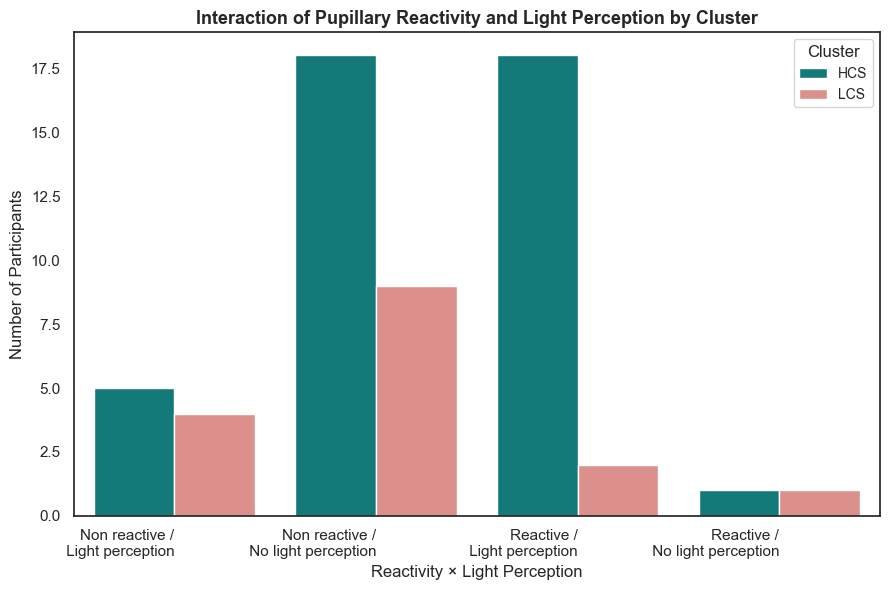

Logistic Regression Results (Cluster ~ PLR × Light Perception)
                           Logit Regression Results                           
Dep. Variable:                Cluster   No. Observations:                   58
Model:                          Logit   Df Residuals:                       54
Method:                           MLE   Df Model:                            3
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                 0.08505
Time:                        21:47:02   Log-Likelihood:                -31.256
converged:                       True   LL-Null:                       -34.162
Covariance Type:                  HC3   LLR p-value:                    0.1212
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.6931      0.408      1.698      0.090      -0.107       1.493
PLR                    



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



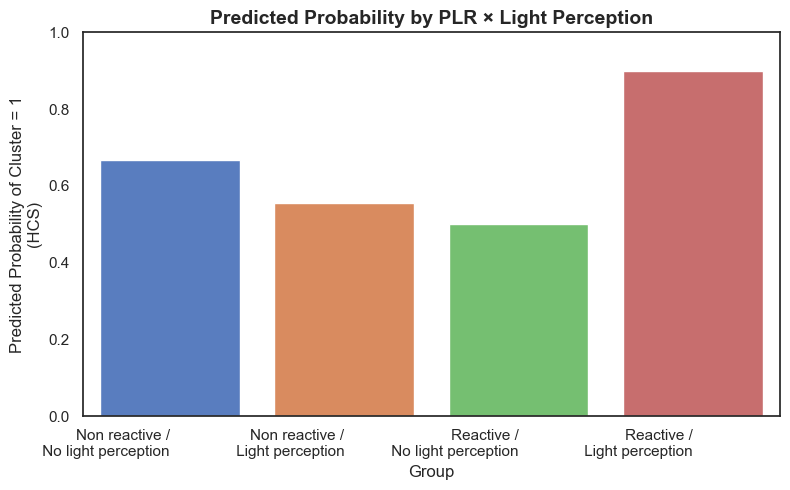

In [20]:
# ========== 1. Preprocessing ==========
dataframe_source = pd.read_csv(TABLE_CLUSTER_PATH)
dataframe_source['PLR'] = dataframe_source['PLR'].astype(int)
dataframe_source['Light Perception'] = dataframe_source['Light Perception'].astype(int)
dataframe_source['Cluster'] = dataframe_source['Cluster'].astype(int)

dataframe_source['PLR_Light'] = dataframe_source['PLR'].astype(str) + "_" + dataframe_source['Light Perception'].astype(str)
group_labels = {
    '0_0': 'Non reactive /\n No light perception',
    '0_1': 'Non reactive /\n Light perception',
    '1_0': 'Reactive /\n No light perception',
    '1_1': 'Reactive /\n Light perception'
}
dataframe_source['PLR_Light_Label'] = dataframe_source['PLR_Light'].map(group_labels)

# Create Cluster_Label for plotting
CLUSTER_LABELS_TO_ABBR = CLUSTER_LABELS_TO_ABBR
dataframe_source['Cluster_Label'] = dataframe_source['Cluster_name'].map(CLUSTER_LABELS_TO_ABBR)

# ========== 2. Chi-squared Test ==========
contingency_table = pd.crosstab(dataframe_source['PLR_Light_Label'], dataframe_source['Cluster'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("🔍 Chi-squared test for PLR × Light Perception vs. Cluster")
print(contingency_table)
print(f"χ² = {chi2:.2f}, p = {p:.4f}\n")

# ========== 3. Cluster Distribution Barplot ==========
plt.figure(figsize=(9, 6))
counts = dataframe_source.groupby(['PLR_Light_Label', 'Cluster_Label']).size().reset_index(name='Count')

sns.barplot(
    data=counts, x='PLR_Light_Label', y='Count', hue='Cluster_Label',
    palette = CLUSTER_COLORS_ABBR
)
plt.title('Interaction of Pupillary Reactivity and Light Perception by Cluster', fontsize=13)
plt.xlabel('Reactivity × Light Perception')
plt.ylabel('Number of Participants')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.show()

# ========== 4. Logistic Regression with Interaction ==========
formula = 'Cluster ~ PLR * Q("Light Perception")'
logit_model = smf.logit(formula, data=dataframe_source).fit(cov_type='HC3', disp=0)

print("Logistic Regression Results (Cluster ~ PLR × Light Perception)")
print(logit_model.summary())

llr_p = logit_model.llr_pvalue
pseudo_r2 = logit_model.prsquared
print(f"\nModel Fit: LLR p = {llr_p:.4f}, Pseudo R² = {pseudo_r2:.3f}\n")

# ========== 5. Plot Predicted Probabilities ==========
plot_df = pd.DataFrame({
    'PLR': [0, 0, 1, 1],
    'Light Perception': [0, 1, 0, 1]
})
plot_df['Predicted Prob'] = logit_model.predict(plot_df)
plot_df['Group'] = plot_df['PLR'].astype(str) + "_" + plot_df['Light Perception'].astype(str)
plot_df['Group'] = plot_df['Group'].map(group_labels)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x='Group', y='Predicted Prob', palette='muted')
plt.ylim(0, 1)
plt.ylabel('Predicted Probability of Cluster = 1\n(HCS)')
plt.title('Predicted Probability by PLR × Light Perception')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()
